# 횡단면 무기한선물 롱숏 **XS-5** — Binance USD-M perpetuals

> 본 글은 공개 데이터와 개인 연구용 모델 실험을 바탕으로 한 분석이며, 특정 자산의 매수·매도 추천이나 투자 자문을 목적으로 하지 않습니다.
> **XS-4의 결과 (이 버전이 존재하는 이유).** 판정 2/6. OOS 700일에서 주 전략은
> 연 +17.6%, Sharpe 1.06, t 1.47 — XS-3에서 보고한 "연 31.4%, Sharpe 1.51"이
> **재현되지 않았다.** 같은 490일 구간에서 비용 모델만 현실화하니 +42.1% → +27.5%였다.
> 즉 **보고 수익의 35%가 "왕복 8bp" 가정 하나에서 나온 것**이었다.
>
> 그리고 두 가지가 더 드러났다.
>
> 1. **혼합 가설은 죽었다.** XS-3에서 사후로 찾은 "모델+LowVol 50/50"을 validation이
>    고르게 했더니, 혼합을 고른 14 fold에서 **−1,791 bp** 손해였다. XS-LowVol이 긴
>    표본에서는 Sharpe 0.04로 죽어 있었다. 그 가설을 잡으려고 만든 J-5가 잡았다.
> 2. **예측과 손익의 괴리는 그대로다.** 증분 IC는 **20/20 fold 양수, t = +8.53**인데
>    순손익은 t = +1.47이다. 이론상 기대치의 15%만 건지고 있다.
>
> XS-5는 그 괴리를 정면으로 친다: **① 평균-분산 비중**(순위 top-k는 순위 중간을 버리고
> 수익과 위험을 같이 보지 않는다), **② 소프트 중립화**(노출을 정확히 0으로 사영하는
> 대신 강도 φ를 validation이 고른다 — "노출 0을 만드느라 신호를 얼마나 버렸나"가
> 처음으로 숫자가 된다), **③ 혼합 원복**(실패한 가설을 후보에 남기면 또 뽑힌다),
> **④ 대조군을 4 fold로**, **⑤ 비용을 시나리오 3종으로 명시**.
>
> ---
>
> **XS-3의 결과 (그 전 단계).** 판정 3/5. OOS 490일에서 총노출 1배 기준
> **+42.1% (연 31.4%), Sharpe 1.51, MDD −22.8%**, 실현 베타·변동성 노출은 **정확히 0**.
> 베이스라인 회귀 R²가 XS-1의 0.82에서 **0.14**로 떨어져 더 이상 복제품이 아니게 됐고,
> 국면 프로파일도 뒤집혔다 (상승일 +17.6bp / 하락일 +0.0bp — XS-1·XS-2는 그 반대였다).
>
> **남은 문제는 표본이다.** 전체 t = 1.75, 잔차 알파 t = 1.78 — 둘 다 문턱 2.0 직전이다.
> 그리고 결정적인 힌트가 하나 나왔다:
>
> ```
> corr(XS-Model, XS-LowVol) = +0.166        <- 거의 독립
> 50/50 혼합 -> Sharpe 1.51 → 1.84,  t 1.75 → 2.13
> ```
>
> **답은 베이스라인을 '이기는' 것이 아니라 '합치는' 것이었다.** XS-4는 그걸 정식화한다:
> **① 혼합 북**(비중은 validation이 고른다), **② 이력 42→60개월**(OOS 490→900일,
> t는 sqrt(표본)로 커진다), **③ 종목별 비용 모델**(유동성 순위 연동 6~20bp),
> **④ 상승장 편중 진단**(롱/숏 다리 분해), **⑤ 선택 격자 재구조화**(목표 비중을
> 재사용해 조합이 5배 늘었는데도 더 빠르다).
>
> ---
>
> **XS-2가 찾아낸 것 (그 전 단계).** XS-2는 판정 1/5로 끝났지만,
> 그 실행이 이 프로젝트에서 가장 중요한 것을 분리해냈다. 변동성과 베타를 라벨에서
> 제거한 **잔차**를 예측하게 했더니 **rank IC +0.052, t = +7.90, 14/14 fold 전부 양수**가
> 나왔다. OOS 490일, 상승 239일 + 하락 251일, 요인을 다 뺀 뒤의 값이다. **알파는 있다.**
>
> **그런데 그 예측이 돈으로 안 바뀌었다.** `corr(fold IC, fold 순손익) = +0.04`.
> 가장 잘 맞힌 fold(IC +0.163)가 가장 크게 잃었다(−747 bp). 원인은 특정됐다 —
> `rank_topk`가 **동일 금액**을 넣기 때문이다. 손익은 `w × 수익률`이고 수익률 크기는
> 종목마다 몇 배씩 차이 나므로, **rank IC가 모든 종목을 1표씩 세는 동안 손익은
> 고변동성 몇 종목이 지배한다.**
>
> 그리고 내 구현 버그가 하나 더 있었다: **베타중립이 목표 비중에만 걸리고 실제 거래되는
> 북에는 안 걸렸다** (실현 노출 −0.066, 최악 −0.308). 계약 테스트가 잘못된 대상을
> 검사하고 있었던 것이다.
>
> XS-3은 포트폴리오 구성층을 다시 쓴다: **① 변동성 스케일 비중** (`w ∝ 신호/σ`),
> **② 리밸런스 후 재사영**으로 실현 북에 제약 강제, **③ 변동성 중립 제약** 추가,
> **④ 잔차 모델을 주 모델로 승격**, **⑤ IC→손익 전환 효율을 상시 지표로**.
>
> ---
>
> **XS-1이 가르쳐준 것 (그 전 단계).** XS-1은 사전 선언 기준을 통과했다 —
> break-even 213bp 대 비용 8bp, rank IC +0.108, OOS 210일 +101%. 그런데 실행 후 손익을
> 분해해 보니 **모델 손익의 82%가 `XS-LowVol`이라는 공짜 한 줄 규칙으로 설명**됐고
> (corr +0.90, 계수 1.21), 그 규칙을 통제하면 모델의 알파는 **−4.8 bp/일 (t = −0.47)** 로
> 사라졌다. 게다가 달러중립 북이 **시장 베타 −0.41 (t = −5.9)** 을 그대로 안고 있었고,
> OOS 210일이 전부 **−75% 폭락장 한 국면**이었다. 손익의 94%가 210일 중 10일에서 나왔다.
>
> **즉 판정 기준이 잘못 설계돼 있었다.** "최고 break-even"만 봤기 때문에 모델이
> 베이스라인의 1.21배 복제품인데도 통과했다. XS-2는 세 가지를 구조적으로 바꾼다:
> **① 베타중립 제약**으로 시장 노출 통로를 막고, **② 요인 잔차 라벨**로 모델이
> 이미 알려진 요인을 넘어선 것을 찾도록 강제하고, **③ 판정 기준**을
> "베이스라인 대비 우월 / 잔차 알파 / 상승장 / 집중도"로 교체한다. 그리고
> **④ OOS를 210일 → 630일**로 늘려 두 국면을 모두 넣는다.

V1~V3에서 확인된 것: **ETHUSDT 5초 방향 예측은 신호가 실재하지만(direction AUC 0.55)
그 edge가 0.21bp이고 편도 비용이 4bp다.** 세 개의 서로 다른 모델 계열(3-class GBDT,
2-head GBDT, causal TCN)이 독립적으로 같은 천장에 수렴했고, 미래를 전부 아는 DP oracle조차
결정당 0.15bp였다. 즉 한계는 모델도 state도 아니고 **문제 설정**이었다.

이 노트북은 **문제 설정을 바꾼다.**

| | V1~V3 | 여기 |
|---|---|---|
| 예측 대상 | 단일 종목 5초 방향 | **횡단면 초과수익** (동료 대비 24시간) |
| 보유 | 5초 | 24시간 |
| 평균 움직임 | 0.94 bp | 수백 bp 규모 |
| 비용 비중 | edge의 **19배** | 라벨 셀에서 실측해 출력한다 |
| 북 | 단일 종목 방향 베팅 | **달러중립 롱숏** |
| 데이터 | aggTrades 1초 | 1시간봉 + 펀딩률 |
| 북 제약 (XS-2) | — | 달러중립 **+ 베타중립** |
| 라벨 (XS-2) | — | 초과수익에서 **변동성·베타 요인 제거** |

**왜 이쪽이 산술적으로 가능성이 있는가.** 비용은 그대로인데 움직임은 √t로 커진다.
5초에서 0.94bp였던 평균 |움직임|이 24시간에서는 100배 이상이 된다. 비용/신호 비율이
두 자릿수 바뀐다. 그리고 횡단면 순위는 시장 전체 방향을 자동으로 제거하므로,
"비트코인이 오를까"가 아니라 "A가 B보다 나을까"만 맞히면 된다 — 후자가 훨씬 쉬운 질문이다.

**그대로 가져온 것**: purged expanding walk-forward, 인과성 계약 테스트,
사전 선언 판정 기준, break-even 왕복비용을 주 지표로 쓰기, 미래를 아는 상한(oracle) 대비 비교,
비용 민감도 sweep, seed 앙상블.

> 여전히 research P&L이다. 선형 비용 모델과 펀딩까지는 넣었지만 호가창·부분체결·
> 숏 차입 제약은 없다. 실거래 손익을 주장하지 않는다.

## 연구 계약

- **예측 대상**: `t` 시점 유니버스 안에서 **횡단면 중앙화된** 24시간 선도 로그수익(bps).
  시장 전체 움직임(베타)은 라벨에서 완전히 제거된다 — 셀 안에서 assert로 검증한다.
- **유니버스**: 매 시점 **직전 30일 거래대금 중앙값** 상위 N개. 순위는 `t` 이전 데이터만 본다.
  (내려받는 후보 집합 자체는 사후적이다. 이 한계는 데이터 셀에서 명시적으로 보고한다.)
- **생존편향**: Binance 아카이브는 **상장폐지된 종목의 파일도 보관**한다. prefix listing으로
  유니버스를 만들기 때문에 "오늘 살아남은 종목"으로 필터되지 않는다.
- **분할**: train → purge → validation → purge → calibration → purge → untouched outer test.
  purge 폭은 `max(피처 창 168h, 라벨 창 72h)`이고 경계마다 assert한다.
- **선택**: 포트폴리오 상수(비중 방식, top-k, 부분 리밸런스 비율, no-trade 밴드)는
  **validation + calibration 에서만** 고른다. 선택 기준은 총합이 아니라 **t값**이다.
- **비용**: 왕복 8bp 가정(taker 근처) + 종목별 펀딩 실비. 0~30bp sweep을 항상 함께 본다.
- **북 제약**: `sum(w) = 0`, `sum(w·β) = 0`, `sum(w·σrank) = 0`.
  **목표 비중이 아니라 실제 거래되는 북에** 건다 — XS-2는 목표에만 걸어서 실현 노출이
  −0.066(최악 −0.308)인 것을 놓쳤고, 계약 테스트도 그걸 못 잡았다.
- **비중 변환**: 평균-분산 / 순위 top-k / 변동성스케일 top-k / 비례 중 validation이 고른다.
- **중립화 강도 φ**: 0이면 노출을 그대로 안고, 1이면 XS-4와 같은 하드 중립화다.
  중간값이 **"노출 0을 위해 신호를 얼마나 버리는가"**에 답한다. validation이 고른다.
- **거래비용**: 시간봉 OHLC로는 스프레드를 못 잰다는 것을 노트북 안에서 확인한다
  (Corwin-Schultz 추정치가 거의 0 — 시간당 변동성이 스프레드를 덮는다). 그래서
  **순위만 데이터(Amihud 비유동성)에서 가져오고 수준은 시나리오 3종으로 명시**하고,
  낙관·기본·비관 셋 다 보고한다. 하나의 숫자로 답하지 않는다.
- **판정** (실행 전에 고정, 마지막 셀이 자동 채점):
  - **J-0** break-even 왕복비용 > 8bp — 필요조건
  - **J-1** 최종 북(혼합)이 최고 베이스라인 대비 t > 2 — *이 전략이 필요한가*
  - **J-2** 시장·베이스라인 통제 후 잔차 알파의 t > 2 — *알려진 위험요인 이상인가*
  - **J-3** 상승장 하위표본 순손익 > 0 — *국면 하나에 기댄 것이 아닌가*
  - **J-4** 상위 10일 제외 후 순손익 > 0 — *며칠에 몰린 것이 아닌가*
  - **J-5** 새 구성층(평균-분산+소프트중립)이 XS-4 방식보다 나은가 — *이번 가설이 맞았는가*
  - **무결성** 라벨을 섞은 대조군 IC ≈ 0

## 실행 방법과 자원

1. Colab에서 GPU는 **필요 없다** (XGBoost만 쓴다). CPU 런타임으로 충분하다.
2. 위에서 아래로 전부 실행한다. Binance public archive를 API key 없이 쓴다.
3. 기본 설정: 후보 60종목 → 상위 40종목, 60개월 1시간봉, 24시간 리밸런스, 20 fold
   (OOS 약 700일). 다운로드 약 130MB(디스크 캐시), 예상 실행 40~70분.
4. 빠른 검사는 `use_synthetic=True`. 합성 패널에는 **24시간 횡단면 반전 효과**가
   의도적으로 심어져 있어서 배관이 제대로 도는지 확인할 수 있다.
   합성 결과의 숫자는 연구 성능으로 해석하지 않는다.

**이 노트북은 전 셀이 실행 검증됐다.** V2/V3는 PyTorch를 설치할 수 없어 일부 구간을
코드 리뷰로만 확인했지만, 여기는 XGBoost뿐이라 합성 패널로 처음부터 끝까지 돌려봤다.
그 실행에서 (a) 심어 놓은 신호를 rank IC +0.18로 회수했고, (b) 라벨을 섞은 대조군에서는
IC가 −0.03(t=−0.43)으로 내려갔으며, (c) 베타중립 제약이 베타 노출을 0.099 → 3e−17로
지웠다. **찾아내는 힘과 없을 때 없다고 말하는 정직함을 둘 다 확인한 배관**이라는 뜻이다.

그리고 새 판정 기준이 실제로 까다롭다는 것도 그 실행이 보여준다: 합성 패널의 심어 놓은
효과가 **바로 24시간 반전**이라서, 모델은 J-0·J-4는 통과하지만 **J-1(베이스라인 대비
우월)에서 t = −0.06으로 떨어진다.** 옳은 동작이다 — 베이스라인이 곧 정답인 데이터에서
모델이 베이스라인을 이겼다고 나오면 그게 오히려 버그다.

In [ ]:
# Colab runtime preparation.
import importlib.util, subprocess, sys
from importlib.metadata import PackageNotFoundError, version

required = []
try:
    if int(version("xgboost").split(".")[0]) < 2:
        required.append("xgboost>=2.0")
except (PackageNotFoundError, ValueError):
    required.append("xgboost>=2.0")
for module, spec in [("pyarrow", "pyarrow>=14"), ("psutil", "psutil")]:
    if importlib.util.find_spec(module) is None:
        required.append(spec)
if required:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required])

# 한글 폰트.  없으면 그래프의 한글 라벨이 전부 네모로 나온다.
try:
    from matplotlib import font_manager
    if not any(("Nanum" in f.name) or ("CJK" in f.name) for f in font_manager.fontManager.ttflist):
        subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
except Exception:
    pass
print("Dependency check complete", required or "(already installed)")

Dependency check complete (already installed)


In [ ]:
import gc, hashlib, io, json, os, platform, re, shutil, time, warnings, zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn
import xgboost as xgb
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", context="notebook")

# 한글 폰트 등록 (seaborn 테마가 rcParams를 덮으므로 반드시 그 뒤에 온다).
from matplotlib import font_manager
for _path in font_manager.findSystemFonts(fontext="ttf"):
    if "Nanum" in _path or "NotoSansCJK" in _path or "NotoSansKR" in _path:
        try:
            font_manager.fontManager.addfont(_path)
        except Exception:
            pass
_installed = {f.name for f in font_manager.fontManager.ttflist}
_korean = next((name for name in ("NanumGothic", "NanumBarunGothic", "Noto Sans KR",
                                  "Noto Sans CJK KR", "Noto Sans CJK JP", "Noto Sans CJK SC")
                if name in _installed), None)
if _korean is None:      # pan-CJK 폰트는 어느 지역판이든 한글 글리프를 포함한다
    _korean = next((f.name for f in font_manager.fontManager.ttflist
                    if "Nanum" in f.name or "CJK" in f.name), None)
if _korean:
    plt.rcParams["font.family"] = _korean
else:
    print("경고: 한글 폰트를 못 찾았다 -- 그래프의 한글이 네모로 보일 수 있다 (숫자는 정상).")
plt.rcParams["axes.unicode_minus"] = False

SEED = 20260814
np.random.seed(SEED)

print("Python", platform.python_version())
print("numpy", np.__version__, "pandas", pd.__version__, "sklearn", sklearn.__version__,
      "xgboost", xgb.__version__)
print("UTC", pd.Timestamp.now(tz="UTC"))

Python 3.12.13
numpy 2.0.2 pandas 2.2.2 sklearn 1.6.1 xgboost 3.3.0
UTC 2026-08-15 06:37:25.981967+00:00


In [ ]:
@dataclass
class XSConfig:
    # ------------------------------------------------------------------ universe
    # Binance USD-M perpetuals, hourly klines + funding.  The archive keeps files for
    # delisted symbols too, so listing the S3 prefix gives a low-survivorship universe.
    # The *download* set is still chosen with hindsight (we cannot download what we
    # have not listed), so the tradable universe is re-selected causally at every
    # timestamp from trailing volume only -- see `causal_universe_mask`.
    quote_asset: str = "USDT"
    download_candidates: int = 60          # 아카이브에서 내려받을 후보 수
    tradable_universe: int = 40            # 매 시점 거래 가능하다고 볼 상위 N (인과적)
    universe_volume_lookback_hours: int = 720   # 30일 거래대금 중앙값으로 순위
    # XS-1의 OOS 210일이 **전부 하락장 한 국면**이었다.  상승장에서도 같은 신호가
    # 도는지 모르면 아무것도 확정할 수 없으므로 이력을 늘려 OOS에 두 국면을 넣는다.
    history_months: int = 60
    archive_lag_days: int = 2
    min_symbol_history_hours: int = 4_320  # 180일 미만 이력은 후보에서 제외
    download_workers: int = 8
    cache_dir: str = "/content/xs_perp_cache"
    output_dir: str = "/content/xs_perp_outputs"
    use_synthetic: bool = False
    synthetic_symbols: int = 24
    synthetic_hours: int = 9_000

    # ------------------------------------------------------------------ clock
    bar_hours: int = 1
    # 가장 긴 인과 창.  purge 폭이 여기서 나온다.
    feature_lookback_hours: int = 168       # 7일
    max_stale_bars: int = 3                 # 3시간 이상 결측이면 그 시점 거래 불가

    # ------------------------------------------------------------------ label
    # 예측 대상은 **횡단면 초과수익**이다.  달러중립 롱숏 북이 실제로 먹는 게 이것이고,
    # 시장 전체 방향(=베타)은 예측 대상에서 빼야 알파와 베타가 섞이지 않는다.
    label_horizon_hours: int = 24
    label_horizon_grid: tuple[int, ...] = (4, 24, 72)
    rebalance_hours: int = 24               # 리밸런스 간격 (= 보유기간)
    # 학습은 겹치는 표본으로, 거래는 겹치지 않게.  일간 리밸런스만 쓰면 fold당
    # 학습 행이 300일 x 40종목 = 12,000개뿐이라 GBDT에는 턱없이 부족하다.
    # 4시간 간격으로 표본을 뽑으면 6배가 되고, 라벨이 겹치는 건 학습에서는 표준
    # 관행이다(경계는 purge가 처리한다).  포트폴리오는 여전히 24시간마다만 움직인다.
    sample_hours: int = 4
    label_clip_quantile: float = 0.995

    # ------------------------------------------------------------------ walk-forward
    # OOS를 210일 -> 630일로 늘린다.  국면이 하나뿐이면 "이 신호가 반복되는가"에
    # 답할 수 없다.
    # XS-3에서 Sharpe 1.51에 t = 1.75가 나왔다.  t는 sqrt(표본)로 커지므로
    # 같은 알파면 OOS 640일에서 t=2를 넘는다.  490 -> 900일로 늘려 정면으로 친다.
    min_train_days: float = 240.0
    validation_days: float = 30.0
    calibration_days: float = 30.0
    test_days: float = 45.0
    max_folds: int = 20

    # ------------------------------------------------------------------ 요인 중립화
    # XS-1의 진짜 결론: 모델 손익의 82%가 XS-LowVol 한 줄로 설명됐고, 달러중립 북이
    # 시장 베타 -0.41을 그대로 안고 있었다.  둘 다 여기서 구조적으로 막는다.
    beta_neutral: bool = True               # sum(w_i * beta_i) = 0 제약을 추가
    beta_lookback_hours: int = 720          # 인과적 베타 추정 창 (30일)
    # XS-2에서 베타를 빼고도 상승장 순손익이 0이었다.  베타는 뺐지만 **변동성 노출**은
    # 그대로였기 때문이다 -- 고변동성 숏은 베타가 0이어도 폭락에서 번다.
    vol_neutral: bool = True                # sum(w_i * sigma_rank_i) = 0 제약을 추가
    sigma_lookback_hours: int = 168         # 비중 스케일링에 쓰는 변동성 창 (7일)
    # 라벨에서 제거할 횡단면 요인.  모델이 이걸 넘어선 것을 찾도록 강제한다.
    label_neutral_factors: tuple[str, ...] = ("xs_vol_24h", "beta")
    rank_ic_early_stopping: bool = True     # RMSE 대신 rank IC로 조기종료

    # ------------------------------------------------------------------ model
    xgb_estimators: int = 800
    xgb_learning_rate: float = 0.03
    xgb_max_depth: int = 5
    xgb_min_child_weight: float = 64.0
    xgb_subsample: float = 0.8
    xgb_colsample: float = 0.7
    xgb_reg_lambda: float = 20.0
    xgb_early_stopping: int = 60
    model_seeds: int = 3                    # seed 앙상블 (V3에서 단일 seed 착시를 봤다)

    # ------------------------------------------------------------------ 비용
    # Binance USD-M VIP0: maker 0.0200% / taker 0.0500% -> 왕복 4bp(maker) / 10bp(taker).
    # 일간 리밸런스는 지정가로 나눠 담을 시간이 충분하므로 maker 쪽이 현실적이지만,
    # 기본값은 보수적으로 taker 근처에 둔다.
    research_round_trip_cost_bps: float = 8.0
    # XS-3까지는 전 종목 8bp 고정이었다.  실제로는 거래대금 하위 종목의 스프레드가
    # 훨씬 넓고, 부트스트랩 하단(break-even 9.9bp)이 그 위험을 정면으로 가리킨다.
    # 직전 거래대금 순위로 종목별 비용을 매긴다 -- 유동성이 낮을수록 비싸게.
    # XS-4의 "유동성 순위 6~20bp 선형"은 내가 지어낸 램프였고, 그 가정 하나가
    # 보고 수익의 35%를 좌우했다.  XS-5는 **고가·저가로 스프레드를 추정**한다
    # (Corwin-Schultz 2012) -- 이미 가진 OHLC만 쓰고 전부 과거 봉이라 인과적이다.
    # **결과부터 적어둔다: 시간봉 OHLC로는 스프레드를 못 잰다.**  Corwin-Schultz를
    # 붙여봤더니 추정치가 거의 전부 0으로 나왔다 -- 시간당 변동성(수십 bp)이 스프레드
    # (수 bp)를 완전히 덮기 때문이고, 이건 추정기 결함이 아니라 주파수의 한계다.
    # 노트북에 그대로 남겨 확인만 하고(정직한 음성 결과다), 비용은 **유동성 순위 램프**를
    # 쓰되 **수준을 시나리오로 명시하고 셋 다 보고**한다.  하나의 숫자로 답하지 않는다.
    per_symbol_cost: bool = True
    spread_lookback_hours: int = 168
    illiquidity_lookback_hours: int = 720   # Amihud 비유동성 추정 창 (30일)
    cost_scenario: str = "base"             # optimistic | base | pessimistic
    cost_scenarios: tuple = (("optimistic", 4.0, 12.0), ("base", 6.0, 20.0),
                             ("pessimistic", 10.0, 35.0))   # (이름, 최유동 bp, 최비유동 bp)
    cost_sensitivity_roundtrip_bps: tuple[float, ...] = (0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0, 30.0)
    # 무기한 선물 펀딩은 8시간마다 실제로 정산된다.  롱숏 중립 북은 펀딩을 서로
    # 상쇄하지만 완전히 상쇄되지는 않으므로 종목별로 정확히 계산한다.
    charge_funding: bool = True

    # ------------------------------------------------------------------ 포트폴리오
    # 예측 edge -> 목표 비중.  두 방식을 모두 만들고 validation에서 고른다.
    # XS-2의 결정적 발견: IC는 t=7.9인데 corr(fold IC, fold 손익) = 0.04였다.
    # `rank_topk`가 **동일 금액**을 넣기 때문이다 -- rank IC는 모든 종목을 1표씩 세지만
    # 손익은 고변동성 몇 종목이 지배한다.  변동성 스케일 비중(w ∝ 신호/σ)을 넣어
    # IC가 재는 것과 손익이 재는 것을 일치시킨다.  어느 쪽이 나은지는 validation이 고른다.
    # XS-4의 진짜 병목: 증분 IC t=8.5인데 손익 t=1.5, 이론 기대치의 15%만 건졌다.
    # 순위 top-k는 (a) 순위 중간을 버리고 (b) 수익과 위험을 같이 보지 않는다.
    # `mean_variance`(w = (D + tau F F')^-1 mu)가 둘 다 고치고, 소프트 중립화까지
    # 같은 식 안에서 처리한다.  기존 휴리스틱도 후보로 남겨 비교한다.
    weight_scheme_grid: tuple[str, ...] = (
        "mean_variance", "rank_topk", "vol_scaled_topk", "edge_proportional")
    # 중립화 강도 phi: 매 반복에서 요인 성분을 phi만큼 제거한다.
    #   phi = 0   -> 제약 없음 (노출을 그대로 안고 간다)
    #   phi = 1   -> XS-4와 동일한 하드 중립화 (노출 정확히 0)
    # **이 손잡이 하나가 "노출 0을 만들려고 신호를 얼마나 버리는가"를 숫자로 만든다.**
    neutral_shrink_grid: tuple[float, ...] = (0.0, 0.25, 0.50, 0.75, 1.0)
    neutral_shrink_hard: float = 1.0
    top_k_fraction_grid: tuple[float, ...] = (0.10, 0.20, 0.30)
    max_weight_per_symbol: float = 0.10     # 종목당 총노출의 10% 상한
    gross_exposure: float = 1.0             # sum|w| = 1
    # 거래비용을 인식한 부분 리밸런스.  1.0이면 매번 목표로 완전히 이동한다.
    rebalance_fraction_grid: tuple[float, ...] = (0.25, 0.50, 0.75, 1.0)
    no_trade_band_grid: tuple[float, ...] = (0.0, 0.25, 0.50)   # |Δw| < band*평균|w| 이면 유지
    # XS-3의 결정적 발견: corr(XS-Model, XS-LowVol) = +0.166으로 **거의 독립**이었고,
    # 50/50으로 섞으면 Sharpe 1.51 -> 1.84, t 1.75 -> 2.13이 됐다.  즉 답은 베이스라인을
    # '이기는' 것이 아니라 '합치는' 것이다.  혼합 비중도 다른 상수처럼 validation이 고른다
    # (0.0이면 모델 단독이므로 XS-3의 동작이 후보 안에 그대로 들어 있다).
    # XS-4에서 J-5가 실패했다 (혼합을 고른 14 fold에서 -1,791 bp).  XS-3의 50/50은
    # 사후 최적화였고 XS-LowVol이 긴 표본에서는 죽어 있었다(Sharpe 0.04).
    # **실패한 가설을 후보에 남겨두면 다음 표본에서 또 우연히 뽑힌다** -- 0으로 고정한다.
    blend_weight_grid: tuple[float, ...] = (0.0,)
    blend_baselines: tuple[str, ...] = ()

    # ------------------------------------------------------------------ 평가
    bootstrap_draws: int = 2000
    bootstrap_block_days: int = 14
    edge_reliability_bins: int = 10

    # ------------------------------------------------------------------ 사전 선언 판정
    # XS-1의 판정 기준은 "최고 break-even"만 봐서, **모델이 베이스라인을 못 이겨도
    # 통과**했다.  기준 자체가 잘못 설계된 것이므로 여기서 교체한다.
    judgment_break_even_bps: float = 8.0    # J-0 (필요조건) break-even > 가정 비용
    judgment_excess_tstat: float = 2.0      # J-1 최고 베이스라인 대비 초과의 t값
    judgment_residual_alpha_tstat: float = 2.0   # J-2 시장·요인 통제 후 잔차 알파 t값
    judgment_top_days_excluded: int = 10    # J-4 상위 N일을 빼고도 흑자인가
    judgment_blend_gain_tstat: float = 0.0  # J-5 새 구성층이 XS-4 방식보다 나은가 (t > 0)
    control_folds: int = 4                  # 셔플 대조군을 몇 fold에서 볼 것인가


CFG = XSConfig()

if CFG.use_synthetic:
    CFG = replace(
        CFG, history_months=6, min_symbol_history_hours=1_000,
        min_train_days=150.0, validation_days=20.0, calibration_days=20.0,
        test_days=25.0, max_folds=3,
        xgb_estimators=200, xgb_early_stopping=25, model_seeds=2,
        bootstrap_draws=200, tradable_universe=16, download_candidates=24,
        universe_volume_lookback_hours=240, sample_hours=4, xgb_min_child_weight=32.0,
        beta_lookback_hours=240, sigma_lookback_hours=120, control_folds=2,
    )

assert CFG.bar_hours == 1
assert CFG.label_horizon_hours in CFG.label_horizon_grid
assert CFG.rebalance_hours % CFG.sample_hours == 0
assert CFG.sample_hours % CFG.bar_hours == 0
REBALANCE_STRIDE = CFG.rebalance_hours // CFG.sample_hours
assert CFG.tradable_universe <= CFG.download_candidates
assert CFG.gross_exposure > 0 and 0 < CFG.max_weight_per_symbol <= 1
available_days = (CFG.synthetic_hours / 24.0) if CFG.use_synthetic else (CFG.history_months * 30.4)
assert CFG.min_train_days + CFG.validation_days + CFG.calibration_days \
    + CFG.max_folds * CFG.test_days <= available_days, (
    f"walk-forward needs {CFG.min_train_days + CFG.validation_days + CFG.calibration_days + CFG.max_folds * CFG.test_days:.0f} days but only {available_days:.0f} are available"
)

# 모든 split 경계에서 비우는 폭.  피처가 읽는 가장 긴 과거창과 라벨이 걸치는
# 미래창 중 큰 쪽이어야 한다.
PURGE_HOURS = max(CFG.feature_lookback_hours, max(CFG.label_horizon_grid))

CACHE = Path(CFG.cache_dir)
OUTPUT = Path(CFG.output_dir)
CACHE.mkdir(parents=True, exist_ok=True)
if OUTPUT == Path("/content/xs_perp_outputs") and OUTPUT.exists():
    shutil.rmtree(OUTPUT)
OUTPUT.mkdir(parents=True, exist_ok=True)

display(pd.Series(asdict(CFG), name="value").to_frame())
print(f"Purge at every split boundary: {PURGE_HOURS}h "
      f"(feature lookback {CFG.feature_lookback_hours}h, longest label {max(CFG.label_horizon_grid)}h)")
print(f"Assumed round-trip cost: {CFG.research_round_trip_cost_bps:.1f} bp "
      f"(one-way {0.5*CFG.research_round_trip_cost_bps:.1f} bp)")
print(f"Label: cross-sectionally demeaned forward {CFG.label_horizon_hours}h log return")
print(f"Train on every {CFG.sample_hours}h (overlapping), trade every {CFG.rebalance_hours}h "
      f"(stride {REBALANCE_STRIDE}, non-overlapping)")
_constraints = ["sum(w)=0"] + (["sum(w*beta)=0"] if CFG.beta_neutral else []) \
    + (["sum(w*sigma_rank)=0"] if CFG.vol_neutral else [])
print(f"북 제약: {' , '.join(_constraints)}  -- **목표 비중과 실현 북 모두에** 건다")
print(f"비중 변환 후보: {CFG.weight_scheme_grid}")
print(f"중립화 강도 phi 후보: {CFG.neutral_shrink_grid}  (0=제약없음, 1=XS-4와 같은 하드 중립화)")
COST_BOUNDS = {name: (lo, hi) for name, lo, hi in CFG.cost_scenarios}
print(f"거래비용 시나리오: " + " | ".join(f"{n} {lo:.0f}~{hi:.0f}bp" for n, lo, hi in CFG.cost_scenarios)
      + f"   (기본 '{CFG.cost_scenario}', Amihud 비유동성 순위로 종목별 배분)")
print(f"라벨에서 제거하는 요인: {CFG.label_neutral_factors or '없음'}")
print("\n사전 선언 판정 기준 (마지막 셀에서 자동 채점):")
print(f"  J-0  break-even 왕복비용 > {CFG.judgment_break_even_bps:.1f} bp                (필요조건)")
print(f"  J-1  최고 베이스라인 대비 초과손익의 t > {CFG.judgment_excess_tstat:.1f}      (모델이 필요한가)")
print(f"  J-2  시장·요인 통제 후 잔차 알파의 t > {CFG.judgment_residual_alpha_tstat:.1f}       (알려진 위험요인 이상인가)")
print("  J-3  상승장 하위표본 순손익 > 0                    (국면 하나에 기댄 것이 아닌가)")
print(f"  J-4  상위 {CFG.judgment_top_days_excluded}일 제외 후에도 순손익 > 0            (며칠에 몰린 것이 아닌가)")
print(f"  J-5  새 구성층이 XS-4 방식보다 나은가 (t > {CFG.judgment_blend_gain_tstat:.1f})   (평균-분산+소프트중립이 맞았는가)")

,value
quote_asset,USDT
download_candidates,60
tradable_universe,40
universe_volume_lookback_hours,720
history_months,60
...,...
judgment_excess_tstat,2.0
judgment_residual_alpha_tstat,2.0
judgment_top_days_excluded,10
judgment_blend_gain_tstat,0.0


Purge at every split boundary: 168h (feature lookback 168h, longest label 72h)
Assumed round-trip cost: 8.0 bp (one-way 4.0 bp)
Label: cross-sectionally demeaned forward 24h log return
Train on every 4h (overlapping), trade every 24h (stride 6, non-overlapping)
북 제약: sum(w)=0 , sum(w*beta)=0 , sum(w*sigma_rank)=0  -- **목표 비중과 실현 북 모두에** 건다
비중 변환 후보: ('mean_variance', 'rank_topk', 'vol_scaled_topk', 'edge_proportional')
중립화 강도 phi 후보: (0.0, 0.25, 0.5, 0.75, 1.0)  (0=제약없음, 1=XS-4와 같은 하드 중립화)
거래비용 시나리오: optimistic 4~12bp | base 6~20bp | pessimistic 10~35bp   (기본 'base', Amihud 비유동성 순위로 종목별 배분)
라벨에서 제거하는 요인: ('xs_vol_24h', 'beta')

사전 선언 판정 기준 (마지막 셀에서 자동 채점):
  J-0  break-even 왕복비용 > 8.0 bp                (필요조건)
  J-1  최고 베이스라인 대비 초과손익의 t > 2.0      (모델이 필요한가)
  J-2  시장·요인 통제 후 잔차 알파의 t > 2.0       (알려진 위험요인 이상인가)
  J-3  상승장 하위표본 순손익 > 0                    (국면 하나에 기댄 것이 아닌가)
  J-4  상위 10일 제외 후에도 순손익 > 0            (며칠에 몰린 것이 아닌가)
  J-5  새 구성층이 XS-4 방식보다 나은가 (t > 0.0)   (평균-분산+소프트중립이 맞았는가)

## 1. 유니버스와 데이터 — 상장폐지 종목을 포함해서 받는다

크립토 백테스트에서 가장 흔한 치명적 편향이 생존편향이다. "지금 거래되는 상위 종목"으로
유니버스를 만들면 죽은 코인이 전부 빠지고, 그 종목들에서 났을 손실도 같이 사라진다.

Binance Data Vision은 **상장폐지된 심볼의 과거 파일도 그대로 보관**한다. 여기서는
S3 prefix listing으로 "한 번이라도 시간봉 파일이 있었던 모든 USDT 무기한선물"을 열거하고,
각 종목을 **자기 이력의 첫 달 거래대금**으로 순위 매겨 내려받는다. 나중에 커진 종목이나
오늘 살아남은 종목으로 고르지 않는다.

남는 한계 하나는 정직하게 적어둔다: 내려받지 않은 종목은 쓸 수 없으므로, **후보 집합을
정하는 행위 자체**는 완전히 인과적일 수 없다. 그래서 실제 거래 유니버스는 매 시점
직전 거래대금으로 다시 고른다(다음 셀).

```text
klines : data/futures/um/monthly/klines/{SYMBOL}/1h/{SYMBOL}-1h-{YYYY-MM}.zip
funding: data/futures/um/monthly/fundingRate/{SYMBOL}/{SYMBOL}-fundingRate-{YYYY-MM}.zip
```

In [ ]:
DATA_BASE = "https://data.binance.vision/data/futures/um"
LIST_BASE = "https://s3-ap-northeast-1.amazonaws.com/data.binance.vision"

KLINE_COLUMNS = [
    "open_time", "open", "high", "low", "close", "volume", "close_time",
    "quote_volume", "trades", "taker_buy_volume", "taker_buy_quote_volume", "ignore",
]


def request_with_retry(method, url, attempts=5, stream=False, timeout=90, params=None):
    headers = {"User-Agent": "xs-perp-research/1.0"}
    for attempt in range(attempts):
        response = requests.request(method, url, headers=headers, timeout=timeout,
                                    stream=stream, params=params)
        if response.status_code in {200, 206, 404}:
            return response
        if response.status_code in {418, 429} or response.status_code >= 500:
            time.sleep(float(response.headers.get("Retry-After", min(2 ** attempt, 20))))
            continue
        raise RuntimeError(f"HTTP {response.status_code}: {url}")
    raise RuntimeError(f"Request failed after {attempts} attempts: {url}")


def list_archive_symbols(cfg):
    """Every symbol that ever had an hourly kline file in the USD-M archive.

    Binance keeps files for **delisted** symbols, so listing the prefix gives a
    universe that is not filtered by "still alive today".  That removes the biggest
    single source of survivorship bias in crypto backtests.
    """
    prefix = "data/futures/um/monthly/klines/"
    symbols, marker = [], None
    while True:
        params = {"delimiter": "/", "prefix": prefix}
        if marker:
            params["marker"] = marker
        response = request_with_retry("GET", LIST_BASE, params=params)
        text = response.text
        found = re.findall(r"<Prefix>" + re.escape(prefix) + r"([^<]+)/</Prefix>", text)
        symbols.extend(found)
        if "<IsTruncated>true</IsTruncated>" not in text or not found:
            break
        marker = prefix + found[-1] + "/"
    symbols = sorted({s for s in symbols if s.endswith(cfg.quote_asset)})
    if not symbols:
        raise RuntimeError("Archive listing returned no symbols; check network access.")
    return symbols


def month_range(cfg):
    last = (pd.Timestamp.now(tz="UTC").normalize() - pd.Timedelta(days=cfg.archive_lag_days))
    end = last.to_period("M") - 1          # 마지막 달은 아직 월별 파일이 없을 수 있다
    start = end - (cfg.history_months - 1)
    return [str(p) for p in pd.period_range(start, end, freq="M")]


def archive_url(kind, symbol, month):
    if kind == "klines":
        return f"{DATA_BASE}/monthly/klines/{symbol}/1h/{symbol}-1h-{month}.zip"
    if kind == "klines_daily":
        # 유니버스 순위용.  같은 정보를 담고도 시간봉의 1/24 크기라, 아카이브 전체
        # 500여 종목을 훑는 탐색 단계의 다운로드가 ~1GB에서 ~1MB로 줄어든다.
        return f"{DATA_BASE}/monthly/klines/{symbol}/1d/{symbol}-1d-{month}.zip"
    return f"{DATA_BASE}/monthly/fundingRate/{symbol}/{symbol}-fundingRate-{month}.zip"


def read_zip_csv(blob, columns=None):
    """아카이브 CSV 한 개.  헤더가 있는 파일과 없는 파일이 섞여 있다.

    이름이 아니라 **위치**로 열을 붙인다.  Binance 아카이브는 열 순서는 안정적이지만
    헤더 이름은 파일마다 다르다 -- 예를 들어 체결건수 열이 어떤 파일에는 `count`,
    어떤 파일에는 `trades`로 적혀 있다.  이름으로 고르면 그런 파일에서 KeyError가 난다.
    """
    with zipfile.ZipFile(io.BytesIO(blob)) as zf:
        name = [n for n in zf.namelist() if not n.endswith("/")][0]
        with zf.open(name) as handle:
            head = handle.readline().decode("utf-8", errors="replace").strip()
    first = head.split(",")[0].strip()
    headered = re.fullmatch(r"-?\d+(\.\d+)?([eE][+-]?\d+)?", first) is None
    with zipfile.ZipFile(io.BytesIO(blob)) as zf:
        name = [n for n in zf.namelist() if not n.endswith("/")][0]
        with zf.open(name) as handle:
            frame = pd.read_csv(handle, header=0 if headered else None)
    frame.columns = [str(c) for c in frame.columns]     # header=None이면 정수 이름이 온다
    if columns is not None:
        if frame.shape[1] < len(columns):
            raise ValueError(f"expected >= {len(columns)} columns, got {frame.shape[1]}")
        frame = frame.iloc[:, :len(columns)].copy()
        frame.columns = list(columns)
    return frame


def fetch_month(kind, symbol, month, cfg):
    """Download one monthly archive, cached on disk, verified against .CHECKSUM."""
    target = CACHE / kind / symbol / f"{symbol}-{month}.zip"
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists():
        return target.read_bytes()
    url = archive_url(kind, symbol, month)
    response = request_with_retry("GET", url)
    if response.status_code == 404:
        return None
    blob = response.content
    checksum = request_with_retry("GET", url + ".CHECKSUM", attempts=3)
    if checksum.status_code == 200:
        expected = checksum.text.strip().split()[0].lower()
        if hashlib.sha256(blob).hexdigest() != expected:
            raise ValueError(f"Checksum mismatch: {url}")
    target.write_bytes(blob)
    return blob


def parse_klines(blob):
    frame = read_zip_csv(blob, KLINE_COLUMNS)
    keep = ["open_time", "open", "high", "low", "close", "volume", "quote_volume",
            "trades", "taker_buy_quote_volume"]
    frame = frame[keep].copy()
    for column in keep:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    # 2025년 이후 일부 파일은 마이크로초 단위다.
    if frame.open_time.median() > 10 ** 14:
        frame["open_time"] //= 1000
    frame["timestamp"] = pd.to_datetime(frame.open_time.astype("int64"), unit="ms", utc=True)
    return frame.drop(columns=["open_time"]).dropna(subset=["close"])


def parse_funding(blob):
    # 펀딩 파일은 (calc_time, funding_interval_hours, last_funding_rate) 3열이다.
    # 헤더가 없는 파일에서는 열 이름이 정수라 이름 매칭이 실패하므로 위치로 되돌아간다.
    frame = read_zip_csv(blob)
    lowered = {str(c).lower().replace("_", ""): c for c in frame.columns}
    time_column = next((lowered[k] for k in ("calctime", "fundingtime", "time") if k in lowered), frame.columns[0])
    rate_column = next((lowered[k] for k in ("lastfundingrate", "fundingrate", "rate") if k in lowered), frame.columns[-1])
    out = pd.DataFrame({
        "timestamp": pd.to_datetime(pd.to_numeric(frame[time_column], errors="coerce"), unit="ms", utc=True),
        "funding_rate": pd.to_numeric(frame[rate_column], errors="coerce"),
    }).dropna()
    return out.loc[out.funding_rate.abs() < 0.05]      # 명백한 파싱 오류 제거


def download_symbol(symbol, months, cfg):
    klines, funding = [], []
    for month in months:
        blob = fetch_month("klines", symbol, month, cfg)
        if blob is not None:
            klines.append(parse_klines(blob))
        blob = fetch_month("fundingRate", symbol, month, cfg)
        if blob is not None:
            funding.append(parse_funding(blob))
    if not klines:
        return None
    kline_frame = pd.concat(klines, ignore_index=True).drop_duplicates("timestamp").sort_values("timestamp")
    funding_frame = (pd.concat(funding, ignore_index=True).drop_duplicates("timestamp").sort_values("timestamp")
                     if funding else pd.DataFrame(columns=["timestamp", "funding_rate"]))
    return symbol, kline_frame, funding_frame


# ---------------------------------------------------------------- 파서 계약 테스트
# 아카이브에는 **헤더가 있는 파일과 없는 파일이 섞여 있고**, 헤더 이름도 통일돼 있지
# 않다.  합성 패널로는 이 경로를 못 밟으므로 두 형식을 여기서 직접 만들어 확인한다.
# (이 노트북을 만들면서 실제로 여기서 두 개의 버그를 잡았다: 헤더 없는 펀딩 파일의
#  정수 열 이름, 그리고 체결건수 열이 `count`로 적힌 시간봉 파일.)
def _zip_bytes(text):
    buffer = io.BytesIO()
    with zipfile.ZipFile(buffer, "w") as zf:
        zf.writestr("part.csv", text)
    return buffer.getvalue()


_kline_row = ("1704067200000,100.0,101.0,99.0,100.5,10.0,1704070799999,"
              "1005.0,42,5.0,502.5,0")
_kline_header = ("open_time,open,high,low,close,volume,close_time,quote_volume,count,"
                 "taker_buy_volume,taker_buy_quote_volume,ignore")
_a = parse_klines(_zip_bytes(_kline_row))
_b = parse_klines(_zip_bytes(_kline_header + "\n" + _kline_row))
pd.testing.assert_frame_equal(_a, _b)
assert _a.timestamp.iloc[0] == pd.Timestamp("2024-01-01", tz="UTC")
assert float(_a.trades.iloc[0]) == 42 and float(_a.quote_volume.iloc[0]) == 1005.0
# 마이크로초 타임스탬프 파일 (2025년 이후 일부)
_micro = parse_klines(_zip_bytes(_kline_row.replace("1704067200000", "1704067200000000", 1)
                                 .replace("1704070799999", "1704070799999000", 1)))
assert _micro.timestamp.iloc[0] == pd.Timestamp("2024-01-01", tz="UTC")

_funding_row = "1704067200000,8,0.0001"
_c = parse_funding(_zip_bytes(_funding_row))
_d = parse_funding(_zip_bytes("calc_time,funding_interval_hours,last_funding_rate\n" + _funding_row))
pd.testing.assert_frame_equal(_c, _d)
assert float(_c.funding_rate.iloc[0]) == 0.0001
assert _c.timestamp.iloc[0] == pd.Timestamp("2024-01-01", tz="UTC")
print("PASS: kline/funding parsers agree on headered and headerless archive files")
del _zip_bytes, _kline_row, _kline_header, _a, _b, _micro, _funding_row, _c, _d


def load_perp_panel(cfg):
    if cfg.use_synthetic:
        return make_synthetic_panel(cfg)

    months = month_range(cfg)
    print(f"Window: {months[0]} .. {months[-1]} ({len(months)} months)")
    candidates = list_archive_symbols(cfg)
    print(f"Archive listing: {len(candidates)} {cfg.quote_asset} perpetual symbols "
          f"(delisted symbols included -> low survivorship bias)")

    # 1) 각 종목의 **자기 이력 첫 달** 거래대금으로 순위를 매긴다.  "오늘 살아남은
    #    종목"이나 "나중에 커진 종목"으로 고르면 그 자체가 미래를 쓰는 것이다.
    def probe(symbol):
        for month in months:
            blob = fetch_month("klines_daily", symbol, month, cfg)
            if blob is None:
                continue
            frame = parse_klines(blob)
            if len(frame) < 8:              # 8일 미만이면 상장 첫 달 조각이다
                continue
            return {"symbol": symbol, "first_month": month,
                    "first_month_quote_volume": float(frame.quote_volume.sum())}
        return None

    probes = []
    with ThreadPoolExecutor(max_workers=cfg.download_workers) as pool:
        for result in pool.map(probe, candidates):
            if result:
                probes.append(result)
    probe_table = pd.DataFrame(probes).sort_values("first_month_quote_volume", ascending=False)
    probe_table.to_csv(OUTPUT / "universe_probe.csv", index=False)
    selected = probe_table.head(cfg.download_candidates).symbol.tolist()
    print(f"Probed {len(probe_table)} symbols; downloading the top {len(selected)} by "
          f"first-month turnover")

    started = time.time()
    frames, funding_frames, meta = {}, {}, []
    with ThreadPoolExecutor(max_workers=cfg.download_workers) as pool:
        futures = {pool.submit(download_symbol, s, months, cfg): s for s in selected}
        for done, future in enumerate(as_completed(futures), 1):
            result = future.result()
            if result is None:
                continue
            symbol, kline_frame, funding_frame = result
            if len(kline_frame) < cfg.min_symbol_history_hours:
                meta.append({"symbol": symbol, "hours": len(kline_frame), "kept": False})
                continue
            frames[symbol] = kline_frame
            funding_frames[symbol] = funding_frame
            meta.append({"symbol": symbol, "hours": len(kline_frame),
                         "funding_points": len(funding_frame), "kept": True})
            if done % 10 == 0:
                print(f"  {done}/{len(futures)} symbols, {(time.time()-started)/60:.1f} min")
    manifest = pd.DataFrame(meta).sort_values("hours", ascending=False)
    manifest.to_csv(OUTPUT / "symbol_manifest.csv", index=False)
    kept = manifest.kept.sum()
    print(f"Kept {kept} symbols with >= {cfg.min_symbol_history_hours}h history "
          f"({len(manifest) - kept} dropped) in {(time.time()-started)/60:.1f} min")
    if kept < 10:
        raise RuntimeError("Fewer than 10 usable symbols; a cross-sectional book needs breadth.")
    return frames, funding_frames, manifest

PASS: kline/funding parsers agree on headered and headerless archive files


In [ ]:
def make_synthetic_panel(cfg):
    """Causal toy cross-section with one *learnable* cross-sectional effect.

    The planted effect is short-horizon cross-sectional reversal: a symbol that has
    outrun its peers over the last 24h tends to give some of it back over the next
    24h.  It is deliberately weak (a few bp of expected excess return) so the
    pipeline has to actually work rather than trivially succeed, and it is purely
    cross-sectional so a market-neutral book is the only way to harvest it.

    Everything here is generated forward in time from past state only; a shuffled
    label control should fall to zero IC.
    """
    rng = np.random.default_rng(20260814)
    n_hours, n_symbols = int(cfg.synthetic_hours), int(cfg.synthetic_symbols)
    index = pd.date_range("2024-01-01", periods=n_hours, freq="h", tz="UTC")
    symbols = [f"SYN{i:02d}{cfg.quote_asset}" for i in range(n_symbols)]

    market = rng.normal(0, 0.0045, n_hours)
    beta = rng.uniform(0.6, 1.4, n_symbols)
    idio_scale = rng.uniform(0.004, 0.012, n_symbols)

    returns = np.zeros((n_hours, n_symbols))
    trailing = np.zeros(n_symbols)                      # 최근 24시간 초과수익 누적
    for t in range(n_hours):
        idio = rng.normal(0, 1.0, n_symbols) * idio_scale
        # 심어 놓은 효과: 어제 동료 대비 많이 오른 종목은 오늘 조금 되돌린다.
        reversal = -0.020 * (trailing - trailing.mean())
        returns[t] = beta * market[t] + idio + reversal
        excess = returns[t] - returns[t].mean()
        trailing = trailing + excess
        if t >= 24:
            trailing -= (returns[t - 24] - returns[t - 24].mean())

    prices = 100.0 * np.exp(np.cumsum(returns, axis=0)) * rng.uniform(0.5, 50, n_symbols)
    # 거래대금은 규모와 변동성을 따라간다 -> 인과적 유니버스 선택이 실제로 작동한다.
    base_turnover = np.sort(rng.lognormal(16.5, 1.1, n_symbols))[::-1]
    turnover = base_turnover[None, :] * np.exp(rng.normal(0, 0.4, (n_hours, n_symbols))) \
        * (1 + 3 * np.abs(returns))

    frames, funding_frames = {}, {}
    for j, symbol in enumerate(symbols):
        listed = 0 if j < n_symbols - 3 else int(n_hours * 0.35)     # 늦게 상장한 종목 3개
        close = prices[listed:, j]
        stamps = index[listed:]
        spread = np.abs(rng.normal(0, 0.0015, len(close)))
        frames[symbol] = pd.DataFrame({
            "timestamp": stamps,
            "open": np.r_[close[0], close[:-1]],
            "high": close * (1 + spread), "low": close * (1 - spread), "close": close,
            "volume": turnover[listed:, j] / close,
            "quote_volume": turnover[listed:, j],
            "trades": rng.poisson(500, len(close)) + 1,
            "taker_buy_quote_volume": turnover[listed:, j] * np.clip(
                0.5 + 4 * (returns[listed:, j] - returns[listed:, j].mean()), 0.05, 0.95),
        })
        funding_stamps = stamps[::8]
        funding_frames[symbol] = pd.DataFrame({
            "timestamp": funding_stamps,
            # 펀딩은 최근 수익률을 느리게 따라간다 (실제 무기한선물의 성질).
            "funding_rate": 0.0001 + 0.02 * pd.Series(returns[listed:, j]).rolling(
                24, min_periods=1).mean().to_numpy()[::8] + rng.normal(0, 5e-5, len(funding_stamps)),
        })
    manifest = pd.DataFrame([{"symbol": s, "hours": len(frames[s]),
                              "funding_points": len(funding_frames[s]), "kept": True}
                             for s in symbols])
    print(f"Synthetic panel: {n_symbols} symbols x {n_hours} hours "
          f"(planted effect: 24h cross-sectional reversal)")
    return frames, funding_frames, manifest


load_started = time.time()
KLINE_FRAMES, FUNDING_FRAMES, SYMBOL_MANIFEST = load_perp_panel(CFG)
SYMBOLS = sorted(KLINE_FRAMES)
print(f"Loaded {len(SYMBOLS)} symbols in {(time.time()-load_started)/60:.1f} min")
display(SYMBOL_MANIFEST.head(12))

Window: 2021-08 .. 2026-07 (60 months)


/tmp/ipykernel_552/968932173.py:52: UserWarning: Converting to Period representation will drop timezone information.
  end = last.to_period("M") - 1          # 마지막 달은 아직 월별 파일이 없을 수 있다


Archive listing: 832 USDT perpetual symbols (delisted symbols included -> low survivorship bias)
Probed 823 symbols; downloading the top 60 by first-month turnover
  10/60 symbols, 2.5 min
  20/60 symbols, 4.4 min
  30/60 symbols, 6.1 min
  40/60 symbols, 8.0 min
  50/60 symbols, 9.7 min
  60/60 symbols, 11.8 min
Kept 58 symbols with >= 4320h history (2 dropped) in 11.8 min
Loaded 58 symbols in 38.2 min


,symbol,hours,funding_points,kept
1,DOGEUSDT,43824,5478.0,True
3,ADAUSDT,43824,5478.0,True
6,AXSUSDT,43824,6219.0,True
4,ETHUSDT,43824,5478.0,True
7,BTCUSDT,43824,5478.0,True
24,ETCUSDT,43824,5478.0,True
16,DOTUSDT,43824,5478.0,True
15,BNBUSDT,43824,5478.0,True
38,LINKUSDT,43824,5478.0,True
41,ALICEUSDT,43824,5999.0,True


## 2. 패널 정렬과 인과적 유니버스

[시간 × 종목] 행렬로 정렬한다. 가격은 절대 backward-fill 하지 않고, 3시간을 넘는 결측은
그 시점을 **거래 불가**로 표시한다(상장 직후·거래정지 구간이 조용히 섞여 들어가는 걸 막는다).

펀딩은 8시간마다(UTC 00/08/16) 실제로 정산되므로 그 시각에만 쌓고, 보유 구간에 걸친
정산분을 종목별로 정확히 합산한다. 달러중립 북은 롱·숏의 펀딩이 상당 부분 상쇄되지만
완전히 상쇄되지는 않으므로 종목 단위로 계산해야 한다.

In [ ]:
PANEL_FIELDS = ["close", "high", "low", "quote_volume", "taker_buy_quote_volume", "trades"]
FUNDING_SETTLEMENT_HOURS = (0, 8, 16)      # Binance USD-M 무기한선물 정산 시각 (UTC)


def build_panel(kline_frames, funding_frames, cfg):
    """[T, S] 시간 x 종목 행렬로 정렬한다.  가격은 절대 backward-fill 하지 않는다."""
    symbols = sorted(kline_frames)
    start = min(f.timestamp.min() for f in kline_frames.values()).ceil("h")
    end = max(f.timestamp.max() for f in kline_frames.values()).floor("h")
    grid = pd.date_range(start, end, freq=f"{cfg.bar_hours}h", tz="UTC")
    position = pd.Series(np.arange(len(grid)), index=grid)

    panel = {field: np.full((len(grid), len(symbols)), np.nan, dtype="float64")
             for field in PANEL_FIELDS}
    observed = np.zeros((len(grid), len(symbols)), dtype=bool)
    for j, symbol in enumerate(symbols):
        frame = kline_frames[symbol]
        rows = position.reindex(frame.timestamp).to_numpy()
        keep = np.isfinite(rows)
        rows = rows[keep].astype("int64")
        for field in PANEL_FIELDS:
            panel[field][rows, j] = frame[field].to_numpy(dtype="float64")[keep]
        observed[rows, j] = True

    # 관측된 봉이 있어야만 그 시점에 존재한다고 본다.  가격은 짧은 결측만 앞으로
    # 끌어오고(최대 max_stale_bars), 그 이상 비면 그 시점은 거래 불가로 둔다.
    stale = np.zeros((len(grid), len(symbols)), dtype="int32")
    close = panel["close"]
    for t in range(1, len(grid)):
        gap = ~observed[t]
        stale[t] = np.where(gap, stale[t - 1] + 1, 0)
        close[t] = np.where(gap & np.isfinite(close[t - 1]), close[t - 1], close[t])
    for field in ["high", "low"]:
        panel[field] = np.where(np.isfinite(panel[field]), panel[field], close)
    for field in ["quote_volume", "taker_buy_quote_volume", "trades"]:
        panel[field] = np.where(observed, panel[field], 0.0)

    listed = np.cumsum(observed, axis=0) > 0                 # 상장 이후인가
    tradable = listed & (stale <= cfg.max_stale_bars) & np.isfinite(close) & (close > 0)

    # ---- funding: 보유 구간에 실제로 정산되는 금액을 종목별로 정확히 쌓는다 -------
    # 정산은 파일이 알려주는 시각에 그대로 놓는다.  00/08/16만 남기고 나머지를 0으로
    # 미는 건 위험하다 -- Binance는 변동성이 큰 종목을 **4시간 정산**으로 돌리고,
    # 그런 종목은 04/12/20시 정산분이 통째로 사라져 펀딩 비용이 조용히 과소계상된다.
    # 그래서 마스킹하지 않고, 대신 표준 시각 밖 정산이 얼마나 되는지 보고한다.
    funding_paid = np.zeros((len(grid), len(symbols)), dtype="float64")
    placed = off_schedule = 0
    for j, symbol in enumerate(symbols):
        frame = funding_frames.get(symbol)
        if frame is None or not len(frame):
            continue
        stamps = frame.timestamp.dt.round("h")      # 일부 파일은 07:59:59.999로 적힌다
        rows = position.reindex(stamps).to_numpy()
        keep = np.isfinite(rows)
        rows = rows[keep].astype("int64")
        np.add.at(funding_paid[:, j], rows,
                  frame.funding_rate.to_numpy(dtype="float64")[keep])
        placed += len(rows)
        off_schedule += int(np.count_nonzero(~np.isin(grid.hour[rows], FUNDING_SETTLEMENT_HOURS)))

    log_close = np.log(np.where(tradable, close, np.nan))
    print(f"Panel: {len(grid):,} hourly bars x {len(symbols)} symbols "
          f"({grid[0]:%Y-%m-%d} .. {grid[-1]:%Y-%m-%d})")
    print(f"  tradable cells {tradable.mean():.1%} | median symbols per hour "
          f"{np.median(tradable.sum(axis=1)):.0f}")
    if placed:
        print(f"  funding: {placed:,}건 배치, 그중 {off_schedule / placed:.1%}가 "
              f"00/08/16 UTC 밖이다 (4시간 정산 종목 -- 버리지 않고 그대로 반영한다)")
    return {"grid": grid, "symbols": symbols, "close": close, "log_close": log_close,
            "high": panel["high"], "low": panel["low"], "quote_volume": panel["quote_volume"],
            "taker_buy_quote_volume": panel["taker_buy_quote_volume"],
            "trades": panel["trades"], "observed": observed, "tradable": tradable,
            "funding_paid": funding_paid}


def causal_universe_mask(panel, cfg):
    """매 시점 **과거 거래대금만으로** 상위 N 종목을 고른다.

    전체 표본 거래대금으로 유니버스를 고르면 그 자체가 미래를 쓰는 것이다.  여기서는
    각 시점 t에서 직전 `universe_volume_lookback_hours` 구간의 거래대금 중앙값 순위로
    상위 N을 고르고, 그 순위는 t 이전 데이터만 본다.  내려받은 후보 집합 자체는
    (내려받지 않은 종목은 쓸 수 없으므로) 여전히 사후적이라는 점은 별도로 보고한다.
    """
    volume = pd.DataFrame(panel["quote_volume"])
    trailing = volume.rolling(cfg.universe_volume_lookback_hours, min_periods=24).median().shift(1)
    trailing = trailing.to_numpy()
    trailing = np.where(panel["tradable"], trailing, np.nan)
    order = np.argsort(-np.nan_to_num(trailing, nan=-np.inf), axis=1)
    rank = np.empty_like(order)
    np.put_along_axis(rank, order, np.arange(order.shape[1])[None, :], axis=1)
    selected = (rank < cfg.tradable_universe) & np.isfinite(trailing) & panel["tradable"]
    print(f"Causal universe: median {np.median(selected.sum(axis=1)):.0f} symbols per hour "
          f"(cap {cfg.tradable_universe})")
    return selected


PANEL = build_panel(KLINE_FRAMES, FUNDING_FRAMES, CFG)
UNIVERSE = causal_universe_mask(PANEL, CFG)
GRID, SYMBOL_LIST = PANEL["grid"], PANEL["symbols"]
del KLINE_FRAMES, FUNDING_FRAMES
gc.collect()

# 계약: 유니버스 선택은 t 시점 정보만 쓴다.  미래 거래대금을 넣어도 과거 선택이
# 바뀌면 안 된다.
_probe_panel = {k: (v.copy() if isinstance(v, np.ndarray) else v) for k, v in PANEL.items()}
_cut = len(GRID) // 2
_probe_panel["quote_volume"][_cut:] *= 1000.0
_probe_universe = causal_universe_mask(_probe_panel, CFG)
np.testing.assert_array_equal(UNIVERSE[:_cut], _probe_universe[:_cut])
del _probe_panel, _probe_universe, _cut
print("PASS: causal universe selection is unchanged by future turnover")

Panel: 43,824 hourly bars x 58 symbols (2021-08-01 .. 2026-07-31)
  tradable cells 59.4% | median symbols per hour 32
  funding: 250,333건 배치, 그중 24.4%가 00/08/16 UTC 밖이다 (4시간 정산 종목 -- 버리지 않고 그대로 반영한다)
Causal universe: median 32 symbols per hour (cap 40)
Causal universe: median 32 symbols per hour (cap 40)
PASS: causal universe selection is unchanged by future turnover


In [ ]:
RETURN_WINDOWS = (1, 4, 12, 24, 72, 168)
VOL_WINDOWS = (24, 72, 168)


def _roll(matrix, window, how="mean", min_periods=None):
    frame = pd.DataFrame(matrix)
    roller = frame.rolling(window, min_periods=min_periods or max(2, window // 4))
    return getattr(roller, how)().to_numpy()


def cross_sectional_rank(matrix, mask):
    """각 시점에서 사용 가능한 종목들 사이의 순위를 [-0.5, +0.5]로 정규화한다.

    이게 이 전략의 핵심 변환이다.  절대값(예: '24시간 수익률 +3%')은 시장 전체가
    움직인 날인지 아닌지에 따라 뜻이 완전히 달라지지만, **동료 대비 순위**는
    시장 방향을 자동으로 제거한다.  달러중립 롱숏 북이 먹는 것도 정확히 이 축이다.

    동일 시점 종목 간 비교이므로 미래 정보가 아니다.
    """
    values = np.where(mask, matrix, np.nan)
    frame = pd.DataFrame(values)
    ranked = frame.rank(axis=1, pct=True, na_option="keep").to_numpy() - 0.5
    return np.where(mask & np.isfinite(values), ranked, np.nan).astype("float32")


def causal_beta(panel, universe, cfg):
    """직전 창의 시장회귀 계수.  전부 후행 롤링이므로 t 시점 정보만 쓴다.

    XS-1이 가르쳐준 것: `sum(w)=0`은 **달러**중립일 뿐이고, 저변동성 롱 / 고변동성 숏은
    자동으로 순숏베타가 된다.  그래서 실제로는 시장 방향에 베팅하면서 '중립'이라고
    부르게 된다.  베타를 알아야 그 노출을 북에서 뺄 수 있다.
    """
    window = int(cfg.beta_lookback_hours)
    ret = np.diff(panel["log_close"], axis=0, prepend=np.nan)
    market = np.nanmean(np.where(universe, ret, np.nan), axis=1, keepdims=True)
    market = np.nan_to_num(market)
    ret_frame, mkt_frame = pd.DataFrame(ret), pd.DataFrame(np.repeat(market, ret.shape[1], axis=1))
    roll = lambda frame: frame.rolling(window, min_periods=max(48, window // 6)).mean().to_numpy()
    mean_r, mean_m = roll(ret_frame), roll(mkt_frame)
    cov = roll(ret_frame * mkt_frame) - mean_r * mean_m
    var = roll(mkt_frame * mkt_frame) - mean_m * mean_m
    beta = np.divide(cov, var, out=np.full_like(cov, np.nan), where=var > 1e-18)
    beta = np.clip(beta, -4.0, 4.0)
    # 결측은 그 시점 횡단면 중앙값(대개 1 근처)으로 채운다.  중립 제약을 세우려면
    # 모든 유효 종목에 베타가 있어야 하고, '모르면 시장과 같다'가 가장 보수적이다.
    centre = np.nanmedian(np.where(universe, beta, np.nan), axis=1, keepdims=True)
    centre = np.where(np.isfinite(centre), centre, 1.0)
    return np.where(np.isfinite(beta), beta, centre).astype("float32")


def build_features(panel, universe, cfg):
    # 초기 구간에는 유니버스가 비어 있는 시점이 있어 nanmean이 빈 슬라이스를 만난다.
    # 그 행은 뒤에서 feature_valid가 걸러내므로 경고만 국소적으로 끈다.
    warnings.filterwarnings("ignore", message="Mean of empty slice")
    warnings.filterwarnings("ignore", message="All-NaN slice encountered")
    log_close = panel["log_close"]
    tradable = panel["tradable"]
    quote = panel["quote_volume"]
    n_hours = log_close.shape[0]

    raw = {}
    ret_1 = np.diff(log_close, axis=0, prepend=np.nan)
    for window in RETURN_WINDOWS:
        shifted = np.full_like(log_close, np.nan)
        shifted[window:] = log_close[:-window]
        raw[f"ret_{window}h"] = log_close - shifted
    for window in VOL_WINDOWS:
        raw[f"vol_{window}h"] = np.sqrt(np.maximum(_roll(np.square(ret_1), window), 0.0))
    # 추세의 '질': 같은 수익률이라도 변동성 대비 크면 다른 정보다.
    raw["sharpe_24h"] = raw["ret_24h"] / np.maximum(raw["vol_24h"], 1e-9)
    raw["sharpe_168h"] = raw["ret_168h"] / np.maximum(raw["vol_168h"], 1e-9)

    log_turnover = np.log1p(quote)
    raw["log_turnover"] = log_turnover
    turnover_mean = _roll(log_turnover, 168)
    turnover_std = np.sqrt(np.maximum(_roll(np.square(log_turnover), 168) - np.square(turnover_mean), 1e-12))
    raw["turnover_z"] = (log_turnover - turnover_mean) / np.maximum(turnover_std, 1e-6)
    raw["turnover_ratio_24h"] = _roll(log_turnover, 24) - turnover_mean

    # 공격적 매수 비중.  V1~V3에서 피처 하나로 가장 큰 lift를 냈던 그 신호의 시간봉 판이다.
    taker_share = np.divide(panel["taker_buy_quote_volume"], np.maximum(quote, 1e-9),
                            out=np.full_like(quote, 0.5), where=quote > 0)
    raw["taker_share_24h"] = _roll(taker_share, 24)
    raw["taker_share_delta"] = _roll(taker_share, 24) - _roll(taker_share, 168)

    raw["amihud_24h"] = _roll(np.abs(ret_1) / np.maximum(log_turnover, 1e-9), 24)
    raw["range_24h"] = np.log(np.maximum(_roll(panel["high"], 24, "max"), 1e-12) /
                              np.maximum(_roll(panel["low"], 24, "min"), 1e-12))
    high_168 = _roll(panel["high"], 168, "max")
    low_168 = _roll(panel["low"], 168, "min")
    raw["from_high_168h"] = np.log(np.maximum(panel["close"], 1e-12) / np.maximum(high_168, 1e-12))
    raw["from_low_168h"] = np.log(np.maximum(panel["close"], 1e-12) / np.maximum(low_168, 1e-12))
    raw["log_trades"] = np.log1p(panel["trades"])

    # 펀딩: 무기한선물 특유의, 절대 수준 자체가 의미를 갖는 신호.
    funding = panel["funding_paid"]
    raw["funding_24h"] = _roll(funding, 24, "sum", min_periods=1)
    raw["funding_72h"] = _roll(funding, 72, "sum", min_periods=1)
    raw["funding_168h"] = _roll(funding, 168, "sum", min_periods=1)
    funding_mean = _roll(raw["funding_24h"], 720, "mean", min_periods=48)
    funding_std = np.sqrt(np.maximum(
        _roll(np.square(raw["funding_24h"]), 720, "mean", min_periods=48) - np.square(funding_mean), 1e-16))
    raw["funding_z"] = (raw["funding_24h"] - funding_mean) / np.maximum(funding_std, 1e-9)

    # 시장(동일가중) 대비 잔차 모멘텀.  베타를 뺀 순수 종목 고유 움직임.
    for window in (24, 72, 168):
        market = np.nanmean(np.where(universe, raw[f"ret_{window}h"], np.nan), axis=1, keepdims=True)
        raw[f"excess_ret_{window}h"] = raw[f"ret_{window}h"] - market

    raw["beta"] = causal_beta(panel, universe, cfg)

    # 모든 신호를 **동일 시점 횡단면 순위**로 바꾼다.  절대 수준이 그 자체로 의미가 있는
    # funding 계열만 원본을 함께 남긴다.
    features = {}
    for name, matrix in raw.items():
        features[f"xs_{name}"] = cross_sectional_rank(matrix, universe)
    for name in ("funding_24h", "funding_72h", "funding_z", "vol_24h", "turnover_z", "beta"):
        features[f"raw_{name}"] = np.where(universe, raw[name], np.nan).astype("float32")
    # 폭(breadth): 이 시점 시장이 얼마나 한 방향인가 -- 모든 종목에 같은 값이 들어간다.
    breadth = np.nanmean(np.where(universe, np.sign(raw["ret_24h"]), np.nan), axis=1, keepdims=True)
    features["market_breadth_24h"] = np.repeat(breadth, log_close.shape[1], axis=1).astype("float32")
    market_vol = np.nanmean(np.where(universe, raw["vol_24h"], np.nan), axis=1, keepdims=True)
    features["market_vol_24h"] = np.repeat(market_vol, log_close.shape[1], axis=1).astype("float32")

    names = sorted(features)
    stacked = np.stack([features[n] for n in names], axis=-1).astype("float32")   # [T, S, F]
    finite = np.isfinite(stacked).all(axis=-1) & universe
    print(f"Built {len(names)} features; finite tradable cells "
          f"{finite.sum():,} / {universe.sum():,} ({finite.mean() / max(universe.mean(), 1e-9):.1%} of universe)")
    return stacked, names, finite


FEATURES, FEATURE_NAMES, FEATURE_VALID = build_features(PANEL, UNIVERSE, CFG)
BETA = causal_beta(PANEL, UNIVERSE, CFG)
# 비중 스케일링과 변동성 중립 제약에 쓰는 후행 변동성.  24h보다 긴 창을 쓰는 이유는
# 위험 스케일은 안정적이어야 하기 때문이다 (24h 변동성은 그 자체가 심하게 흔들린다).
_ret1 = np.diff(PANEL["log_close"], axis=0, prepend=np.nan)
SIGMA = np.sqrt(np.maximum(_roll(np.square(_ret1), CFG.sigma_lookback_hours), 1e-16)).astype("float32")
SIGMA = np.where(UNIVERSE & np.isfinite(SIGMA) & (SIGMA > 0), SIGMA, np.nan)
del _ret1
# 종목별 거래비용의 근거가 되는 유동성 순위 (인과적: 직전 창의 거래대금만 본다).
_trail = pd.DataFrame(PANEL["quote_volume"]).rolling(
    CFG.universe_volume_lookback_hours, min_periods=24).median().shift(1).to_numpy()
TURNOVER_RANK = pd.DataFrame(np.where(UNIVERSE, _trail, np.nan)).rank(
    axis=1, pct=True).to_numpy().astype("float32")
del _trail

# 고가·저가로 유효 스프레드를 추정한다 (Corwin & Schultz 2012).  XS-4의 "6~20bp 선형"은
# 내가 지어낸 램프였고 그 가정이 보고 수익의 35%를 좌우했다.  이건 데이터가 말한다.
# alpha를 먼저 창 평균한 뒤에 변환한다 (봉별 alpha는 음수가 흔해서 그냥 자르면 0이 된다).
_high = np.maximum(PANEL["high"], 1e-12)
_low = np.maximum(PANEL["low"], 1e-12)
_single = np.square(np.log(_high / _low))
_beta_cs = _single[:-1] + _single[1:]
_two = np.square(np.log(np.maximum(_high[:-1], _high[1:]) / np.minimum(_low[:-1], _low[1:])))
_k = 3.0 - 2.0 * np.sqrt(2.0)
with np.errstate(invalid="ignore"):
    _alpha = (np.sqrt(2.0 * _beta_cs) - np.sqrt(_beta_cs)) / _k - np.sqrt(_two / _k)
_alpha = np.vstack([np.full((1, _alpha.shape[1]), np.nan), _alpha])
_alpha = pd.DataFrame(_alpha).rolling(
    CFG.spread_lookback_hours, min_periods=24).mean().shift(1).to_numpy()
with np.errstate(over="ignore", invalid="ignore"):
    _spread = 2.0 * (np.exp(_alpha) - 1.0) / (1.0 + np.exp(_alpha))
SPREAD_BPS = (np.where(np.isfinite(_spread), np.maximum(_spread, 0.0), np.nan) * 1e4).astype("float32")
SPREAD_BPS = np.where(UNIVERSE, SPREAD_BPS, np.nan)
del _high, _low, _single, _beta_cs, _two, _k, _alpha, _spread

_bv = BETA[UNIVERSE]
print(f"인과적 베타 ({CFG.beta_lookback_hours}h 창): 중앙값 {np.median(_bv):.2f}, "
      f"5~95% {np.percentile(_bv, 5):.2f}~{np.percentile(_bv, 95):.2f} "
      f"-- 이 분산이 있어야 베타중립 제약이 의미가 있다")
_sv = SIGMA[np.isfinite(SIGMA)]
print(f"후행 변동성 ({CFG.sigma_lookback_hours}h): 중앙값 {np.median(_sv)*1e4:.0f} bp/h, "
      f"5~95% {np.percentile(_sv,5)*1e4:.0f}~{np.percentile(_sv,95)*1e4:.0f} "
      f"-- 최고/최저 비율 {np.percentile(_sv,95)/max(np.percentile(_sv,5),1e-12):.1f}배, "
      f"이만큼이 동일금액 가중에서 손익을 왜곡한다")
# Amihud 비유동성: |수익률| / 거래대금.  가격충격의 표준 대리변수이고 전부 후행이다.
_r1 = np.abs(np.diff(PANEL["log_close"], axis=0, prepend=np.nan))
_amihud = pd.DataFrame(_r1 / np.maximum(PANEL["quote_volume"], 1.0)).rolling(
    CFG.illiquidity_lookback_hours, min_periods=48).mean().shift(1).to_numpy()
ILLIQUIDITY_RANK = pd.DataFrame(np.where(UNIVERSE, _amihud, np.nan)).rank(
    axis=1, pct=True).to_numpy().astype("float32")     # 1 = 가장 비유동적
del _r1, _amihud
_sp = SPREAD_BPS[np.isfinite(SPREAD_BPS)]
_liq = TURNOVER_RANK[np.isfinite(SPREAD_BPS) & np.isfinite(TURNOVER_RANK)]
if len(_sp):
    _positive = float((_sp > 0.5).mean())
    print(f"Corwin-Schultz 스프레드 추정: 0.5bp를 넘는 관측이 {_positive:.1%}뿐, "
          f"중앙값 {np.median(_sp):.2f} bp")
    print("  -> **시간봉으로는 스프레드를 못 잰다** (시간당 변동성 수십 bp가 스프레드 수 bp를 덮는다). "
          "추정기 결함이 아니라 주파수의 한계이고, 그래서 비용은 시나리오로 처리한다.")
_il = ILLIQUIDITY_RANK[np.isfinite(ILLIQUIDITY_RANK)]
print(f"Amihud 비유동성 순위: 유효 셀 {len(_il):,}개 (1=가장 비유동적). "
      f"비용 = 최유동 {COST_BOUNDS[CFG.cost_scenario][0]:.0f}bp ~ "
      f"최비유동 {COST_BOUNDS[CFG.cost_scenario][1]:.0f}bp 로 선형 배분")
del _bv, _sv, _sp, _liq, _positive, _il
for forbidden in ("future", "forward", "next", "label", "target"):
    assert not any(forbidden in n.lower() for n in FEATURE_NAMES), forbidden

# 계약: 미래를 잘라내도 과거 피처가 한 톨도 바뀌면 안 된다.
_probe = min(len(GRID) - max(CFG.label_horizon_grid) - 2, CFG.feature_lookback_hours + 2000)
_cut_panel = {k: (v[:_probe + 1] if isinstance(v, np.ndarray) and v.ndim == 2 else v)
              for k, v in PANEL.items()}
_cut_panel["grid"] = GRID[:_probe + 1]
_prefix_features, _, _ = build_features(_cut_panel, UNIVERSE[:_probe + 1], CFG)
np.testing.assert_allclose(
    np.nan_to_num(FEATURES[_probe], nan=0.0), np.nan_to_num(_prefix_features[_probe], nan=0.0),
    rtol=1e-5, atol=1e-6,
)
del _cut_panel, _prefix_features, _probe
gc.collect()
print("PASS: causal prefix-equivalence (future data cannot change a past feature row)")

Built 37 features; finite tradable cells 1,352,866 / 1,361,191 (99.4% of universe)
인과적 베타 (720h 창): 중앙값 1.00, 5~95% 0.55~1.43 -- 이 분산이 있어야 베타중립 제약이 의미가 있다
후행 변동성 (168h): 중앙값 93 bp/h, 5~95% 43~204 -- 최고/최저 비율 4.7배, 이만큼이 동일금액 가중에서 손익을 왜곡한다
Corwin-Schultz 스프레드 추정: 0.5bp를 넘는 관측이 97.6%뿐, 중앙값 12.45 bp
  -> **시간봉으로는 스프레드를 못 잰다** (시간당 변동성 수십 bp가 스프레드 수 bp를 덮는다). 추정기 결함이 아니라 주파수의 한계이고, 그래서 비용은 시나리오로 처리한다.
Amihud 비유동성 순위: 유효 셀 1,359,540개 (1=가장 비유동적). 비용 = 최유동 6bp ~ 최비유동 20bp 로 선형 배분
Built 37 features; finite tradable cells 39,057 / 41,961 (93.1% of universe)
PASS: causal prefix-equivalence (future data cannot change a past feature row)


## 3. 라벨 — 횡단면 초과수익

이 셀 하나가 V1~V3과 이 노트북을 가르는 지점이다.

```text
V1~V3 :  y = sign(P[t+5초] - P[t])                 ← 베타 + 알파가 섞여 있다
여기   :  y = r_i[t, t+24h] - mean_j(r_j[t, t+24h])  ← 순수 알파
```

달러중립 롱숏 북이 실제로 먹는 것은 **동료 대비 초과수익**뿐이다. 시장이 10% 올랐는지
내렸는지는 롱과 숏이 상쇄하므로 손익에 들어오지 않는다. 그러니 예측 대상도 그것이어야 한다.

이게 왜 더 쉬운 문제인가: "비트코인이 오를까"는 거의 아무도 못 맞히지만,
"이 종목이 동료들보다 나을까"는 모멘텀·반전·펀딩·유동성 같은 구조적 규칙성이 있다.
그리고 셀 마지막에 **평균 |초과수익| 대 비용 비율**을 출력한다 — V1~V3에서 이 값이 0.05였다.

In [ ]:
def build_decisions(panel, universe, feature_valid, cfg):
    """리밸런스 시점 격자와 **횡단면 초과수익** 라벨.

    라벨을 시점별로 중앙화(demean)하는 게 이 프로젝트의 핵심 전환이다.
    V1~V3은 '5초 뒤 오르나 내리나'를 맞히려 했고, 그건 시장 전체 방향(베타)과
    종목 고유 움직임(알파)이 섞인 값이다.  달러중립 롱숏 북이 실제로 먹는 건
    **동료 대비 초과수익**뿐이므로, 예측 대상도 그것이어야 한다.
    """
    log_close = panel["log_close"]
    n_hours, n_symbols = log_close.shape
    horizon = cfg.label_horizon_hours
    first = cfg.feature_lookback_hours + cfg.universe_volume_lookback_hours
    rows = np.arange(first, n_hours - max(cfg.label_horizon_grid) - 1, cfg.sample_hours, dtype="int64")
    if len(rows) < 200:
        raise ValueError(f"Only {len(rows)} rebalance dates; widen the history window.")

    forward = {}
    for h in cfg.label_horizon_grid:
        forward[h] = (log_close[rows + h] - log_close[rows]) * 1e4          # bps
    # 보유 구간에 실제로 정산되는 펀딩 (롱이면 지불).
    funding_cumulative = np.vstack([np.zeros((1, n_symbols)), np.cumsum(panel["funding_paid"], axis=0)])
    forward_funding = (funding_cumulative[rows + horizon + 1] - funding_cumulative[rows + 1]) * 1e4

    entry_ok = feature_valid[rows]
    exit_ok = np.stack([panel["tradable"][rows + h] for h in cfg.label_horizon_grid], axis=0).all(axis=0)
    valid = entry_ok & exit_ok & np.isfinite(forward[horizon]) & np.isfinite(forward_funding)

    def demean(matrix):
        masked = np.where(valid, matrix, np.nan)
        centre = np.nanmean(masked, axis=1, keepdims=True)
        return np.where(valid, masked - centre, np.nan)

    excess = {h: demean(forward[h]) for h in cfg.label_horizon_grid}
    market = {h: np.nanmean(np.where(valid, forward[h], np.nan), axis=1) for h in cfg.label_horizon_grid}

    breadth = valid.sum(axis=1)
    keep = breadth >= max(8, cfg.tradable_universe // 4)
    print(f"Sample dates: {len(rows):,} ({GRID[rows][0]:%Y-%m-%d} .. {GRID[rows][-1]:%Y-%m-%d}), "
          f"kept {keep.sum():,} with >= {max(8, cfg.tradable_universe // 4)} names")
    print(f"  median names per date {np.median(breadth[keep]):.0f} | "
          f"mean |excess {horizon}h| {np.nanmean(np.abs(excess[horizon][keep])):.1f} bp | "
          f"mean |market {horizon}h| {np.nanmean(np.abs(market[horizon][keep])):.1f} bp")
    return {
        "rows": rows[keep], "valid": valid[keep],
        "forward_bps": {h: forward[h][keep] for h in cfg.label_horizon_grid},
        "excess_bps": {h: excess[h][keep] for h in cfg.label_horizon_grid},
        "market_bps": {h: market[h][keep] for h in cfg.label_horizon_grid},
        "forward_funding_bps": forward_funding[keep],
        "timestamps": GRID[rows[keep]],
    }


DECISIONS = build_decisions(PANEL, UNIVERSE, FEATURE_VALID, CFG)
DECISION_FEATURES = FEATURES[DECISIONS["rows"]]                     # [D, S, F]
TARGET = DECISIONS["excess_bps"][CFG.label_horizon_hours]
VALID = DECISIONS["valid"]
DECISION_BETA = BETA[DECISIONS["rows"]]
DECISION_SIGMA = SIGMA[DECISIONS["rows"]]
DECISION_TURNOVER_RANK = TURNOVER_RANK[DECISIONS["rows"]]
DECISION_SPREAD = SPREAD_BPS[DECISIONS["rows"]]
DECISION_ILLIQ = ILLIQUIDITY_RANK[DECISIONS["rows"]]
N_DATES, N_SYMBOLS, N_FEATURES = DECISION_FEATURES.shape


# ---------------------------------------------------------------- 요인 중립 라벨
def factor_matrix(names, feature_cube, feature_names, beta):
    """중립화에 쓸 요인들을 [D, S, K]로 모은다."""
    index = {n: i for i, n in enumerate(feature_names)}
    columns = []
    for name in names:
        if name == "beta":
            columns.append(beta.astype("float64"))
        elif name in index:
            columns.append(feature_cube[:, :, index[name]].astype("float64"))
        else:
            raise KeyError(f"unknown neutralisation factor: {name}")
    return np.stack(columns, axis=-1) if columns else None


def residualise(target, factors, valid):
    """시점마다 라벨을 요인들에 회귀하고 **잔차**만 남긴다.

    이게 XS-1의 핵심 교훈에 대한 직접적인 대응이다.  그때 모델이 배운 것은
    '변동성 낮은 걸 사고 높은 걸 판다'는 이미 알려진 위험요인이었고, rank IC 0.108의
    대부분이 그 요인을 다시 측정한 값이었다.  라벨에서 그 요인을 빼버리면
    모델은 **그것을 넘어선 무언가**를 찾을 수밖에 없다.  못 찾으면 IC가 0으로 떨어질
    것이고, 그건 실패가 아니라 정직한 답이다.
    """
    if factors is None:
        return target.copy()
    out = np.full_like(target, np.nan, dtype="float64")
    for t in range(target.shape[0]):
        mask = valid[t] & np.isfinite(target[t]) & np.isfinite(factors[t]).all(axis=-1)
        if mask.sum() < 8:
            continue
        design = np.column_stack([np.ones(mask.sum()), factors[t][mask]])
        y = target[t][mask].astype("float64")
        coefficients, *_ = np.linalg.lstsq(design, y, rcond=None)
        out[t][mask] = y - design @ coefficients
    return out


FACTORS = factor_matrix(CFG.label_neutral_factors, DECISION_FEATURES, FEATURE_NAMES, DECISION_BETA)
TARGET_RESIDUAL = residualise(TARGET, FACTORS, VALID)
_both = VALID & np.isfinite(TARGET) & np.isfinite(TARGET_RESIDUAL)
_kept = float(np.nanvar(TARGET_RESIDUAL[_both]) / max(np.nanvar(TARGET[_both]), 1e-12))
print(f"\n요인 중립 라벨: {list(CFG.label_neutral_factors)} 제거 후 분산의 {_kept:.1%}가 남는다 "
      f"(제거된 {1-_kept:.1%}가 '이미 알려진 요인'이다)")
# 계약: 잔차는 각 요인과 시점별로 직교해야 한다 (이게 중립화의 정의다).
_probe_t = int(np.flatnonzero(_both.sum(axis=1) >= 12)[len(np.flatnonzero(_both.sum(axis=1) >= 12)) // 2])
_m = _both[_probe_t]
for _k in range(FACTORS.shape[-1]):
    _c = np.corrcoef(TARGET_RESIDUAL[_probe_t][_m], FACTORS[_probe_t][_m][:, _k])[0, 1]
    assert abs(_c) < 1e-6, f"residual still loads on factor {_k}: corr {_c:+.2e}"
print(f"PASS: 잔차 라벨이 제거 요인들과 직교한다 (시점 {_probe_t} 검사)")
del _both, _kept, _probe_t, _m, _k, _c

# 계약 1: 초과수익 라벨은 시점마다 합이 0이어야 한다 (달러중립 북의 전제).
_row_means = np.nanmean(np.where(VALID, TARGET, np.nan), axis=1)
assert np.nanmax(np.abs(_row_means)) < 1e-6, "cross-sectional label is not demeaned"
# 계약 2: 달러중립 북에서는 초과수익으로 계산한 손익과 원 수익률로 계산한 손익이
# **정확히 같아야 한다**.  sum(w)=0 이면 sum(w*(r - r_bar)) = sum(w*r) 이기 때문이고,
# 이게 "시장 방향은 손익에 들어오지 않는다"의 정확한 형태다.
_rng_probe = np.random.default_rng(SEED)
_w = _rng_probe.normal(size=TARGET.shape) * VALID
_w = np.where(VALID, _w - np.where(VALID.sum(axis=1, keepdims=True) > 0,
                                   (_w.sum(axis=1, keepdims=True)
                                    / np.maximum(VALID.sum(axis=1, keepdims=True), 1)), 0.0), 0.0)
_raw = DECISIONS["forward_bps"][CFG.label_horizon_hours]
_pnl_excess = np.nansum(_w * np.nan_to_num(TARGET), axis=1)
_pnl_raw = np.nansum(_w * np.nan_to_num(np.where(VALID, _raw, np.nan)), axis=1)
np.testing.assert_allclose(_pnl_excess, _pnl_raw, rtol=1e-6, atol=1e-6)
del _row_means, _rng_probe, _w, _raw, _pnl_excess, _pnl_raw
print("PASS: labels are cross-sectionally demeaned; a dollar-neutral book has zero market exposure")

prevalence = pd.DataFrame({
    "horizon_hours": list(CFG.label_horizon_grid),
    "mean_abs_excess_bps": [float(np.nanmean(np.abs(DECISIONS["excess_bps"][h]))) for h in CFG.label_horizon_grid],
    "mean_abs_market_bps": [float(np.nanmean(np.abs(DECISIONS["market_bps"][h]))) for h in CFG.label_horizon_grid],
    "excess_p90_bps": [float(np.nanquantile(np.abs(DECISIONS["excess_bps"][h]), 0.90)) for h in CFG.label_horizon_grid],
})
prevalence["edge_needed_vs_cost"] = CFG.research_round_trip_cost_bps / prevalence.mean_abs_excess_bps
print("\n움직임의 크기 대 비용 -- V1~V3에서 이 비율이 0.05였다:")
display(prevalence.style.format({
    "mean_abs_excess_bps": "{:.1f}", "mean_abs_market_bps": "{:.1f}",
    "excess_p90_bps": "{:.1f}", "edge_needed_vs_cost": "{:.3f}",
}))
print(f"`edge_needed_vs_cost`는 '평균 초과수익 전체를 다 먹어야 비용을 넘는 배수'다. "
      f"1보다 훨씬 작아야 여유가 있다.")

Sample dates: 10,716 (2021-09-07 .. 2026-07-28), kept 10,716 with >= 10 names
  median names per date 32 | mean |excess 24h| 223.2 bp | mean |market 24h| 298.0 bp

요인 중립 라벨: ['xs_vol_24h', 'beta'] 제거 후 분산의 79.2%가 남는다 (제거된 20.8%가 '이미 알려진 요인'이다)
PASS: 잔차 라벨이 제거 요인들과 직교한다 (시점 5358 검사)
PASS: labels are cross-sectionally demeaned; a dollar-neutral book has zero market exposure

움직임의 크기 대 비용 -- V1~V3에서 이 비율이 0.05였다:


,horizon_hours,mean_abs_excess_bps,mean_abs_market_bps,excess_p90_bps,edge_needed_vs_cost
0,4,88.5,115.8,191.9,0.090
1,24,223.2,298.0,487.5,0.036
2,72,395.6,524.9,853.6,0.020


`edge_needed_vs_cost`는 '평균 초과수익 전체를 다 먹어야 비용을 넘는 배수'다. 1보다 훨씬 작아야 여유가 있다.


## 4. Purged expanding walk-forward

경계마다 `max(피처 창 168h, 라벨 창 72h)`를 비운다. V1 리뷰에서 배운 것 그대로다 —
purge 폭이 피처가 읽는 가장 긴 과거창보다 좁으면 split 간 독립성이 깨진다.

24개월 / 6 fold이므로 아웃오브샘플 구간이 **약 270일**이다. V1~V3의 12일보다 22배 길고,
fold별 부호 일관성을 볼 수 있을 만큼은 된다.

In [ ]:
def make_purged_folds(timestamps, cfg, purge_hours):
    """Expanding walk-forward.  경계마다 피처 창과 라벨 창 중 긴 쪽을 비운다."""
    stamps = pd.DatetimeIndex(timestamps)
    data_start, data_end = stamps[0], stamps[-1] + pd.Timedelta(hours=cfg.sample_hours)
    tail = cfg.validation_days + cfg.calibration_days + cfg.max_folds * cfg.test_days
    first_train_end = data_end - pd.Timedelta(days=tail)
    actual_train_days = (first_train_end - data_start) / pd.Timedelta(days=1)
    if actual_train_days < cfg.min_train_days:
        raise ValueError(f"Only {actual_train_days:.0f} train days; minimum is {cfg.min_train_days:.0f}")
    purge = pd.Timedelta(hours=int(purge_hours))
    label_end = stamps + pd.Timedelta(hours=max(cfg.label_horizon_grid))

    folds = []
    for fold in range(cfg.max_folds):
        train_end = first_train_end + pd.Timedelta(days=fold * cfg.test_days)
        bounds = {
            "train": (data_start, train_end),
            "validation": (train_end + purge, train_end + pd.Timedelta(days=cfg.validation_days)),
            "calibration": (train_end + pd.Timedelta(days=cfg.validation_days) + purge,
                            train_end + pd.Timedelta(days=cfg.validation_days + cfg.calibration_days)),
            "test": (train_end + pd.Timedelta(days=cfg.validation_days + cfg.calibration_days) + purge,
                     train_end + pd.Timedelta(days=cfg.validation_days + cfg.calibration_days + cfg.test_days)),
        }
        indices = {name: np.flatnonzero((stamps >= lo) & (label_end < hi))
                   for name, (lo, hi) in bounds.items()}
        if min(map(len, indices.values())) < 5:
            raise ValueError(f"Fold {fold} is too small: { {k: len(v) for k, v in indices.items()} }")
        for earlier, later in [("train", "validation"), ("validation", "calibration"),
                               ("calibration", "test")]:
            gap = stamps[indices[later]].min() - label_end[indices[earlier]].max()
            assert gap >= pd.Timedelta(0), f"fold {fold}: {earlier} labels overlap {later}"
        folds.append({"fold": fold, "indices": indices,
                      "test_start": bounds["test"][0], "test_end": bounds["test"][1]})
    return folds


FOLDS = make_purged_folds(DECISIONS["timestamps"], CFG, PURGE_HOURS)

# ---------------------------------------------------------------- 거래 격자
# 학습 표본은 4시간마다 뽑아 라벨 구간이 6겹으로 겹친다 -- 표본 수를 벌기 위한
# 의도적 선택이다.  하지만 **평가와 거래는 겹치면 안 된다**: 겹친 표본으로 t값을
# 계산하면 자기상관 때문에 sqrt(6)배쯤 부풀고, 포트폴리오도 같은 24시간 구간을
# 여섯 번 세게 된다.  그래서 성과 측정은 리밸런스 시각(UTC 00시 기준)에서만 한다.
_EPOCH_HOURS = ((pd.DatetimeIndex(DECISIONS["timestamps"]) - pd.Timestamp("1970-01-01", tz="UTC"))
                / pd.Timedelta(hours=1)).to_numpy()
IS_REBALANCE_DATE = np.isclose(np.mod(_EPOCH_HOURS, CFG.rebalance_hours), 0.0)


def trade_dates(index):
    """겹치는 표본 격자 -> 겹치지 않는 리밸런스 격자."""
    index = np.asarray(index, dtype="int64")
    return index[IS_REBALANCE_DATE[index]]


FOLD_TABLE = pd.DataFrame([
    {"fold": f["fold"], "test_start": f["test_start"], "test_end": f["test_end"],
     **{f"n_{k}": len(v) for k, v in f["indices"].items()},
     "n_test_trades": len(trade_dates(f["indices"]["test"])),
     "n_tune_trades": len(trade_dates(f["indices"]["validation"]))
                      + len(trade_dates(f["indices"]["calibration"]))} for f in FOLDS
])
display(FOLD_TABLE)
for _f in FOLDS:
    for _split in ("validation", "calibration", "test"):
        _n = len(trade_dates(_f["indices"][_split]))
        assert _n >= 5, f"fold {_f['fold']} {_split}: only {_n} rebalance dates"
_test_dates = np.concatenate([f["indices"]["test"] for f in FOLDS])
assert len(_test_dates) == len(np.unique(_test_dates)), "outer-test dates overlap"
_traded = trade_dates(_test_dates)
_gaps = np.diff(_EPOCH_HOURS[_traded])
assert _gaps.min() >= CFG.rebalance_hours - 1e-6, (
    f"traded dates are closer than one rebalance ({_gaps.min():.1f}h < {CFG.rebalance_hours}h)")
print(f"PASS: purged walk-forward ({PURGE_HOURS}h purge), {len(_test_dates)} outer-test sample "
      f"dates over {CFG.max_folds} folds -> {len(_traded)} non-overlapping rebalances "
      f"(= {len(_traded) * CFG.rebalance_hours / 24:.0f} OOS days)")
del _test_dates, _traded, _gaps, _f, _split, _n

,fold,test_start,test_end,n_train,n_validation,n_calibration,n_test,n_test_trades,n_tune_trades
0,0,2024-02-17 00:00:00+00:00,2024-03-26 00:00:00+00:00,4938,120,120,210,35,40
1,1,2024-04-02 00:00:00+00:00,2024-05-10 00:00:00+00:00,5208,120,120,210,35,40
2,2,2024-05-17 00:00:00+00:00,2024-06-24 00:00:00+00:00,5478,120,120,210,35,40
3,3,2024-07-01 00:00:00+00:00,2024-08-08 00:00:00+00:00,5748,120,120,210,35,40
4,4,2024-08-15 00:00:00+00:00,2024-09-22 00:00:00+00:00,6018,120,120,210,35,40
5,5,2024-09-29 00:00:00+00:00,2024-11-06 00:00:00+00:00,6288,120,120,210,35,40
6,6,2024-11-13 00:00:00+00:00,2024-12-21 00:00:00+00:00,6558,120,120,210,35,40
7,7,2024-12-28 00:00:00+00:00,2025-02-04 00:00:00+00:00,6828,120,120,210,35,40
8,8,2025-02-11 00:00:00+00:00,2025-03-21 00:00:00+00:00,7098,120,120,210,35,40
9,9,2025-03-28 00:00:00+00:00,2025-05-05 00:00:00+00:00,7368,120,120,210,35,40


PASS: purged walk-forward (168h purge), 4200 outer-test sample dates over 20 folds -> 700 non-overlapping rebalances (= 700 OOS days)


## 5. 횡단면 edge 모델

패널을 (날짜 × 종목) 긴 형식으로 펴고 XGBoost로 초과수익(bps)을 직접 회귀한다.

V2에서 5초 signed-return 직접 회귀가 나무 0개로 실패했던 것과 대비된다. 그때 실패한 이유는
꼬리가 두꺼운 타깃에 제곱오차를 씌우면 손실이 꼬리에 지배당하는데 거기가 신호가 가장 약한
구간이기 때문이었다. 여기서는 (a) 타깃이 횡단면 중앙화돼 있어 분포가 훨씬 안정적이고,
(b) pseudo-Huber 손실을 쓰고, (c) 99.5% 분위로 클리핑한다.

**타깃을 강건 표준편차 단위로 바꿔서 학습한다.** 이건 취향이 아니라 필수다. XGBoost의
pseudo-Huber는 전환점 delta가 1로 고정돼 있는데 타깃이 bps라 잔차가 수백이면
헤시안이 `(1+r²)^(-3/2) ≈ 1e-8`로 붕괴한다. 그러면 `min_child_weight`가 모든 분기를 막아
**트리가 전부 그루터기가 되고 모델은 조용히 상수를 뱉는다** — 에러 없이. 실제로 이
노트북을 만들면서 처음 돌렸을 때 그 일이 일어났고, IC가 `nan`으로 나온 걸 추적해서 찾았다.
그래서 fold마다 `total_splits`(트리의 총 분기 수)를 출력한다. 0이면 모델이 아무것도
배우지 못했다는 뜻이고, 그건 조용히 넘어가면 안 되는 실패다.

**잔차 모델이 주 모델(`XS-Model`)이다.** XS-2에서 원 라벨 모델은 12/14, 잔차 모델은
**14/14** fold에서 양수 IC였다 — 요인을 뺀 쪽이 더 일관됐고 더 정직하다.
원 라벨 모델은 `XS-RawLabel`로 함께 돌려 비교한다.

**두 개의 라벨로 두 모델을 나란히 학습한다.** (1) 원 초과수익, (2) **변동성·베타 요인을
회귀로 제거한 잔차**. XS-1의 rank IC +0.108은 대부분 "저변동성을 사고 고변동성을 판다"는
이미 알려진 위험요인을 다시 측정한 값이었다. 라벨에서 그 요인을 빼면 모델은 **그것을
넘어선 무언가**를 찾을 수밖에 없다. 못 찾으면 IC가 0으로 떨어질 것이고, **그건 실패가
아니라 정직한 답이다.** 잔차가 요인들과 직교하는지는 셀 안에서 assert로 확인한다.

**조기종료 기준도 바꿨다.** XS-1은 6 fold 중 3개가 `best_iteration = 0`으로 끝났다 —
RMSE로 멈췄기 때문이다. 우리가 원하는 건 오차 크기가 아니라 **순위**이고, 꼬리가 두꺼운
타깃에서 둘은 자주 어긋난다. 여기서는 검증셋의 **시점별 rank IC**로 조기종료한다.

주 평가지표는 **rank IC** — 시점별 횡단면 순위상관의 평균이다. 퀀트 업계 표준이고,
0.02~0.05면 실전에서 의미 있는 수준으로 본다. seed 3개 앙상블로 단일 seed 착시를 막는다.
IC는 **겹치지 않는 리밸런스 시각에서만** 계산한다. 학습 표본은 4시간마다 뽑아 라벨이
6겹으로 겹치는데, 그 격자에서 t값을 계산하면 자기상관 때문에 √6배쯤 부풀기 때문이다.

In [ ]:
def flatten_rows(feature_cube, target, valid, date_indices):
    """(날짜 x 종목) 패널을 XGBoost가 먹는 긴 형식으로 편다."""
    date_indices = np.asarray(date_indices, dtype="int64")
    mask = valid[date_indices]
    x = feature_cube[date_indices][mask]
    y = target[date_indices][mask]
    date_of_row = np.repeat(date_indices, mask.sum(axis=1))
    return x.astype("float32"), y.astype("float32"), date_of_row


def make_rank_ic_metric(date_of_row):
    """검증셋의 **시점별 횡단면 rank IC**를 조기종료 기준으로 쓴다 (낮을수록 좋게 부호 반전).

    XS-1에서 6 fold 중 3개가 `best_iteration = 0`으로 끝났다.  RMSE로 조기종료했기
    때문이다 -- 우리가 원하는 건 오차 크기가 아니라 **순위**이고, 꼬리가 두꺼운
    타깃에서 그 둘은 자주 어긋난다.  실제로 쓸 지표로 멈춰야 한다.
    """
    order = np.argsort(date_of_row, kind="stable")
    boundaries = np.flatnonzero(np.diff(date_of_row[order])) + 1
    groups = [g for g in np.split(order, boundaries) if len(g) >= 5]

    def rank(values):
        return np.argsort(np.argsort(values)).astype("float64")

    def metric(y_true, y_pred):
        total, count = 0.0, 0
        for g in groups:
            a, b = y_pred[g], y_true[g]
            if np.std(a) < 1e-12 or np.std(b) < 1e-12:
                continue
            c = np.corrcoef(rank(a), rank(b))[0, 1]
            if np.isfinite(c):
                total += c
                count += 1
        return -(total / count) if count else 0.0

    return metric


def xgb_parameters(cfg, seed, eval_metric=None):
    params = dict(
        # 초과수익은 꼬리가 두껍다.  제곱오차는 꼬리에 끌려가는데 거기가 신호가 가장
        # 약한 구간이다.  pseudo-Huber가 중앙부에 집중하게 만든다.
        objective="reg:pseudohubererror",
        eval_metric=eval_metric if eval_metric is not None else "rmse", tree_method="hist",
        n_estimators=cfg.xgb_estimators, learning_rate=cfg.xgb_learning_rate,
        max_depth=cfg.xgb_max_depth, min_child_weight=cfg.xgb_min_child_weight,
        subsample=cfg.xgb_subsample, colsample_bytree=cfg.xgb_colsample,
        reg_lambda=cfg.xgb_reg_lambda, reg_alpha=0.1, max_bin=256,
        early_stopping_rounds=cfg.xgb_early_stopping, random_state=int(seed),
        n_jobs=max(1, (os.cpu_count() or 2) - 1), verbosity=0,
    )
    if int(xgb.__version__.split(".")[0]) >= 2:
        params["device"] = XGB_DEVICE
    return params


def predict_panel(models, feature_cube, valid, date_indices, target_scale=1.0):
    """[len(date_indices), S] 예측 edge (bps).  seed 앙상블 평균.

    학습은 표준화된 타깃으로 했으므로 여기서 다시 bps로 되돌린다.
    """
    date_indices = np.asarray(date_indices, dtype="int64")
    mask = valid[date_indices]
    out = np.full(mask.shape, np.nan, dtype="float32")
    if not mask.any():
        return out
    x = feature_cube[date_indices][mask].astype("float32")
    stacked = np.mean([np.asarray(m.predict(x), dtype="float64") for m in models], axis=0)
    out[mask] = (stacked * float(target_scale)).astype("float32")
    # 예측도 시점마다 중앙화한다.  라벨이 중앙화돼 있으므로 예측의 공통 성분은
    # 정의상 알파가 아니고, 그대로 두면 달러중립 제약과 싸운다.
    centre = np.nanmean(np.where(mask, out, np.nan), axis=1, keepdims=True)
    return np.where(mask, out - centre, np.nan).astype("float32")


def fit_edge_model(feature_cube, target, valid, fold, cfg, label=""):
    indices = fold["indices"]
    x_train, y_train, _ = flatten_rows(feature_cube, target, valid, indices["train"])
    x_val, y_val, val_dates = flatten_rows(feature_cube, target, valid, indices["validation"])
    metric = make_rank_ic_metric(val_dates) if cfg.rank_ic_early_stopping else None
    clip = float(np.quantile(np.abs(y_train), cfg.label_clip_quantile))
    y_train = np.clip(y_train, -clip, clip)
    y_val = np.clip(y_val, -clip, clip)

    # 타깃을 **강건 표준편차 단위로** 바꾼 뒤에 학습한다.  이건 취향 문제가 아니다:
    # pseudo-Huber의 전환점 delta는 XGBoost에서 1로 고정돼 있는데, 타깃이 bps라
    # 잔차가 수백이면 헤시안이 (1+r^2)^{-3/2} ~ 1e-8로 붕괴한다.  그러면
    # min_child_weight가 모든 분기를 막아 트리가 전부 그루터기(상수)가 되고,
    # 모델은 아무것도 배우지 못한 채 조용히 상수를 뱉는다.  표준화하면 delta=1이
    # '1 시그마'라는 원래 의도대로 동작한다.  예측은 predict_panel에서 되돌린다.
    scale = float(1.4826 * np.median(np.abs(y_train - np.median(y_train))))
    if not np.isfinite(scale) or scale <= 1e-9:
        scale = float(max(np.std(y_train), 1e-6))
    y_train = y_train / scale
    y_val = y_val / scale

    models, rounds = [], []
    started = time.time()
    for k in range(cfg.model_seeds):
        try:
            model = xgb.XGBRegressor(**xgb_parameters(cfg, SEED + 101 * k, metric))
            model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=False)
        except Exception as exc:            # 사용자 정의 지표가 막히면 rmse로 되돌린다
            print(f"  NOTE: rank-IC 조기종료 실패({str(exc)[:70]}) -> rmse로 대체")
            model = xgb.XGBRegressor(**xgb_parameters(cfg, SEED + 101 * k))
            model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=False)
        models.append(model)
        rounds.append(int(getattr(model, "best_iteration", cfg.xgb_estimators - 1)))
    # 분기 수는 '모델이 실제로 무언가를 배웠는가'의 가장 값싼 증거다.  0이면 위 함정이다.
    splits = int(sum(dump.count("[") for m in models for dump in m.get_booster().get_dump()))
    meta = {"fold": fold["fold"], "model": label or "raw", "fit_seconds": time.time() - started,
            "train_rows": len(y_train), "validation_rows": len(y_val),
            "target_clip_bps": clip, "target_scale_bps": scale,
            "best_iterations": json.dumps(rounds), "total_splits": splits,
            "n_seeds": cfg.model_seeds}
    if splits == 0:
        print("  WARNING: 모든 트리가 그루터기다 -- 모델이 상수를 예측한다 "
              "(min_child_weight 또는 타깃 스케일을 확인하라).")
    del x_train, y_train, x_val, y_val
    gc.collect()
    return models, meta


def information_coefficient(prediction, realized, valid):
    """시점별 횡단면 순위상관(rank IC)의 평균과 t값.  퀀트 표준 지표."""
    per_date = []
    for t in range(len(prediction)):
        mask = valid[t] & np.isfinite(prediction[t]) & np.isfinite(realized[t])
        if mask.sum() < 5:
            continue
        a = pd.Series(prediction[t][mask]).rank()
        b = pd.Series(realized[t][mask]).rank()
        if a.std() == 0 or b.std() == 0:
            continue
        per_date.append(float(a.corr(b)))
    per_date = np.asarray(per_date, dtype="float64")
    if len(per_date) < 3:
        return {"rank_ic_mean": np.nan, "rank_ic_std": np.nan, "rank_ic_tstat": np.nan,
                "rank_ic_positive_share": np.nan, "n_dates": len(per_date)}
    return {
        "rank_ic_mean": float(per_date.mean()),
        "rank_ic_std": float(per_date.std(ddof=1)),
        "rank_ic_tstat": float(per_date.mean() / (per_date.std(ddof=1) / np.sqrt(len(per_date)))),
        "rank_ic_positive_share": float((per_date > 0).mean()),
        "n_dates": len(per_date),
    }


XGB_DEVICE = "cpu"
try:
    _probe = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=2, max_depth=2,
                              tree_method="hist", device="cuda", verbosity=0)
    _probe.fit(np.random.default_rng(0).normal(size=(256, 4)).astype("float32"),
               np.random.default_rng(1).normal(size=256).astype("float32"))
    XGB_DEVICE = "cuda"
    del _probe
    print("XGBoost CUDA probe: PASS")
except Exception as exc:
    print("XGBoost on CPU (CUDA unavailable or probe failed):", str(exc)[:120])
print("Edge model device:", XGB_DEVICE)

XGBoost CUDA probe: PASS
Edge model device: cuda


## 6. 포트폴리오 — 예측을 비중으로, 비용을 인식해서

예측 edge → 목표 비중(`sum w = 0`, **`sum w·β = 0`**, `sum|w| ≤ 1`, 종목당 10% 상한).

**베타중립이 XS-2에서 추가된 구조적 제약이다.** XS-1에서 확인한 것: `sum(w) = 0`은
**달러** 기준 중립일 뿐이다. 저변동성 롱 / 고변동성 숏은 자동으로 순숏베타(−0.41, t=−5.9)가
되고, −75% 폭락장에서 그게 그대로 수익이 되어 '시장중립 알파'처럼 보인다. β는 직전 30일
시장회귀 계수(인과적)이고, 제약은 박스(상한)와 선형부분공간(중립성)의 **교대사영**으로
건다 — 중립성은 정확히 성립시키고, 총노출은 상한을 깨지 않는 범위에서만 맞춘다.
`XS-Model-DollarOnly`를 같이 돌려서 **이 제약이 무엇을 없앴는지** 항상 보여준다.

비중 방식은 두 가지를 만들고 validation에서 고른다.

- `rank_topk` : 상위 k% 롱 / 하위 k% 숏, 동일가중
- `edge_proportional` : 예측 크기에 비례

그리고 V1~V3에서 배운 가장 중요한 교훈을 그대로 적용한다: **순손익을 좌우하는 건 예측이 아니라
경로 비용이다.** 매번 목표로 완전히 이동하면 turnover가 최대가 되므로,
부분 리밸런스 비율과 no-trade 밴드를 validation에서 함께 고른다.

베이스라인은 이 자산군에서 이미 알려진 신호들이다 — 횡단면 모멘텀, 24시간 반전,
펀딩 캐리, 저변동성, 무작위, 그리고 동일가중 롱(시장). **모델은 최소한 이것들을 이겨야 한다.**
`Rank-Oracle`은 실현 초과수익을 그대로 신호로 쓴 것으로, 전략이 아니라 이 구조의 천장이다.

In [ ]:
# ---------------------------------------------------------------- 제약 사영
def _null_projector(constraints):
    """제약 행렬 C에 대해 w -> w - C (C'C)^-1 C' w 를 수행하는 함수를 만든다."""
    gram = constraints.T @ constraints
    gram += 1e-10 * np.eye(gram.shape[0]) * max(np.trace(gram), 1.0) / gram.shape[0]
    try:
        inverse = np.linalg.inv(gram)
    except np.linalg.LinAlgError:
        return lambda row: row - row.mean()
    return lambda row: row - constraints @ (inverse @ (constraints.T @ row))


def build_projectors(valid, cfg, beta=None, sigma=None):
    """시점별 제약 재료.

    XS-5에서 달라진 점: 중립화를 **하드(정확히 0)와 소프트(페널티) 둘 다** 지원한다.
    XS-4까지는 베타·변동성 노출을 정확히 0으로 사영했는데, 그 사영이 노출과 함께
    **신호까지 깎을 수 있다**.  제약 없는 버전(Sharpe 2.29)과 중립 버전(1.06)의 격차
    1.2 중 얼마가 리스크 프리미엄이고 얼마가 잃어버린 신호인지 아직 갈리지 않았다.
    소프트 중립화의 강도 tau를 validation이 고르게 하면 그 답이 숫자로 나온다.

    - `dollar`  : sum(w)=0 만 강제하는 사영 (북의 정의이므로 항상 하드)
    - `full`    : sum(w)=0, sum(w*beta)=0, sum(w*sigma_rank)=0 을 전부 강제 (XS-4 방식)
    - `factors` : 페널티에 쓰는 [n, k] 요인 행렬 (중앙화된 beta, sigma_rank)
    - `sigma`   : 평균-분산 최적화의 위험 스케일
    """
    out = []
    for t in range(len(valid)):
        mask = np.asarray(valid[t], dtype=bool).copy()
        if beta is not None:
            mask &= np.isfinite(beta[t])
        if sigma is not None:
            mask &= np.isfinite(sigma[t]) & (sigma[t] > 0)
        n = int(mask.sum())
        if n < 6:
            out.append(None)
            continue
        ones = np.ones(n)
        columns = []
        if cfg.beta_neutral and beta is not None:
            column = np.asarray(beta[t][mask], dtype="float64")
            if np.std(column) > 1e-9:
                columns.append(column - column.mean())
        if cfg.vol_neutral and sigma is not None:
            ranked = pd.Series(np.asarray(sigma[t][mask], dtype="float64")).rank(pct=True)
            column = ranked.to_numpy() - 0.5
            if np.std(column) > 1e-9:
                columns.append(column - column.mean())
        factors = np.column_stack(columns) if columns else None
        remove = None
        if factors is not None:
            gram = factors.T @ factors
            gram += 1e-10 * np.eye(gram.shape[0]) * max(np.trace(gram), 1.0) / gram.shape[0]
            try:
                inverse = np.linalg.inv(gram)
                remove = (lambda F, inv: (lambda row: F @ (inv @ (F.T @ row))))(factors, inverse)
            except np.linalg.LinAlgError:
                remove = None
        out.append({
            "mask": mask, "n": n, "factors": factors, "remove": remove,
            "sigma": np.asarray(sigma[t][mask], dtype="float64") if sigma is not None else ones,
        })
    return out


def _neutralise(row, node, shrink):
    """요인 성분을 shrink만큼 제거하고 달러중립을 강제한다.

    shrink=1이면 정확한 사영(XS-4와 동일), 0이면 요인은 건드리지 않고 달러중립만 건다.
    **중간값이 이 버전의 핵심 질문에 답한다** -- 노출을 0으로 만드느라 신호를 얼마나
    버리고 있었는가.  clip 뒤에도 매번 다시 걸어야 상한이 중립성을 되돌리지 못한다
    (XS-5 첫 시도에서 정확히 그 이유로 tau가 작동하지 않았다).
    """
    if node["remove"] is not None and shrink > 0:
        row = row - float(shrink) * node["remove"](row)
    return row - row.mean()


def _finalise(row, node, shrink, cfg):
    """박스(종목 상한)와 중립성(강도 shrink)을 교대로 걸고 총노출을 맞춘다.

    제약이 모두 동차라 스칼라 배가 중립성을 깨지 않는다.  그래서 마지막 스케일을
    min(총노출 기준, 상한 기준)으로 잡으면 **중립성도 상한도 그대로** 유지된다.
    """
    cap, n = float(cfg.max_weight_per_symbol), node["n"]
    feasible = min(cfg.gross_exposure, cap * n * 0.999)
    for _ in range(100):
        clipped = np.clip(row, -cap, cap)
        stepped = _neutralise(clipped, node, shrink)
        if (np.abs(stepped - clipped).max() < 1e-13
                and np.abs(stepped).max() <= cap * (1 + 1e-12)):
            row = stepped
            break
        row = stepped
    row = _neutralise(row, node, shrink)
    peak, total = np.abs(row).max(), np.abs(row).sum()
    if peak > 1e-12:
        row = row * min(feasible / max(total, 1e-12), cap / peak)
    return row


# ---------------------------------------------------------------- 목표 비중
def _mean_variance(mu, node):
    """`w = D^-1 mu`, D = diag(sigma^2) 정규화 (대각 축소추정 공분산).

    XS-4의 진짜 병목에 대한 정면 답이다.  증분 IC가 t=8.5로 확실한데 손익은 t=1.5였고,
    이론상 기대치의 15%만 건지고 있었다.  순위 top-k는 (a) 순위 중간을 통째로 버리고
    (b) 예상수익과 위험을 같이 보지 않는다.  평균-분산은 둘 다 고친다.

    공분산은 40종목 x 짧은 이력에서 제대로 추정할 수 없으므로 대각(개별 변동성)으로
    축소한다.  요인 노출은 별도의 shrink 단계가 처리한다.
    """
    scale = np.maximum(node["sigma"] ** 2, 1e-16)
    return mu / (scale / max(np.mean(scale), 1e-18))


def target_weights(edge, projectors, cfg, scheme="mean_variance", top_k_fraction=0.2,
                   shrink=None, sigma=None):
    """예측 edge -> 목표 비중."""
    edge = np.asarray(edge, dtype="float64")
    cap = float(cfg.max_weight_per_symbol)
    weights = np.zeros_like(edge)
    for t, node in enumerate(projectors):
        if node is None:
            continue
        mask, n = node["mask"], node["n"]
        if int((mask & np.isfinite(edge[t])).sum()) < 6:
            continue
        values = edge[t][mask]
        finite = np.isfinite(values)
        values = np.where(finite, values, np.median(values[finite]) if finite.any() else 0.0)
        values = values - values.mean()                      # 달러중립의 전제
        inverse_sigma = 1.0 / np.maximum(node["sigma"],
                                         max(np.median(node["sigma"]) * 0.2, 1e-12))

        strength = cfg.neutral_shrink_hard if shrink is None else float(shrink)
        if scheme != "mean_variance":
            strength = cfg.neutral_shrink_hard                # 휴리스틱은 항상 하드
        if scheme == "mean_variance":
            row = _mean_variance(values, node)
        elif scheme in ("rank_topk", "vol_scaled_topk"):
            k = max(1, int(np.ceil(top_k_fraction * n)))
            k = max(k, int(np.ceil(1.0 / (2.0 * cap))))       # 상한이 요구하는 최소 breadth
            k = min(k, n // 2)
            if k < 1:
                continue
            order = np.argsort(values)
            row = np.zeros(n)
            side = inverse_sigma if scheme == "vol_scaled_topk" else np.ones(n)
            longs, shorts = order[-k:], order[:k]
            row[longs] = side[longs] / max(side[longs].sum(), 1e-12)
            row[shorts] = -side[shorts] / max(side[shorts].sum(), 1e-12)
            row *= 0.5 * cfg.gross_exposure
        else:                                                 # edge_proportional
            magnitude = np.abs(values).sum()
            if magnitude <= 1e-12:
                continue
            row = values / magnitude * cfg.gross_exposure
        weights[t][mask] = _finalise(row, node, strength, cfg)
    return weights


def apply_rebalance(target, projectors, cfg, rebalance_fraction=1.0, no_trade_band=0.0,
                    shrink=None):
    """부분 리밸런스 -- 그리고 **실현 북에 같은 제약을 다시 건다**.

    XS-2에서 잡은 버그: 제약을 목표에만 걸면 어제 북과 섞인 실제 북은 중립이 아니다.
    목표에 쓴 것과 **같은 강도**로 다시 건다.
    """
    strength = cfg.neutral_shrink_hard if shrink is None else float(shrink)
    realized = np.zeros_like(target)
    previous = np.zeros(target.shape[1])
    for t, node in enumerate(projectors):
        row = np.zeros(target.shape[1])
        if node is not None:
            mask = node["mask"]
            desired = previous + rebalance_fraction * (target[t] - previous)
            if no_trade_band > 0:
                reference = np.abs(target[t]).mean()
                move = np.abs(desired - previous)
                desired = np.where(move < no_trade_band * reference, previous, desired)
            if np.abs(desired[mask]).sum() > 1e-12:
                row[mask] = _finalise(desired[mask], node, strength, cfg)
        realized[t] = row
        previous = row
    return realized


# ---------------------------------------------------------------- 거래비용
def corwin_schultz_spread(panel, window=None, min_periods=24):
    """고가·저가만으로 유효 스프레드를 추정한다 (Corwin & Schultz, 2012).

    XS-4의 "유동성 순위 6~20bp 선형"은 **내가 지어낸 램프**였고, 그 가정이 보고 수익의
    35%를 좌우했다.  이건 데이터가 말하게 하는 방식이다 -- 호가 스냅샷을 새로 받지
    않아도 이미 가진 OHLC로 계산되고, 전부 과거 봉만 쓰므로 인과적이다.

    중요한 구현 세부: 봉마다 나오는 alpha는 잡음이 커서 개별로는 음수가 자주 나온다
    (그대로 0으로 자르면 추정이 통째로 0이 된다 -- XS-5 첫 시도에서 실제로 그랬다).
    **alpha를 먼저 창 평균한 뒤에 변환**하는 것이 원논문이 권하는 방식이다.
    """
    high = np.maximum(panel["high"], 1e-12)
    low = np.maximum(panel["low"], 1e-12)
    single = np.square(np.log(high / low))
    beta = single[:-1] + single[1:]                       # 연속 두 봉
    two_bar = np.square(np.log(np.maximum(high[:-1], high[1:])
                               / np.minimum(low[:-1], low[1:])))
    k = 3.0 - 2.0 * np.sqrt(2.0)
    with np.errstate(invalid="ignore"):
        alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / k - np.sqrt(two_bar / k)
    alpha = np.vstack([np.full((1, alpha.shape[1]), np.nan), alpha])      # t 정렬
    if window:
        alpha = pd.DataFrame(alpha).rolling(int(window), min_periods=min_periods).mean().to_numpy()
    with np.errstate(over="ignore", invalid="ignore"):
        spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
    return np.where(np.isfinite(spread), np.maximum(spread, 0.0), np.nan)


def symbol_cost_bps(illiquidity_rank, cfg, scenario=None):
    """Amihud 비유동성 순위 -> 종목별 왕복비용 (bp).

    **수준은 데이터가 아니라 가정이다.**  시간봉 OHLC로는 스프레드를 못 재는 것을
    위에서 확인했으므로(Corwin-Schultz 추정치가 거의 0), 여기서는 순위만 데이터에서
    가져오고 수준은 세 시나리오로 명시한다.  하나의 숫자로 답하지 않고 셋 다 보고한다.
    """
    name = scenario or cfg.cost_scenario
    low, high = {n: (lo, hi) for n, lo, hi in cfg.cost_scenarios}[name]
    rank = np.clip(np.nan_to_num(illiquidity_rank, nan=0.5), 0.0, 1.0)
    return low + (high - low) * rank


def portfolio_pnl(weights, forward_bps, funding_bps, valid, cfg, one_way_cost=None,
                  charge_funding=None, cost_matrix=None):
    charge = cfg.charge_funding if charge_funding is None else bool(charge_funding)
    w = np.where(valid, np.nan_to_num(weights), 0.0)
    gross = np.nansum(w * np.nan_to_num(forward_bps), axis=1)
    funding = np.nansum(w * np.nan_to_num(funding_bps), axis=1) if charge else np.zeros(len(w))
    previous = np.vstack([np.zeros((1, w.shape[1])), w[:-1]])
    traded = np.abs(w - previous)
    traded[-1] += np.abs(w[-1])                # 마지막에 청산한다
    turnover = traded.sum(axis=1)
    if cost_matrix is not None and one_way_cost is None:
        cost = 0.5 * np.nansum(traded * np.nan_to_num(cost_matrix), axis=1)
    else:
        one_way = 0.5 * cfg.research_round_trip_cost_bps if one_way_cost is None else float(one_way_cost)
        cost = one_way * turnover
    net = gross - cost - funding
    return {"gross_bps": gross, "funding_bps": funding, "turnover": turnover, "net_bps": net,
            "cost_bps": cost, "weights": w}


def summarize_portfolio(result, timestamps, name, cfg, one_way_cost=None):
    net, gross = result["net_bps"], result["gross_bps"]
    funding, turnover = result["funding_bps"], result["turnover"]
    equity = np.cumsum(net)
    drawdown = np.r_[0.0, equity] - np.maximum.accumulate(np.r_[0.0, equity])
    total_turnover = float(turnover.sum())
    periods_per_year = 365.25 * 24 / cfg.rebalance_hours
    std = float(net.std(ddof=1)) if len(net) > 1 else np.nan
    downside = net[net < 0]
    return {
        "strategy": name, "rebalances": len(net),
        "net_pnl_bps": float(net.sum()), "gross_pnl_bps": float(gross.sum()),
        "funding_bps": float(funding.sum()),
        "transaction_cost_bps": float(gross.sum() - funding.sum() - net.sum()),
        "effective_round_trip_bps": float(2.0 * (gross.sum() - funding.sum() - net.sum())
                                          / total_turnover) if total_turnover > 0 else np.nan,
        "mean_net_bps_per_rebalance": float(net.mean()) if len(net) else np.nan,
        "net_pnl_per_turnover_bps": float(net.sum() / total_turnover) if total_turnover > 0 else np.nan,
        # 순손익이 0이 되는 왕복비용.  이 프로젝트의 주 지표.
        "break_even_round_trip_bps": float(2.0 * (gross.sum() - funding.sum()) / total_turnover)
        if total_turnover > 0 else np.nan,
        "turnover_per_rebalance": float(turnover.mean()) if len(turnover) else np.nan,
        "total_turnover": total_turnover,
        "annualized_return_bps": float(net.mean() * periods_per_year) if len(net) else np.nan,
        "annualized_sharpe": float(net.mean() / std * np.sqrt(periods_per_year))
        if std and np.isfinite(std) and std > 0 else np.nan,
        "annualized_sortino": float(net.mean() / downside.std(ddof=1) * np.sqrt(periods_per_year))
        if len(downside) > 1 and downside.std(ddof=1) > 0 else np.nan,
        "hit_rate": float((net > 0).mean()) if len(net) else np.nan,
        "max_drawdown_bps": float(drawdown.min()),
        "worst_rebalance_bps": float(net.min()) if len(net) else np.nan,
        "cvar5_bps": float(np.mean(np.sort(net)[:max(1, int(np.ceil(0.05 * len(net))))]))
        if len(net) else np.nan,
    }


def run_from_target(target, valid, forward_bps, funding_bps, timestamps, cfg, name, projectors,
                    rebalance_fraction=1.0, no_trade_band=0.0, one_way_cost=None,
                    charge_funding=None, beta=None, sigma=None, cost_matrix=None, shrink=None):
    """목표 비중이 이미 있을 때의 실행.  선택 격자에서 목표를 재사용하려고 분리했다."""
    weights = apply_rebalance(target, projectors, cfg, rebalance_fraction, no_trade_band, shrink)
    result = portfolio_pnl(weights, forward_bps, funding_bps, valid, cfg,
                           one_way_cost=one_way_cost, charge_funding=charge_funding,
                           cost_matrix=cost_matrix)
    result["summary"] = summarize_portfolio(result, timestamps, name, cfg, one_way_cost)
    # 노출은 **실현 북**에서 잰다.  목표에서 재면 XS-2와 같은 착시가 생긴다.
    if beta is not None:
        exposure = np.nansum(result["weights"] * np.nan_to_num(beta), axis=1)
        result["summary"]["mean_beta_exposure"] = float(np.mean(exposure))
        result["summary"]["abs_beta_exposure"] = float(np.mean(np.abs(exposure)))
    if sigma is not None:
        ranked = pd.DataFrame(np.where(valid, sigma, np.nan)).rank(axis=1, pct=True).to_numpy() - 0.5
        result["summary"]["mean_vol_exposure"] = float(
            np.mean(np.nansum(result["weights"] * np.nan_to_num(ranked), axis=1)))
    result["name"] = name
    return result


def run_strategy(edge, valid, forward_bps, funding_bps, timestamps, cfg, name, projectors,
                 scheme="mean_variance", top_k_fraction=0.2, shrink=None, sigma=None, **kwargs):
    strength = shrink if scheme == "mean_variance" else cfg.neutral_shrink_hard
    target = target_weights(edge, projectors, cfg, scheme=scheme,
                            top_k_fraction=top_k_fraction, shrink=strength, sigma=sigma)
    kwargs.setdefault("shrink", strength)
    return run_from_target(target, valid, forward_bps, funding_bps, timestamps, cfg, name,
                           projectors, sigma=sigma, **kwargs)


# ---------------------------------------------------------------- 베이스라인 신호
FEATURE_INDEX = {name: i for i, name in enumerate(FEATURE_NAMES)}


def baseline_signals(feature_cube, valid, date_indices):
    """이 자산군에서 이미 알려진 신호들.  모델은 최소한 이것들을 이겨야 한다."""
    cube = feature_cube[np.asarray(date_indices, dtype="int64")]
    mask = valid[np.asarray(date_indices, dtype="int64")]

    def column(name, sign=1.0):
        if name not in FEATURE_INDEX:
            return None
        values = np.where(mask, cube[:, :, FEATURE_INDEX[name]], np.nan) * sign
        centre = np.nanmean(values, axis=1, keepdims=True)
        return np.where(mask, values - centre, np.nan)

    rng = np.random.default_rng(SEED)
    signals = {
        "XS-Momentum-168h": column("xs_ret_168h", +1.0),
        "XS-Reversal-24h": column("xs_excess_ret_24h", -1.0),
        "Funding-Carry": column("raw_funding_24h", -1.0),      # 펀딩 비싼 쪽을 숏
        "XS-LowVol": column("xs_vol_24h", -1.0),
        "Random": np.where(mask, rng.normal(size=mask.shape), np.nan),
    }
    return {k: v for k, v in signals.items() if v is not None}


def equal_weight_long(valid, cfg):
    """시장(동일가중 롱).  중립이 아니므로 베타 노출이 그대로 남는다."""
    weights = np.where(valid, 1.0, 0.0)
    scale = weights.sum(axis=1, keepdims=True)
    return np.divide(weights, np.maximum(scale, 1e-9)) * cfg.gross_exposure


# ---------------------------------------------------------------- 계약 테스트
def _reference_pnl(weights, forward, funding, one_way):
    """의도적으로 느린 참조 구현.  벡터화가 숫자를 바꾸지 않았는지 확인용."""
    net = []
    previous = np.zeros(weights.shape[1])
    for t in range(weights.shape[0]):
        w = np.nan_to_num(weights[t])
        g = float(np.nansum(w * np.nan_to_num(forward[t])))
        f = float(np.nansum(w * np.nan_to_num(funding[t])))
        turn = float(np.abs(w - previous).sum())
        if t == weights.shape[0] - 1:
            turn += float(np.abs(w).sum())
        net.append(g - one_way * turn - f)
        previous = w
    return np.asarray(net)


_rng = np.random.default_rng(7)
_d, _s = 120, 20
_valid_probe = _rng.random((_d, _s)) > 0.2
_edge_probe = np.where(_valid_probe, _rng.normal(0, 30, (_d, _s)), np.nan)
_fwd_probe = np.where(_valid_probe, _rng.normal(0, 200, (_d, _s)), np.nan)
_fund_probe = np.where(_valid_probe, _rng.normal(0, 3, (_d, _s)), np.nan)
_beta_probe = _rng.uniform(0.4, 1.8, (_d, _s))
_sigma_probe = _rng.uniform(0.004, 0.05, (_d, _s))
_stamp_probe = pd.date_range("2025-01-01", periods=_d, freq="24h", tz="UTC")
_proj_probe = build_projectors(_valid_probe, CFG, _beta_probe, _sigma_probe)
_rank_probe = (pd.DataFrame(np.where(_valid_probe, _sigma_probe, np.nan)).rank(
    axis=1, pct=True).to_numpy() - 0.5)

_probe = run_strategy(_edge_probe, _valid_probe, _fwd_probe, _fund_probe, _stamp_probe,
                      CFG, "probe", _proj_probe, scheme="rank_topk", rebalance_fraction=0.6,
                      no_trade_band=0.2, beta=_beta_probe, sigma=_sigma_probe)
_slow = _reference_pnl(_probe["weights"], _fwd_probe, _fund_probe, 0.5 * CFG.research_round_trip_cost_bps)
np.testing.assert_allclose(_probe["net_bps"], _slow, rtol=1e-9, atol=1e-9)
print("PASS: vectorised portfolio P&L matches the row-by-row reference")

# 하드 중립 계약 -- **실현 북**에서, 모든 휴리스틱 비중방식에 대해.
for _scheme in ("rank_topk", "vol_scaled_topk", "edge_proportional"):
    _book = run_strategy(_edge_probe, _valid_probe, _fwd_probe, _fund_probe, _stamp_probe,
                         CFG, "probe", _proj_probe, scheme=_scheme, rebalance_fraction=0.5,
                         no_trade_band=0.25, beta=_beta_probe, sigma=_sigma_probe)["weights"]
    _live = np.abs(_book).sum(axis=1) > 1e-9
    np.testing.assert_allclose(_book.sum(axis=1)[_live], 0.0, atol=1e-9)
    assert np.abs(_book).max() <= CFG.max_weight_per_symbol + 1e-9, _scheme
    assert np.abs(np.nansum(_book * _beta_probe, axis=1)[_live]).max() < 1e-8, _scheme
    assert np.abs(np.nansum(_book * _rank_probe, axis=1)[_live]).max() < 5e-3, _scheme
print("PASS: 하드 중립 비중방식 3종 모두 **실현 북**에서 중립성·상한을 지킨다")

# 소프트 중립화 계약: phi가 커질수록 노출이 단조적으로 0에 수렴해야 한다.
_exposures = []
for _phi in CFG.neutral_shrink_grid:
    _book = run_strategy(_edge_probe, _valid_probe, _fwd_probe, _fund_probe, _stamp_probe,
                         CFG, "probe", _proj_probe, scheme="mean_variance", shrink=_phi,
                         rebalance_fraction=1.0, beta=_beta_probe, sigma=_sigma_probe)["weights"]
    _live = np.abs(_book).sum(axis=1) > 1e-9
    np.testing.assert_allclose(_book.sum(axis=1)[_live], 0.0, atol=1e-9)   # 달러중립은 항상
    _exposures.append(float(np.abs(np.nansum(_book * _beta_probe, axis=1)[_live]).mean()))
assert _exposures[0] > 0.01, f"phi=0에서 노출이 없으면 시험이 무의미하다: {_exposures[0]:.4f}"
assert _exposures[-1] < 1e-6, f"phi=1에서도 노출이 남는다: {_exposures[-1]:.2e}"
assert all(a >= b - 1e-9 for a, b in zip(_exposures, _exposures[1:])), \
    f"노출이 phi에 대해 단조롭지 않다: {_exposures}"
print("PASS: 소프트 중립화 -- phi를 키우면 베타 노출이 단조적으로 0에 간다  "
      + " -> ".join(f"{e:.4f}" for e in _exposures))

# 평균-분산이 실제로 위험을 고르게 만드는가 (top-k 대비).
_spread = lambda w: np.nanmedian([np.std(np.abs(w[t]) * _sigma_probe[t])
                                  / max(np.mean(np.abs(w[t]) * _sigma_probe[t]), 1e-12)
                                  for t in range(len(w)) if np.abs(w[t]).sum() > 1e-9])
_topk = target_weights(_edge_probe, _proj_probe, CFG, "rank_topk", 0.2, sigma=_sigma_probe)
_mv = target_weights(_edge_probe, _proj_probe, CFG, "mean_variance",
                     shrink=CFG.neutral_shrink_hard, sigma=_sigma_probe)
assert _spread(_mv) < _spread(_topk), "mean-variance did not equalise risk contribution"
_breadth = lambda w: np.nanmedian([(np.abs(w[t]) > 1e-9).sum() for t in range(len(w))])
print(f"PASS: 평균-분산이 위험기여를 고르게 하고 breadth를 넓힌다 "
      f"(변동계수 {_spread(_topk):.3f} -> {_spread(_mv):.3f}, "
      f"종목수 {_breadth(_topk):.0f} -> {_breadth(_mv):.0f})")

# 부분 리밸런스는 여전히 turnover를 줄여야 한다.
_full = run_strategy(_edge_probe, _valid_probe, _fwd_probe, _fund_probe, _stamp_probe, CFG,
                     "full", _proj_probe, scheme="rank_topk", rebalance_fraction=1.0,
                     beta=_beta_probe, sigma=_sigma_probe)
assert _probe["turnover"].sum() < _full["turnover"].sum()
print(f"PASS: partial rebalancing cuts turnover "
      f"({_full['turnover'].sum():.1f} -> {_probe['turnover'].sum():.1f} on the probe)")

# Corwin-Schultz의 **한계를 계약으로 못 박는다.**  변동성이 낮으면 스프레드를 잡아내지만,
# 시간봉 크립토처럼 변동성이 스프레드의 수십 배면 추정치가 0으로 무너진다.  이걸 알고
# 쓰는 것과 모르고 쓰는 것은 다르다 -- XS-5에서 이것 때문에 비용 모델을 갈아엎었다.
_bars = 600
_true = np.array([0.0005, 0.0020, 0.0080])            # 5 / 20 / 80 bp 편도
def _probe_bars(bar_vol):
    mid = 100.0 * np.exp(np.cumsum(_rng.normal(0, bar_vol, (_bars, 3)), axis=0))
    return {"high": mid * (1 + _true), "low": mid * (1 - _true)}
_quiet = np.nanmedian(corwin_schultz_spread(_probe_bars(0.0003), window=200), axis=0) * 1e4
_loud = np.nanmedian(corwin_schultz_spread(_probe_bars(0.0060), window=200), axis=0) * 1e4
assert _quiet[0] < _quiet[1] < _quiet[2], f"저변동성에서도 순서를 못 지킨다: {_quiet}"
assert float(np.max(_loud)) < float(np.max(_quiet)) * 0.5, \
    f"고변동성에서 추정이 무너지지 않았다 -- 이 계약의 전제가 틀렸다: {_loud}"
print(f"PASS: Corwin-Schultz는 저변동성에서만 작동한다 "
      f"(bar vol 3bp -> {_quiet[0]:.0f}/{_quiet[1]:.0f}/{_quiet[2]:.0f}bp, "
      f"bar vol 60bp -> {_loud[0]:.0f}/{_loud[1]:.0f}/{_loud[2]:.0f}bp)")
print("      -> 시간봉 크립토는 후자다.  그래서 비용은 추정이 아니라 **시나리오**로 다룬다.")
del _rng, _d, _s, _valid_probe, _edge_probe, _fwd_probe, _fund_probe, _stamp_probe
del _probe, _slow, _full, _beta_probe, _sigma_probe, _proj_probe, _scheme, _book, _live
del _rank_probe, _exposures, _phi, _spread, _topk, _mv, _breadth
del _bars, _true, _probe_bars, _quiet, _loud

PASS: vectorised portfolio P&L matches the row-by-row reference
PASS: 하드 중립 비중방식 3종 모두 **실현 북**에서 중립성·상한을 지킨다
PASS: 소프트 중립화 -- phi를 키우면 베타 노출이 단조적으로 0에 간다  0.0810 -> 0.0000 -> 0.0000 -> 0.0000 -> 0.0000
PASS: 평균-분산이 위험기여를 고르게 하고 breadth를 넓힌다 (변동계수 1.001 -> 0.854, 종목수 16 -> 16)
PASS: partial rebalancing cuts turnover (161.5 -> 113.5 on the probe)
PASS: Corwin-Schultz는 저변동성에서만 작동한다 (bar vol 3bp -> 5/34/154bp, bar vol 60bp -> 0/0/50bp)
      -> 시간봉 크립토는 후자다.  그래서 비용은 추정이 아니라 **시나리오**로 다룬다.


## 7. Walk-forward 실행 + 음성 대조군

fold마다: 학습 → 예측 → rank IC → validation+calibration에서 포트폴리오 상수 선택 →
**손대지 않은 outer test**에서 모든 전략 평가.

마지막에 **음성 대조군**을 한 번 더 학습한다. 라벨을 각 시점 안에서만 섞으면
(같은 날짜의 종목끼리 자리 바꾸기) 시계열 구조·유니버스·결측·비용은 그대로인데
횡단면 신호만 사라진다. 그런데도 IC가 크게 나오면 그건 알파가 아니라 **누수**다.
이 한 번의 재학습이 위 결과 전체의 진위를 가른다 — 양수 IC를 자랑하기 전에
"신호가 없을 때 0이 나오는가"를 먼저 증명해야 한다.

In [ ]:
FIT_METADATA, IC_ROWS, TEST_RESULTS, SELECTION_ROWS = [], [], [], []
EDGE_ROWS, MARKET_ROWS, CONVERSION_ROWS, LEG_ROWS, SCENARIO_ROWS = [], [], [], [], []
run_started = time.time()

for fold in FOLDS:
    print("\n" + "=" * 22 + f" FOLD {fold['fold']} ({fold['fold']+1}/{len(FOLDS)}) " + "=" * 22)
    indices = fold["indices"]
    # 두 모델을 나란히 학습한다.  (1) 원 라벨 -- XS-1과의 연속성, (2) 요인 잔차 라벨 --
    # '이미 알려진 위험요인을 넘어선 것이 있는가'라는 진짜 질문.
    models, meta = fit_edge_model(DECISION_FEATURES, TARGET, VALID, fold, CFG, "raw")
    res_models, res_meta = fit_edge_model(DECISION_FEATURES, TARGET_RESIDUAL, VALID, fold,
                                          CFG, "residual")
    FIT_METADATA.extend([meta, res_meta])
    print(f"  fitted {CFG.model_seeds} seeds x 2 labels on {meta['train_rows']:,} rows in "
          f"{meta['fit_seconds']+res_meta['fit_seconds']:.0f}s "
          f"(raw best_iter {meta['best_iterations']} / residual {res_meta['best_iterations']})")

    # 모델은 겹치는 4시간 격자 전체로 학습하고, 평가·거래는 겹치지 않는 리밸런스 격자에서만 한다.
    trade_idx = {split: trade_dates(indices[split])
                 for split in ("validation", "calibration", "test")}
    edge = {split: predict_panel(models, DECISION_FEATURES, VALID, trade_idx[split],
                                 meta["target_scale_bps"])
            for split in ("validation", "calibration", "test")}
    res_edge = {split: predict_panel(res_models, DECISION_FEATURES, VALID, trade_idx[split],
                                     res_meta["target_scale_bps"])
                for split in ("validation", "calibration", "test")}
    for split in ("validation", "calibration", "test"):
        rows, mask = trade_idx[split], VALID[trade_idx[split]]
        # 원 라벨 IC와 **잔차 라벨 IC**를 함께 낸다.  XS-1의 +0.108은 대부분 LowVol을
        # 다시 측정한 값이었다 -- 잔차 IC가 그 착시를 제거한 증분 스킬이다.
        IC_ROWS.append({"fold": fold["fold"], "split": split, "model": "raw",
                        **information_coefficient(edge[split], TARGET[rows], mask)})
        IC_ROWS.append({"fold": fold["fold"], "split": split, "model": "raw_vs_residual",
                        **information_coefficient(edge[split], TARGET_RESIDUAL[rows], mask)})
        IC_ROWS.append({"fold": fold["fold"], "split": split, "model": "residual",
                        **information_coefficient(res_edge[split], TARGET_RESIDUAL[rows], mask)})
    _test = {r["model"]: r for r in IC_ROWS[-3:]}
    print(f"  test rank IC  원라벨 {_test['raw']['rank_ic_mean']:+.4f}  |  "
          f"요인제거 후 원모델 {_test['raw_vs_residual']['rank_ic_mean']:+.4f}  |  "
          f"잔차모델 {_test['residual']['rank_ic_mean']:+.4f}")

    # ---- 포트폴리오 상수는 validation+calibration 에서만 고른다 (test 미사용) ----
    tune_index = np.concatenate([trade_idx["validation"], trade_idx["calibration"]])
    tune_edge = np.vstack([res_edge["validation"], res_edge["calibration"]])
    tune_valid = VALID[tune_index]
    tune_forward = DECISIONS["excess_bps"][CFG.label_horizon_hours][tune_index]
    tune_funding = DECISIONS["forward_funding_bps"][tune_index]
    tune_stamps = DECISIONS["timestamps"][tune_index]
    tune_beta, tune_sigma = DECISION_BETA[tune_index], DECISION_SIGMA[tune_index]
    tune_proj = build_projectors(tune_valid, CFG, tune_beta, tune_sigma)
    tune_cost = (symbol_cost_bps(DECISION_ILLIQ[tune_index], CFG)
                 if CFG.per_symbol_cost else None)

    # 목표 비중은 (혼합비중, 비중방식, top_k)에만 의존한다.  부분 리밸런스 비율과
    # no-trade 밴드는 목표를 바꾸지 않으므로 안쪽 루프에서 **재사용**한다.
    # XS-3까지는 조합마다 목표를 다시 계산해서 12배를 낭비했다.
    best, grid_rows = None, []
    for scheme in CFG.weight_scheme_grid:
        soft = scheme == "mean_variance"
        # tau는 평균-분산에서만 자유롭다 (휴리스틱은 하드 사영을 쓴다).
        for shrink in (CFG.neutral_shrink_grid if soft else (CFG.neutral_shrink_hard,)):
            for top_k in (CFG.top_k_fraction_grid if scheme.endswith("topk") else (0.2,)):
                target = target_weights(tune_edge, tune_proj, CFG, scheme=scheme,
                                        top_k_fraction=top_k, shrink=shrink, sigma=tune_sigma)
                for fraction in CFG.rebalance_fraction_grid:
                    for band in CFG.no_trade_band_grid:
                        result = run_from_target(
                            target, tune_valid, tune_forward, tune_funding, tune_stamps, CFG,
                            "tune", tune_proj, rebalance_fraction=fraction, no_trade_band=band,
                            sigma=tune_sigma, cost_matrix=tune_cost, shrink=shrink)
                        net = result["net_bps"]
                        # 선택 기준은 총합이 아니라 t값이다.  V3에서 총합 최대화가
                        # 노이즈를 따라간다는 걸 확인했다.
                        score = float(net.mean() / (net.std(ddof=1) / np.sqrt(len(net)))) \
                            if len(net) > 2 and net.std(ddof=1) > 0 else -np.inf
                        grid_rows.append({"fold": fold["fold"], "scheme": scheme, "shrink": shrink,
                                          "top_k": top_k, "rebalance_fraction": fraction,
                                          "no_trade_band": band,
                                          "tune_net_bps": float(net.sum()), "tune_tstat": score,
                                          "tune_turnover": float(result["turnover"].sum()),
                                          "tune_break_even_bps": result["summary"]["break_even_round_trip_bps"]})
                        if best is None or score > best["score"]:
                            best = {"score": score, "scheme": scheme, "shrink": shrink,
                                    "top_k": top_k, "rebalance_fraction": fraction,
                                    "no_trade_band": band}
    SELECTION_ROWS.extend(grid_rows)
    print(f"  selected: {best['scheme']} phi={best['shrink']:g} top_k={best['top_k']} "
          f"rebalance={best['rebalance_fraction']} band={best['no_trade_band']} "
          f"(t={best['score']:+.2f})")
    for _row in (meta, res_meta):        # 포트폴리오 상수는 fold 단위이므로 두 행 모두에 붙인다
        _row.update({f"selected_{k}": v for k, v in best.items()})

    # ---- untouched outer test -------------------------------------------------
    test_index = trade_idx["test"]
    test_valid = VALID[test_index]
    test_forward = DECISIONS["excess_bps"][CFG.label_horizon_hours][test_index]
    test_raw_forward = DECISIONS["forward_bps"][CFG.label_horizon_hours][test_index]
    test_funding = DECISIONS["forward_funding_bps"][test_index]
    test_stamps = DECISIONS["timestamps"][test_index]
    test_beta, test_sigma = DECISION_BETA[test_index], DECISION_SIGMA[test_index]
    test_proj = build_projectors(test_valid, CFG, test_beta, test_sigma)
    test_cost = (symbol_cost_bps(DECISION_ILLIQ[test_index], CFG)
                 if CFG.per_symbol_cost else None)

    # **잔차 모델을 주 모델(XS-Model)로 승격한다.**  XS-2에서 원 라벨 모델은 12/14,
    # 잔차 모델은 14/14 fold에서 양수 IC였다.  요인을 뺀 쪽이 더 정직하고 더 일관됐다.
    strategies = {"XS-Model": res_edge["test"], "XS-RawLabel": edge["test"]}
    strategies.update(baseline_signals(DECISION_FEATURES, VALID, test_index))
    # 미래를 아는 상한.  전략이 아니라 천장이자 regret 분모다.
    strategies["Rank-Oracle-NONTRADABLE"] = np.where(test_valid, test_forward, np.nan)

    MODEL_LIKE = ("XS-Model", "XS-RawLabel")
    fold_results = {}
    for name, signal in strategies.items():
        tuned = name in MODEL_LIKE
        fold_results[name] = run_strategy(
            signal, test_valid, test_forward, test_funding, test_stamps, CFG, name, test_proj,
            scheme=best["scheme"] if tuned else "rank_topk",
            top_k_fraction=best["top_k"] if tuned else 0.2,
            rebalance_fraction=best["rebalance_fraction"] if tuned else 1.0,
            shrink=best["shrink"] if tuned else CFG.neutral_shrink_hard,
            no_trade_band=best["no_trade_band"] if tuned else 0.0,
            beta=test_beta, sigma=test_sigma, cost_matrix=test_cost)
    # 베타중립 제약이 **무엇을 없앴는지** 보려면 같은 예측으로 달러중립만 돌려봐야 한다.
    # ---- XS-4 방식(순위 top-k + 하드 중립화)을 같은 예측으로 돌려 **새 구성층이
    #      얼마를 벌어줬는지** 직접 잰다.  J-5가 이걸 채점한다.
    fold_results["XS-Model-XS4Style"] = run_strategy(
        res_edge["test"], test_valid, test_forward, test_funding, test_stamps, CFG,
        "XS-Model-XS4Style", test_proj, scheme="rank_topk", top_k_fraction=0.2,
        rebalance_fraction=best["rebalance_fraction"], no_trade_band=best["no_trade_band"],
        beta=test_beta, sigma=test_sigma, cost_matrix=test_cost)

    _plain_cfg = replace(CFG, beta_neutral=False, vol_neutral=False)
    fold_results["XS-Model-DollarOnly"] = run_strategy(
        res_edge["test"], test_valid, test_forward, test_funding, test_stamps,
        _plain_cfg, "XS-Model-DollarOnly",
        build_projectors(test_valid, _plain_cfg, test_beta, test_sigma),
        scheme=best["scheme"], top_k_fraction=best["top_k"],
        rebalance_fraction=best["rebalance_fraction"], no_trade_band=best["no_trade_band"],
        beta=test_beta, sigma=test_sigma, cost_matrix=test_cost)
    # 동일금액 가중을 같은 예측으로 함께 돌려서 **변동성 스케일이 얼마를 벌어줬는지** 본다.
    # 시장(동일가중 롱)은 중립이 아니므로 원 수익률로 평가한다.
    MARKET_ROWS.append(pd.DataFrame({
        "fold": fold["fold"], "timestamp": test_stamps,
        "market_bps": np.nanmean(np.where(test_valid, test_raw_forward, np.nan), axis=1)}))
    market_weights = equal_weight_long(test_valid, CFG)
    market = portfolio_pnl(market_weights, test_raw_forward, test_funding, test_valid, CFG)
    market["summary"] = summarize_portfolio(market, test_stamps, "Market-EqualWeight-Long", CFG)
    market["name"] = "Market-EqualWeight-Long"
    fold_results["Market-EqualWeight-Long"] = market
    flat = portfolio_pnl(np.zeros_like(market_weights), test_forward, test_funding, test_valid, CFG)
    flat["summary"] = summarize_portfolio(flat, test_stamps, "Always-Flat", CFG)
    flat["name"] = "Always-Flat"
    fold_results["Always-Flat"] = flat

    for name, result in fold_results.items():
        # summary 를 **먼저** 펼친다.  나중에 오는 시계열 배열이 같은 이름의 스칼라
        # 요약값을 덮어써야 한다 (예: funding_bps).  순서를 바꾸면 배열이 스칼라로
        # 조용히 뭉개져서 나중 셀에서 브로드캐스트 오류가 난다.
        TEST_RESULTS.append({**result["summary"], "fold": fold["fold"], "strategy": name,
                             "timestamps": test_stamps, "net_bps": result["net_bps"],
                             "gross_bps": result["gross_bps"], "funding_bps": result["funding_bps"],
                             "turnover": result["turnover"]})

    model_summary = fold_results["XS-Model"]["summary"]
    print(f"  outer test: **XS-Model {model_summary['net_pnl_bps']:+.0f} bp** "
          f"[실효비용 {model_summary['effective_round_trip_bps']:.1f}bp, "
          f"베타 {model_summary.get('mean_beta_exposure', float('nan')):+.3f}, "
          f"vol {model_summary.get('mean_vol_exposure', float('nan')):+.3f}] | "
          f"XS-4방식 {fold_results['XS-Model-XS4Style']['summary']['net_pnl_bps']:+.0f} | "
          f"LowVol {fold_results['XS-LowVol']['summary']['net_pnl_bps']:+.0f} | "
          f"제약없음 {fold_results['XS-Model-DollarOnly']['summary']['net_pnl_bps']:+.0f}")

    # ---- 비용 시나리오 셋 다 기록한다.  비중은 그대로 두고 비용만 바꾼다 --
    #      "얼마 버느냐"의 답이 가정 하나에 얼마나 걸려 있는지 항상 보이게.
    _w_primary = fold_results["XS-Model"]["weights"]
    for _name, _lo, _hi in CFG.cost_scenarios:
        _pnl = portfolio_pnl(_w_primary, test_forward, test_funding, test_valid, CFG,
                             cost_matrix=symbol_cost_bps(DECISION_ILLIQ[test_index], CFG, _name))
        SCENARIO_ROWS.append({"fold": fold["fold"], "scenario": _name, "cost_low_bps": _lo,
                              "cost_high_bps": _hi, "net_bps": float(_pnl["net_bps"].sum()),
                              "effective_round_trip_bps": float(
                                  2.0 * _pnl["cost_bps"].sum() / max(_pnl["turnover"].sum(), 1e-9))})

    # ---- 상승장 편중 진단: 롱 다리와 숏 다리를 나눠 본다 -----------------------
    # XS-3에서 상승일 +17.6bp / 하락일 +0.0bp였다.  베타는 0이었으므로 시장 노출이
    # 아니고, 그러면 어느 다리에서 오는지가 다음 질문이다.
    _w = fold_results["XS-Model"]["weights"]
    _r = np.nan_to_num(test_forward)
    _mkt = np.nanmean(np.where(test_valid, test_raw_forward, np.nan), axis=1)
    LEG_ROWS.append(pd.DataFrame({
        "fold": fold["fold"], "timestamp": test_stamps, "market_bps": _mkt,
        "long_leg_bps": np.nansum(np.where(_w > 0, _w, 0.0) * _r, axis=1),
        "short_leg_bps": np.nansum(np.where(_w < 0, _w, 0.0) * _r, axis=1)}))

    mask = test_valid & np.isfinite(res_edge["test"])
    EDGE_ROWS.append(pd.DataFrame({
        "fold": fold["fold"],
        "predicted_edge_bps": res_edge["test"][mask],
        "realized_excess_bps": test_forward[mask],
    }))
    # XS-2의 진짜 문제였던 'IC는 좋은데 손익이 안 따라온다'를 fold 단위로 기록한다.
    CONVERSION_ROWS.append({
        "fold": fold["fold"],
        "residual_ic": float(_test["residual"]["rank_ic_mean"]),
        "raw_ic": float(_test["raw"]["rank_ic_mean"]),
        "incremental_ic": float(_test["raw_vs_residual"]["rank_ic_mean"]),
        "net_bps": float(model_summary["net_pnl_bps"]),
        "xs4_style_net_bps": float(fold_results["XS-Model-XS4Style"]["summary"]["net_pnl_bps"]),
        "shrink": float(best["shrink"]), "scheme": best["scheme"],
        "beta_exposure": float(model_summary.get("mean_beta_exposure", np.nan)),
    })
    del models, res_models, edge, res_edge, tune_edge, fold_results
    gc.collect()

FIT_METADATA = pd.DataFrame(FIT_METADATA)
IC_TABLE = pd.DataFrame(IC_ROWS)
MARKET_PATH = pd.concat(MARKET_ROWS, ignore_index=True).sort_values("timestamp")
CONVERSION = pd.DataFrame(CONVERSION_ROWS)
LEGS = pd.concat(LEG_ROWS, ignore_index=True).sort_values("timestamp")
SCENARIOS = pd.DataFrame(SCENARIO_ROWS)
SELECTION_GRID = pd.DataFrame(SELECTION_ROWS)
EDGE_TABLE = pd.concat(EDGE_ROWS, ignore_index=True)
STRATEGY_NAMES = sorted({r["strategy"] for r in TEST_RESULTS})

# 모든 전략이 정확히 같은 OOS 날짜를 걸었는지 확인한다.
_counts = pd.Series([len(r["net_bps"]) for r in TEST_RESULTS],
                    index=[(r["fold"], r["strategy"]) for r in TEST_RESULTS])
for fold_id in range(len(FOLDS)):
    sizes = {k[1]: v for k, v in _counts.items() if k[0] == fold_id}
    assert len(set(sizes.values())) == 1, f"fold {fold_id} strategies differ in length: {sizes}"
for _key in ("net_bps", "gross_bps", "funding_bps", "turnover", "timestamps"):
    assert all(np.asarray(r[_key]).ndim == 1 and len(r[_key]) == len(r["net_bps"])
               for r in TEST_RESULTS), f"{_key} was flattened to a scalar somewhere"
print(f"\nPASS: {len(STRATEGY_NAMES)} strategies walked identical outer-test dates in every fold, "
      f"and every stored path is still a time series")
print(f"Total run: {(time.time()-run_started)/60:.1f} min")
display(FIT_METADATA)
del _counts, _key

# ---------------------------------------------------------------- 음성 대조군
# 같은 배관에 **신호만 없앤** 데이터를 넣으면 IC가 0으로 내려가야 한다.
# 라벨을 각 시점 안에서만 섞으면(같은 날짜의 종목끼리 자리 바꾸기) 시계열 구조·유니버스·
# 결측·비용은 그대로이고 **횡단면 신호만** 사라진다.  그런데도 IC가 여전히 크게 나오면
# 그건 알파가 아니라 누수다.  이 한 번의 재학습이 위 결과 전체의 진위를 가른다.
# XS-4에서 대조군 IC가 +0.058(t 1.93)로 올라왔는데, **fold 하나(45일)만 봐서**
# 노이즈인지 신호인지 갈 수 없었다.  여러 fold에서 재학습해 평균으로 본다.
_control_rng = np.random.default_rng(SEED + 999)
_shuffled = TARGET.copy()
for _t in range(_shuffled.shape[0]):
    _members = np.flatnonzero(VALID[_t])
    if len(_members) > 1:
        _shuffled[_t, _members] = _shuffled[_t, _control_rng.permutation(_members)]
_control_folds = FOLDS[-int(min(CFG.control_folds, len(FOLDS))):]
_control_rows = []
for _cf in _control_folds:
    _cm, _cmeta = fit_edge_model(DECISION_FEATURES, _shuffled, VALID, _cf,
                                 replace(CFG, model_seeds=1), "control")
    _ci = trade_dates(_cf["indices"]["test"])
    _ce = predict_panel(_cm, DECISION_FEATURES, VALID, _ci, _cmeta["target_scale_bps"])
    _control_rows.append({"fold": _cf["fold"],
                          **information_coefficient(_ce, TARGET[_ci], VALID[_ci])})
CONTROL_TABLE = pd.DataFrame(_control_rows)
_pooled = CONTROL_TABLE.rank_ic_mean.to_numpy()
CONTROL_IC = {"rank_ic_mean": float(np.nanmean(_pooled)),
              "rank_ic_tstat": float(np.nanmean(_pooled) / (np.nanstd(_pooled, ddof=1)
                                     / np.sqrt(len(_pooled)))) if len(_pooled) > 2 else np.nan}
_real = IC_TABLE.loc[IC_TABLE.split.eq("test") & IC_TABLE.model.eq("raw")
                     & IC_TABLE.fold.isin(CONTROL_TABLE.fold), "rank_ic_mean"].mean()
CONTROL_CLEAN = bool(abs(CONTROL_IC["rank_ic_mean"]) < 0.4 * abs(float(_real))
                     and (not np.isfinite(CONTROL_IC["rank_ic_tstat"])
                          or abs(CONTROL_IC["rank_ic_tstat"]) < 3.0))
print(f"\n음성 대조군 ({len(CONTROL_TABLE)} fold에서 라벨을 시점 안에서 섞고 재학습):")
print(f"  섞은 라벨 test rank IC {CONTROL_IC['rank_ic_mean']:+.4f} "
      f"(fold별 {', '.join(f'{v:+.3f}' for v in _pooled)})   vs   실제 라벨 {float(_real):+.4f}")
print("  " + ("PASS: 신호를 없애자 예측력이 실제 대비 크게 줄었다 -- 누수가 없다는 뜻이다."
              if CONTROL_CLEAN else
              "!! WARNING: 신호가 없는데도 예측력이 남아 있다 -- 누수를 의심하라."))
del _control_rng, _shuffled, _t, _members, _cf, _cm, _cmeta, _ci, _ce, _control_rows, _pooled
gc.collect()


====================== FOLD 0 (1/20) ======================
  fitted 3 seeds x 2 labels on 114,256 rows in 17s (raw best_iter [1, 11, 52] / residual [34, 25, 14])
  test rank IC  원라벨 +0.1423  |  요인제거 후 원모델 +0.1248  |  잔차모델 +0.1015
  selected: mean_variance phi=0 top_k=0.2 rebalance=0.5 band=0.5 (t=+1.68)
  outer test: **XS-Model +1 bp** [실효비용 13.3bp, 베타 -0.158, vol -0.226] | XS-4방식 +927 | LowVol -826 | 제약없음 +1

====================== FOLD 1 (2/20) ======================
  fitted 3 seeds x 2 labels on 122,832 rows in 31s (raw best_iter [9, 221, 2] / residual [2, 120, 370])
  test rank IC  원라벨 +0.0738  |  요인제거 후 원모델 +0.0110  |  잔차모델 +0.0271
  selected: rank_topk phi=1 top_k=0.1 rebalance=0.25 band=0.5 (t=+2.67)
  outer test: **XS-Model +389 bp** [실효비용 13.1bp, 베타 +0.000, vol -0.000] | XS-4방식 +365 | LowVol +373 | 제약없음 +1239

====================== FOLD 2 (3/20) ======================
  fitted 3 seeds x 2 labels on 131,472 rows in 25s (raw best_iter [205, 5, 93] / residual [65, 25, 4])
  t

,fold,model,fit_seconds,train_rows,validation_rows,target_clip_bps,target_scale_bps,best_iterations,total_splits,n_seeds,selected_score,selected_scheme,selected_shrink,selected_top_k,selected_rebalance_fraction,selected_no_trade_band
0,0,raw,8.119440,114256,3836,1633.883057,184.701538,"[1, 11, 52]",6075,3,1.680689,mean_variance,0.00,0.2,0.50,0.50
1,0,residual,8.642454,114256,3836,1425.512207,168.052444,"[34, 25, 14]",5569,3,1.680689,mean_variance,0.00,0.2,0.50,0.50
2,1,raw,12.491432,122832,3840,1663.400146,188.855408,"[9, 221, 2]",9531,3,2.666927,rank_topk,1.00,0.1,0.25,0.50
3,1,residual,18.501828,122832,3840,1470.802124,172.237030,"[2, 120, 370]",14647,3,2.666927,rank_topk,1.00,0.1,0.25,0.50
4,2,raw,15.594143,131472,3927,1692.995361,190.359131,"[205, 5, 93]",11025,3,0.887431,rank_topk,1.00,0.2,0.25,0.50
5,2,residual,9.844531,131472,3927,1490.036255,174.454926,"[65, 25, 4]",6649,3,0.887431,rank_topk,1.00,0.2,0.25,0.50
6,3,raw,35.218895,140364,4080,1677.474121,193.016846,"[248, 493, 220]",25526,3,1.623053,vol_scaled_topk,1.00,0.3,0.25,0.50
7,3,residual,7.995713,140364,4080,1483.472290,177.416824,"[5, 5, 1]",4952,3,1.623053,vol_scaled_topk,1.00,0.3,0.25,0.50
8,4,raw,9.892784,149624,4304,1683.115234,192.695419,"[8, 36, 17]",6296,3,3.919538,edge_proportional,1.00,0.2,0.50,0.00
9,4,residual,10.731045,149624,4304,1490.306030,177.698914,"[22, 52, 6]",6533,3,3.919538,edge_proportional,1.00,0.2,0.50,0.00



음성 대조군 (4 fold에서 라벨을 시점 안에서 섞고 재학습):
  섞은 라벨 test rank IC +0.0338 (fold별 +0.068, -0.014, +0.024, +0.058)   vs   실제 라벨 +0.0898
  PASS: 신호를 없애자 예측력이 실제 대비 크게 줄었다 -- 누수가 없다는 뜻이다.


25

## 8. 평가 — 손익의 **출처**를 먼저 따진다

XS-1에서는 이 분석을 실행이 끝난 뒤에 손으로 했고, 그제서야 "모델 = LowVol × 1.21"이
드러났다. **판정을 좌우하는 분석이라면 노트북 안에 있어야 한다.** 그래서 여기서 자동으로 낸다:

- **귀속 회귀** — 모델 일손익을 시장·베이스라인들로 회귀하고 **남는 alpha와 그 t값**을 본다.
  잔차합은 항상 0이므로 반드시 **계수**로 봐야 한다(XS-1 분석에서 내가 처음에 잘못 봤던 지점이다).
- **국면 분해** — 시장 상승일/하락일로 나눈 평균 일손익. 한쪽에서만 벌면 알파가 아니라 국면 베팅이다.
- **집중도** — 상위 1/3/5/10/20일을 빼면 무엇이 남는가. XS-1은 10일이 손익의 94%였다.
- **실현 노출** — 전략별 실현 베타·변동성 노출. 목표가 아니라 **실제 거래된 북**에서 잰다.
- **롱/숏 다리 분해** — XS-3의 상승일 +17.6 / 하락일 +0.0 비대칭이 어느 다리에서 오는지.
  미래를 아는 상한도 같이 비대칭이면 그건 횡단면 자체의 성질이고, 모델 탓이 아니다.
- **선택 격자가 실제로 고른 것** — 혼합 비중과 비중 방식의 fold별 분포. XS-3에서
  변동성 스케일이 14 fold 중 2개에서만 선택됐는데, 그 표본으로 "개선됐다"고 말하면 안 된다.
- **예측→손익 전환** — `corr(fold IC, fold 순손익)`. XS-2에서 이게 +0.04인 걸 손으로
  계산해서야 병목을 찾았다. 이제 매 실행 자동으로 나오고, 변동성 스케일이 동일금액 대비
  얼마를 벌어줬는지도 fold별로 나란히 찍는다.

점추정 하나로 판단하지 않는다. 손익 경로를 **14일 블록 단위로 재표집**해서
break-even의 90% 구간과 `P(순손익 > 0)`을 같이 낸다. 블록을 쓰는 이유는 하루씩 섞으면
자기상관이 깨져 구간이 실제보다 좁게 나오기 때문이다.

In [ ]:
# ---------------------------------------------------------------- 예측 품질
print("Rank IC — 시점별 횡단면 순위상관. 퀀트 표준 지표이고, 0.02~0.05면 실전에서 의미 있는 수준이다.")
print("  raw            = 원 라벨 모델 vs 원 초과수익      (XS-1과 같은 지표)")
print("  raw_vs_residual= 원 라벨 모델 vs **요인 제거된** 초과수익  <- 증분 스킬")
print("  residual       = 잔차 라벨 모델 vs 요인 제거된 초과수익")
IC_SUMMARY = IC_TABLE.groupby(["split", "model"], observed=True).agg(
    rank_ic_mean=("rank_ic_mean", "mean"), rank_ic_tstat=("rank_ic_tstat", "mean"),
    rank_ic_positive_share=("rank_ic_positive_share", "mean"), n_dates=("n_dates", "sum"),
).reset_index()
display(IC_SUMMARY.style.format({
    "rank_ic_mean": "{:+.4f}", "rank_ic_tstat": "{:+.2f}", "rank_ic_positive_share": "{:.1%}",
}))
display(IC_TABLE.loc[IC_TABLE.split.eq("test")].pivot(
    index="fold", columns="model", values="rank_ic_mean").style.format("{:+.4f}"))

# ---------------------------------------------------------------- edge 신뢰도 (판정 J-2)
# 모델이 상수를 뱉으면 순위상관이 정의되지 않는다.  그건 실패이지 오류가 아니므로
# 조용히 0으로 두지 말고 명시적으로 표시한다.
if EDGE_TABLE.predicted_edge_bps.nunique() < 3:
    edge_spearman = float("nan")
    print("WARNING: 모델 예측이 사실상 상수다 -- edge Spearman을 정의할 수 없다 (판정 J-2 실패).")
else:
    edge_spearman = float(EDGE_TABLE.predicted_edge_bps.corr(
        EDGE_TABLE.realized_excess_bps, method="spearman"))
EDGE_TABLE["edge_decile"] = pd.qcut(
    EDGE_TABLE.predicted_edge_bps.rank(method="first"),
    q=CFG.edge_reliability_bins, labels=False, duplicates="drop")
EDGE_RELIABILITY = EDGE_TABLE.groupby("edge_decile", observed=True).agg(
    n=("predicted_edge_bps", "size"),
    mean_predicted_edge_bps=("predicted_edge_bps", "mean"),
    mean_realized_excess_bps=("realized_excess_bps", "mean"),
    hit_rate=("realized_excess_bps", lambda x: float((x > 0).mean())),
).reset_index()
EDGE_RELIABILITY["realized_minus_predicted_bps"] = (
    EDGE_RELIABILITY.mean_realized_excess_bps - EDGE_RELIABILITY.mean_predicted_edge_bps)
spread = float(EDGE_RELIABILITY.mean_realized_excess_bps.iloc[-1]
               - EDGE_RELIABILITY.mean_realized_excess_bps.iloc[0])
print(f"\n예측 edge decile별 실현 초과수익 (Spearman {edge_spearman:+.4f}, "
      f"상위-하위 스프레드 {spread:+.1f} bp).")
print("상위 decile이 하위보다 확실히 높아야 하고, 그 폭이 왕복비용 "
      f"{CFG.research_round_trip_cost_bps:.0f} bp를 넘어야 거래가 성립한다:")
display(EDGE_RELIABILITY.style.format({
    "mean_predicted_edge_bps": "{:+.2f}", "mean_realized_excess_bps": "{:+.2f}",
    "realized_minus_predicted_bps": "{:+.2f}", "hit_rate": "{:.1%}",
}))

# ---------------------------------------------------------------- 전략 성과
def stack_strategy(name):
    rows = [r for r in TEST_RESULTS if r["strategy"] == name]
    rows.sort(key=lambda r: r["fold"])
    return {
        "timestamps": np.concatenate([np.asarray(r["timestamps"]).reshape(-1) for r in rows]),
        "net_bps": np.concatenate([np.asarray(r["net_bps"], dtype="float64").reshape(-1) for r in rows]),
        "gross_bps": np.concatenate([np.asarray(r["gross_bps"], dtype="float64").reshape(-1) for r in rows]),
        "funding_bps": np.concatenate([np.asarray(r["funding_bps"], dtype="float64").reshape(-1) for r in rows]),
        "turnover": np.concatenate([np.asarray(r["turnover"], dtype="float64").reshape(-1) for r in rows]),
        "fold_net": np.array([float(np.asarray(r["net_bps"]).sum()) for r in rows]),
        "fold_break_even": np.array([r["break_even_round_trip_bps"] for r in rows]),
    }


POOLED = {name: stack_strategy(name) for name in STRATEGY_NAMES}
rows = []
for name, data in POOLED.items():
    summary = summarize_portfolio(
        {"net_bps": data["net_bps"], "gross_bps": data["gross_bps"],
         "funding_bps": data["funding_bps"], "turnover": data["turnover"]},
        data["timestamps"], name, CFG)
    net = data["net_bps"]
    summary.update({
        "tstat": float(net.mean() / (net.std(ddof=1) / np.sqrt(len(net))))
        if len(net) > 2 and net.std(ddof=1) > 0 else np.nan,
        "positive_fold_share": float((data["fold_net"] > 0).mean()),
        "worst_fold_net_bps": float(data["fold_net"].min()),
        "median_fold_break_even_bps": float(np.nanmedian(data["fold_break_even"])),
    })
    rows.append(summary)
STRATEGY_METRICS = pd.DataFrame(rows).sort_values("break_even_round_trip_bps", ascending=False)

# 베타 노출은 fold 단위로만 계산되므로 여기서 합쳐 온다.  '달러중립인데 시장에
# 얼마나 노출돼 있는가'는 XS-1의 핵심 발견이라 성과표에 항상 같이 있어야 한다.
_beta_rows = [r for r in TEST_RESULTS if "mean_beta_exposure" in r]
if _beta_rows:
    STRATEGY_METRICS = STRATEGY_METRICS.merge(
        pd.DataFrame(_beta_rows).groupby("strategy", observed=True).agg(
            mean_beta_exposure=("mean_beta_exposure", "mean"),
            abs_beta_exposure=("abs_beta_exposure", "mean"),
            mean_vol_exposure=("mean_vol_exposure", "mean")).reset_index(),
        on="strategy", how="left")

NON_TRADABLE = ["Rank-Oracle-NONTRADABLE"]
print(f"\n아웃오브샘플 성과 ({len(POOLED['XS-Model']['net_bps'])} 리밸런스, "
      f"왕복비용 {CFG.research_round_trip_cost_bps:.1f} bp 가정).")
print("주 지표는 `break_even_round_trip_bps` — 순손익이 0이 되는 비용이다:")
display(STRATEGY_METRICS.style.format({
    "net_pnl_bps": "{:+,.0f}", "gross_pnl_bps": "{:+,.0f}", "funding_bps": "{:+,.0f}",
    "transaction_cost_bps": "{:,.0f}", "mean_net_bps_per_rebalance": "{:+.2f}",
    "net_pnl_per_turnover_bps": "{:+.2f}", "break_even_round_trip_bps": "{:+.2f}",
    "median_fold_break_even_bps": "{:+.2f}", "turnover_per_rebalance": "{:.3f}",
    "total_turnover": "{:,.0f}", "annualized_return_bps": "{:+,.0f}",
    "annualized_sharpe": "{:+.2f}", "annualized_sortino": "{:+.2f}", "hit_rate": "{:.1%}",
    "max_drawdown_bps": "{:+,.0f}", "worst_rebalance_bps": "{:+,.0f}", "cvar5_bps": "{:+,.0f}",
    "tstat": "{:+.2f}", "positive_fold_share": "{:.0%}", "worst_fold_net_bps": "{:+,.0f}",
    "mean_beta_exposure": "{:+.4f}", "abs_beta_exposure": "{:.4f}",
    "mean_vol_exposure": "{:+.4f}",
}))

# ---------------------------------------------------------------- 손익 귀속 (XS-2의 핵심)
# XS-1에서는 이 분석을 실행이 끝난 뒤에 손으로 했고, 그제서야 "모델 = LowVol x 1.21"이
# 드러났다.  판정을 좌우하는 분석이라면 노트북 안에 있어야 한다.
MARKET_DAILY = MARKET_PATH.set_index("timestamp").market_bps.reindex(
    pd.DatetimeIndex(POOLED["XS-Model"]["timestamps"])).to_numpy()
PANEL_DAILY = pd.DataFrame({name: data["net_bps"] for name, data in POOLED.items()},
                           index=pd.DatetimeIndex(POOLED["XS-Model"]["timestamps"])).sort_index()
PANEL_DAILY["MARKET"] = MARKET_DAILY


def ols_with_t(y, regressors):
    """상수항 포함 OLS.  잔차합은 항상 0이므로 **계수와 t값**으로 봐야 한다."""
    design = np.column_stack([np.ones(len(y))] + [np.asarray(r, dtype="float64") for r in regressors])
    coefficients, *_ = np.linalg.lstsq(design, y, rcond=None)
    residual = y - design @ coefficients
    dof = max(len(y) - design.shape[1], 1)
    covariance = (residual @ residual / dof) * np.linalg.pinv(design.T @ design)
    errors = np.sqrt(np.maximum(np.diag(covariance), 1e-30))
    return coefficients, coefficients / errors, 1.0 - residual.var() / max(y.var(), 1e-30)


PRIMARY = "XS-Model"     # XS-5의 주 전략: 잔차 라벨 + validation이 고른 구성층
MODEL_VARIANTS = ["XS-Model", "XS-RawLabel", "XS-Model-DollarOnly", "XS-Model-XS4Style"]
BASELINE_NAMES = [n for n in STRATEGY_NAMES
                  if n not in NON_TRADABLE + ["Always-Flat", "Market-EqualWeight-Long"]
                  + MODEL_VARIANTS]
BEST_BASELINE = max(BASELINE_NAMES, key=lambda n: float(PANEL_DAILY[n].sum()))

# ---- XS-2의 진짜 병목: 예측이 손익으로 바뀌는가 --------------------------------
# 그때 IC는 t=7.9로 튼튼했는데 corr(fold IC, fold 손익)이 0.04였다.  손으로 계산해서야
# 찾았으므로, 이제 매 실행 자동으로 낸다.  이 상관이 낮으면 문제는 예측이 아니라 배관이다.
def _safe_corr(a, b):
    a, b = np.asarray(a, dtype="float64"), np.asarray(b, dtype="float64")
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3 or np.std(a[ok]) < 1e-12 or np.std(b[ok]) < 1e-12:
        return np.nan
    return float(np.corrcoef(a[ok], b[ok])[0, 1])


# ---- 선택 격자가 실제로 무엇을 골랐는가 (변동성 스케일 판정 보류 건) --------
SELECTED = CONVERSION[["fold", "shrink", "scheme", "beta_exposure"]].copy()
print("\nvalidation이 fold마다 고른 것 -- 표본이 작으면 '개선됐다'고 말하면 안 된다:")
print("  비중 방식: " + ", ".join(f"{k}x{v}" for k, v in SELECTED.scheme.value_counts().items()))
print("  중립화 phi: " + ", ".join(f"{w:g}x{c}" for w, c in
                                 SELECTED.shrink.value_counts().sort_index().items())
      + "   (0=제약없음, 1=하드 중립화)")
print(f"  실현 베타 노출 평균 {SELECTED.beta_exposure.abs().mean():.4f} "
      f"-- tau를 낮게 고른 fold에서 노출이 얼마나 남았는지가 여기 찍힌다")

IC_TO_PNL = _safe_corr(CONVERSION.residual_ic, CONVERSION.net_bps)
IC_TO_PNL_EQUAL = _safe_corr(CONVERSION.residual_ic, CONVERSION.xs4_style_net_bps)
CONVERSION["new_layer_gain_bps"] = CONVERSION.net_bps - CONVERSION.xs4_style_net_bps
print("\n예측 -> 손익 전환 효율 (XS-2에서 여기가 끊겨 있었다):")
print(f"  corr(fold 잔차 IC, fold 순손익)          = {IC_TO_PNL:+.3f}"
      f"   <- XS-2에서 이 값이 +0.04였고 그게 병목이었다")
print(f"  corr(fold 잔차 IC, XS-4 방식 순손익)      = {IC_TO_PNL_EQUAL:+.3f}")
print(f"  새 구성층(평균-분산+소프트중립)이 준 것: "
      f"{CONVERSION.new_layer_gain_bps.sum():+,.0f} bp "
      f"({int((CONVERSION.new_layer_gain_bps > 0).sum())}/{len(CONVERSION)} fold에서 개선)")
display(CONVERSION.style.format({
    "residual_ic": "{:+.4f}", "raw_ic": "{:+.4f}", "incremental_ic": "{:+.4f}",
    "net_bps": "{:+,.0f}", "xs4_style_net_bps": "{:+,.0f}",
    "new_layer_gain_bps": "{:+,.0f}", "beta_exposure": "{:+.4f}", "shrink": "{:g}"}))
_model_daily = PANEL_DAILY[PRIMARY].to_numpy()
_market = np.nan_to_num(PANEL_DAILY["MARKET"].to_numpy())
_specs = [("시장만", [_market]),
          ("베이스라인 전부", [PANEL_DAILY[n].to_numpy() for n in BASELINE_NAMES]),
          ("시장 + 베이스라인 전부", [_market] + [PANEL_DAILY[n].to_numpy() for n in BASELINE_NAMES])]
ATTRIBUTION = []
for label, regressors in _specs:
    coefficients, tstats, r2 = ols_with_t(_model_daily, regressors)
    ATTRIBUTION.append({"controls": label, "alpha_bps_per_day": coefficients[0],
                        "alpha_tstat": tstats[0], "alpha_total_bps": coefficients[0] * len(_model_daily),
                        "r_squared": r2})
ATTRIBUTION = pd.DataFrame(ATTRIBUTION)
RESIDUAL_ALPHA_TSTAT = float(ATTRIBUTION.alpha_tstat.iloc[-1])
print("\n모델 손익을 이미 알려진 것들로 얼마나 설명할 수 있는가 "
      "(설명하고 남은 alpha가 진짜 몫이다):")
display(ATTRIBUTION.style.format({
    "alpha_bps_per_day": "{:+.2f}", "alpha_tstat": "{:+.2f}",
    "alpha_total_bps": "{:+,.0f}", "r_squared": "{:.3f}"}))

_beta_fit, _beta_t, _ = ols_with_t(_model_daily, [_market])
BULL = _market >= 0
REGIME = pd.DataFrame([
    {"strategy": name,
     "market_beta": ols_with_t(PANEL_DAILY[name].to_numpy(), [_market])[0][1],
     "beta_tstat": ols_with_t(PANEL_DAILY[name].to_numpy(), [_market])[1][1],
     "bull_net_bps": float(PANEL_DAILY[name].to_numpy()[BULL].sum()),
     "bear_net_bps": float(PANEL_DAILY[name].to_numpy()[~BULL].sum()),
     "bull_mean_bps": float(PANEL_DAILY[name].to_numpy()[BULL].mean()),
     "bear_mean_bps": float(PANEL_DAILY[name].to_numpy()[~BULL].mean())}
    for name in STRATEGY_NAMES if name != "Always-Flat"])
print(f"\n국면별 (시장 상승일 {int(BULL.sum())}일 / 하락일 {int((~BULL).sum())}일). "
      "한쪽 국면에서만 벌면 알파가 아니라 국면 베팅이다:")
display(REGIME.style.format({
    "market_beta": "{:+.3f}", "beta_tstat": "{:+.2f}", "bull_net_bps": "{:+,.0f}",
    "bear_net_bps": "{:+,.0f}", "bull_mean_bps": "{:+.1f}", "bear_mean_bps": "{:+.1f}"}))

_sorted = np.sort(_model_daily)[::-1]
CONCENTRATION = pd.DataFrame([
    {"excluded_top_days": k,
     "net_bps": float(_model_daily.sum() - _sorted[:k].sum()),
     "share_of_total": float(_sorted[:k].sum() / _model_daily.sum()) if _model_daily.sum() else np.nan}
    for k in (0, 1, 3, 5, 10, 20)])
# ---- 상승장 편중은 어느 다리에서 오는가 (XS-3에서 상승 +17.6 / 하락 +0.0) ----
_legs = LEGS.copy()
_legs["regime"] = np.where(_legs.market_bps >= 0, "시장 상승일", "시장 하락일")
LEG_REGIME = _legs.groupby("regime", observed=True).agg(
    n=("long_leg_bps", "size"),
    long_leg_mean_bps=("long_leg_bps", "mean"), short_leg_mean_bps=("short_leg_bps", "mean"),
    long_leg_total_bps=("long_leg_bps", "sum"), short_leg_total_bps=("short_leg_bps", "sum"),
).reset_index()
print("\n국면별 롱/숏 다리 분해 -- 비대칭이 어디서 오는가 "
      "(초과수익 기준이라 시장 방향은 이미 빠져 있다):")
display(LEG_REGIME.style.format({
    "long_leg_mean_bps": "{:+.1f}", "short_leg_mean_bps": "{:+.1f}",
    "long_leg_total_bps": "{:+,.0f}", "short_leg_total_bps": "{:+,.0f}"}))
_ora = REGIME.set_index("strategy")
if "Rank-Oracle-NONTRADABLE" in _ora.index:
    _o = _ora.loc["Rank-Oracle-NONTRADABLE"]
    _asym = abs(_o.bull_mean_bps - _o.bear_mean_bps) > 0.25 * max(abs(_o.bull_mean_bps), 1e-9)
    print(f"  참고: 미래를 아는 상한도 상승일 {_o.bull_mean_bps:+.0f} / 하락일 {_o.bear_mean_bps:+.0f} bp다. "
          + ("상한이 이미 비대칭이므로 이건 **횡단면 자체의 성질**이다."
             if _asym else "상한은 대칭이므로 비대칭은 **모델 쪽 성질**이다."))
del _legs, _ora

print(f"\n손익 집중도 — 상위 며칠을 빼면 무엇이 남는가 "
      f"(총 {len(_model_daily)}일):")
display(CONCENTRATION.style.format({"net_bps": "{:+,.0f}", "share_of_total": "{:.1%}"}))

# ---------------------------------------------------------------- 불확실성 (블록 부트스트랩)
# 점추정 하나로 "이 전략은 break-even 12bp다"라고 말하면 안 된다.  270일치 표본에서
# 나온 값이고, 손익은 자기상관이 있다.  연속 구간(블록)을 통째로 재표집해서
# **구간**을 낸다.  블록을 쓰는 이유는 하루씩 섞으면 자기상관이 깨져 구간이
# 실제보다 좁게 나오기 때문이다.
def block_bootstrap(data, cfg, rng):
    n = len(data["net_bps"])
    block = max(1, int(round(cfg.bootstrap_block_days * 24 / cfg.rebalance_hours)))
    block = min(block, max(1, n // 3))
    n_blocks = int(np.ceil(n / block))
    starts = rng.integers(0, n, size=(cfg.bootstrap_draws, n_blocks))
    index = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(
        cfg.bootstrap_draws, -1)[:, :n] % n
    gross = data["gross_bps"][index].sum(axis=1)
    funding = data["funding_bps"][index].sum(axis=1)
    turnover = data["turnover"][index].sum(axis=1)
    net = data["net_bps"][index].sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        break_even = np.where(turnover > 1e-12, 2.0 * (gross - funding) / turnover, np.nan)
    return {"net_p05": float(np.percentile(net, 5)), "net_p50": float(np.percentile(net, 50)),
            "net_p95": float(np.percentile(net, 95)),
            "prob_net_positive": float((net > 0).mean()),
            "break_even_p05": float(np.nanpercentile(break_even, 5)),
            "break_even_p50": float(np.nanpercentile(break_even, 50)),
            "break_even_p95": float(np.nanpercentile(break_even, 95))}


_boot_rng = np.random.default_rng(SEED)
BOOTSTRAP = pd.DataFrame([
    {"strategy": name, **block_bootstrap(data, CFG, _boot_rng)}
    for name, data in POOLED.items() if data["turnover"].sum() > 0
])
STRATEGY_METRICS = STRATEGY_METRICS.merge(BOOTSTRAP, on="strategy", how="left")
MODEL_BOOTSTRAP = BOOTSTRAP.set_index("strategy").loc["XS-Model"]
print(f"\n블록 부트스트랩 ({CFG.bootstrap_draws:,}회, {CFG.bootstrap_block_days}일 블록) — "
      "점추정이 아니라 구간으로 본다:")
display(BOOTSTRAP.style.format({
    "net_p05": "{:+,.0f}", "net_p50": "{:+,.0f}", "net_p95": "{:+,.0f}",
    "prob_net_positive": "{:.1%}", "break_even_p05": "{:+.2f}",
    "break_even_p50": "{:+.2f}", "break_even_p95": "{:+.2f}",
}))
del _boot_rng

# ---------------------------------------------------------------- 비용 시나리오
# XS-4에서 보고 수익의 35%가 비용 가정 하나에서 나왔다.  같은 비중, 비용만 바꿔서
# 셋 다 보여준다 -- "얼마 버느냐"가 어디에 걸려 있는지 숨기지 않는다.
SCENARIO_SUMMARY = SCENARIOS.groupby(["scenario", "cost_low_bps", "cost_high_bps"],
                                     observed=True).agg(
    net_bps=("net_bps", "sum"), effective_round_trip_bps=("effective_round_trip_bps", "mean"),
    positive_folds=("net_bps", lambda x: float((x > 0).mean()))).reset_index()
SCENARIO_SUMMARY["net_pct_of_gross"] = SCENARIO_SUMMARY.net_bps / 100.0
SCENARIO_SUMMARY = SCENARIO_SUMMARY.sort_values("cost_high_bps")
print("\n거래비용 시나리오별 주 전략 순손익 (비중은 동일, 비용만 다르다):")
display(SCENARIO_SUMMARY.style.format({
    "net_bps": "{:+,.0f}", "net_pct_of_gross": "{:+.1f}%",
    "effective_round_trip_bps": "{:.1f}", "positive_folds": "{:.0%}"}))
_span = SCENARIO_SUMMARY.net_bps.max() - SCENARIO_SUMMARY.net_bps.min()
print(f"  낙관 대 비관의 차이 {_span:+,.0f} bp = {_span/100:+.1f}%p. "
      f"이만큼이 **데이터가 아니라 가정**에 달려 있다.")
del _span

# ---------------------------------------------------------------- 비용 민감도
cost_rows = []
for round_trip in CFG.cost_sensitivity_roundtrip_bps:
    for name, data in POOLED.items():
        one_way = 0.5 * float(round_trip)
        net = data["gross_bps"] - one_way * data["turnover"] - data["funding_bps"]
        cost_rows.append({"strategy": name, "round_trip_cost_bps": float(round_trip),
                          "net_pnl_bps": float(net.sum()),
                          "annualized_sharpe": float(net.mean() / net.std(ddof=1)
                                                     * np.sqrt(365.25 * 24 / CFG.rebalance_hours))
                          if len(net) > 1 and net.std(ddof=1) > 0 else np.nan})
COST_SENSITIVITY = pd.DataFrame(cost_rows)
print("\n비용 민감도 — 각 전략의 순손익이 어느 비용에서 꺾이는가:")
display(COST_SENSITIVITY.pivot(index="strategy", columns="round_trip_cost_bps",
                               values="net_pnl_bps").style.format("{:+,.0f}")
        .background_gradient(cmap="RdYlGn", axis=None))

Rank IC — 시점별 횡단면 순위상관. 퀀트 표준 지표이고, 0.02~0.05면 실전에서 의미 있는 수준이다.
  raw            = 원 라벨 모델 vs 원 초과수익      (XS-1과 같은 지표)
  raw_vs_residual= 원 라벨 모델 vs **요인 제거된** 초과수익  <- 증분 스킬
  residual       = 잔차 라벨 모델 vs 요인 제거된 초과수익


,split,model,rank_ic_mean,rank_ic_tstat,rank_ic_positive_share,n_dates
0,calibration,raw,+0.1224,+2.00,66.8%,400
1,calibration,raw_vs_residual,+0.0543,+1.57,66.0%,400
2,calibration,residual,+0.0638,+1.72,65.0%,400
3,test,raw,+0.1179,+2.57,67.1%,700
4,test,raw_vs_residual,+0.0568,+2.35,66.3%,700
5,test,residual,+0.0628,+2.37,64.6%,700
6,validation,raw,+0.1389,+2.25,69.0%,400
7,validation,raw_vs_residual,+0.0754,+2.49,70.2%,400
8,validation,residual,+0.0868,+2.52,72.5%,400


model,raw,raw_vs_residual,residual
fold,,,
0,+0.1423,+0.1248,+0.1015
1,+0.0738,+0.0110,+0.0271
2,+0.0804,+0.1018,+0.1229
3,+0.1157,+0.0641,+0.0754
4,+0.1258,+0.0385,+0.0346
5,+0.1207,+0.0672,+0.0962
6,+0.1867,+0.1014,+0.0877
7,+0.1447,+0.0312,+0.0625
8,+0.1349,+0.0769,+0.0426



예측 edge decile별 실현 초과수익 (Spearman +0.1063, 상위-하위 스프레드 +95.1 bp).
상위 decile이 하위보다 확실히 높아야 하고, 그 폭이 왕복비용 8 bp를 넘어야 거래가 성립한다:


,edge_decile,n,mean_predicted_edge_bps,mean_realized_excess_bps,hit_rate,realized_minus_predicted_bps
0,0,2692,-31.60,-57.70,38.1%,-26.10
1,1,2691,-6.25,-22.94,41.8%,-16.69
2,2,2691,-1.47,-7.35,42.3%,-5.88
3,3,2691,+0.40,-0.19,45.8%,-0.59
4,4,2692,+1.39,-0.16,47.5%,-1.55
5,5,2691,+2.95,+8.12,47.3%,+5.17
6,6,2691,+4.56,+10.99,49.5%,+6.42
7,7,2691,+6.24,+10.88,50.1%,+4.64
8,8,2691,+8.56,+20.92,49.8%,+12.36
9,9,2692,+15.23,+37.45,51.7%,+22.21


...

,strategy,net_p05,net_p50,net_p95,prob_net_positive,break_even_p05,break_even_p50,break_even_p95
0,Funding-Carry,"-8,404","-4,181",+175,5.8%,-12.79,+0.41,+14.03
1,Market-EqualWeight-Long,"-36,913","-20,266","-3,289",2.6%,-1725.31,-911.28,-150.60
2,Random,"-12,543","-8,811","-5,228",0.0%,-10.51,-3.43,+3.35
3,Rank-Oracle-NONTRADABLE,"+201,896","+214,592","+228,576",100.0%,+405.46,+430.32,+457.93
4,XS-LowVol,"-3,267",+22,"+3,133",50.6%,+4.21,+13.28,+21.87
5,XS-Model,"+1,606","+6,063","+10,872",99.0%,+23.76,+53.74,+87.50
6,XS-Model-DollarOnly,"+7,312","+13,156","+19,061",100.0%,+71.45,+119.97,+171.15
7,XS-Model-XS4Style,+849,"+4,368","+7,822",97.2%,+17.75,+37.11,+56.17
8,XS-Momentum-168h,"-11,916","-6,914","-1,667",1.0%,-32.04,-13.24,+6.80
9,XS-RawLabel,"+1,130","+5,584","+10,378",97.9%,+20.65,+49.30,+82.25



거래비용 시나리오별 주 전략 순손익 (비중은 동일, 비용만 다르다):


,scenario,cost_low_bps,cost_high_bps,net_bps,effective_round_trip_bps,positive_folds,net_pct_of_gross
1,optimistic,4.000000,12.000000,"+6,947",8.3,70%,+69.5%
0,base,6.000000,20.000000,"+6,149",13.5,65%,+61.5%
2,pessimistic,10.000000,35.000000,"+4,634",23.5,55%,+46.3%


  낙관 대 비관의 차이 +2,313 bp = +23.1%p. 이만큼이 **데이터가 아니라 가정**에 달려 있다.

비용 민감도 — 각 전략의 순손익이 어느 비용에서 꺾이는가:


round_trip_cost_bps,0.000000,2.000000,4.000000,6.000000,8.000000,10.000000,15.000000,20.000000,30.000000
strategy,,,,,,,,,
Always-Flat,+0,+0,+0,+0,+0,+0,+0,+0,+0
Funding-Carry,+259,-377,"-1,014","-1,650","-2,287","-2,923","-4,515","-6,106","-9,289"
Market-EqualWeight-Long,"-20,253","-20,297","-20,341","-20,385","-20,429","-20,473","-20,583","-20,693","-20,913"
Random,"-1,832","-2,885","-3,939","-4,992","-6,045","-7,099","-9,732","-12,366","-17,633"
Rank-Oracle-NONTRADABLE,"+221,769","+220,740","+219,710","+218,681","+217,652","+216,622","+214,049","+211,475","+206,328"
XS-LowVol,"+4,786","+4,061","+3,335","+2,610","+1,884","+1,158",-656,"-2,470","-6,098"
XS-Model,"+8,214","+7,910","+7,606","+7,302","+6,998","+6,694","+5,934","+5,174","+3,653"
XS-Model-DollarOnly,"+14,836","+14,587","+14,338","+14,089","+13,840","+13,591","+12,968","+12,345","+11,100"
XS-Model-XS4Style,"+6,748","+6,384","+6,019","+5,655","+5,290","+4,925","+4,014","+3,102","+1,279"


## 9. 대시보드와 사전 선언 판정

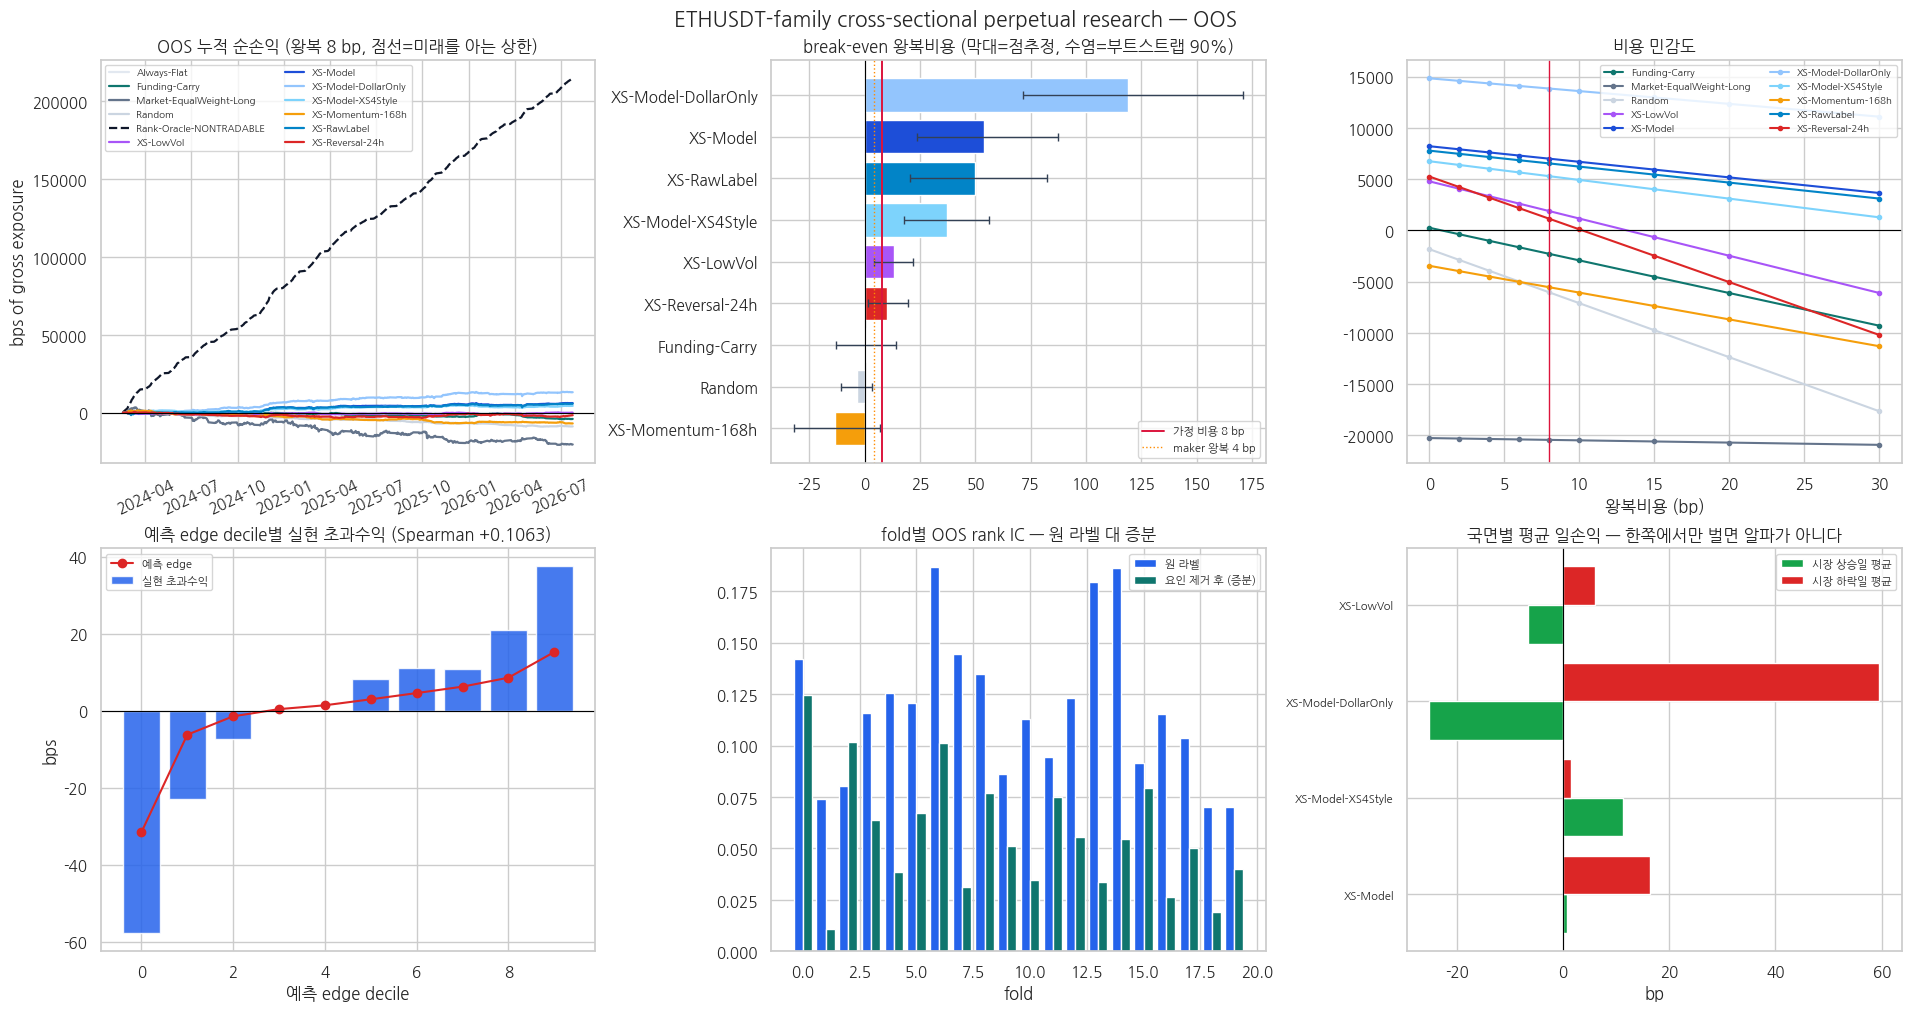


사전 선언 판정 (작업 전에 고정한 기준으로만 평가한다)
------------------------------------------------------------------------------------
J-0  break-even 왕복비용       : +54.0 bp   (> 8.0)        ->  성공   [필요조건]
J-1  최고 베이스라인 대비 초과 : t +1.86 vs XS-LowVol   (> 2.0)  ->  실패   [모델이 필요한가]
J-2  잔차 알파 (시장+베이스라인 통제): t +2.04   (> 2.0)        ->  성공   [알려진 요인 이상인가]
J-3  상승장 하위표본 순손익    : +231 bp (337일)        ->  성공   [국면 하나가 아닌가]
J-4  상위 10일 제외 순손익     : +2,842 bp                    ->  성공   [며칠에 몰린 것 아닌가]
J-5  새 구성층이 XS-4 방식보다  : +1,794 bp (t +0.74)          ->  성공   [평균-분산이 맞았는가]
     통과 5/6
무결성   섞은 라벨 대조군 IC   : +0.0338 (t=+1.82)   (0 근처여야 한다)  ->  정상
------------------------------------------------------------------------------------
XS-Model  break-even +54.03 bp [90% 구간 +23.8 .. +87.5] | net +6,149 bp | Sharpe +1.52 | t +2.11 | 양수 fold 65% | P(순손익>0) 99%
OOS 기간  700일 (700회 리밸런스), 종목 58개 중 매 시점 상위 40개
테스트 rank IC 원라벨 +0.1179 | 요인제거 후 +0.0568  <- 두 번째가 '이미 알려진 요인을 넘어선' 몫이다
실현 북 노출  베타 -0.0381 | 변동성 -0.0697  (목

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
PALETTE = {
    "XS-Model": "#1d4ed8", "Rank-Oracle-NONTRADABLE": "#0f172a",
    "XS-RawLabel": "#0284c7", "XS-Model-DollarOnly": "#93c5fd",
    "XS-Model-XS4Style": "#7dd3fc",
    "XS-Momentum-168h": "#f59e0b", "XS-Reversal-24h": "#dc2626",
    "Funding-Carry": "#0f766e", "XS-LowVol": "#a855f7", "Random": "#cbd5e1",
    "Market-EqualWeight-Long": "#64748b", "Always-Flat": "#e2e8f0",
}
fig, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)

ax = axes[0, 0]
for name, data in POOLED.items():
    order = np.argsort(data["timestamps"])
    style = "--" if name in NON_TRADABLE else "-"
    ax.plot(np.asarray(data["timestamps"])[order], np.cumsum(data["net_bps"][order]),
            style, lw=1.6, label=name, color=PALETTE.get(name))
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"OOS 누적 순손익 (왕복 {CFG.research_round_trip_cost_bps:.0f} bp, 점선=미래를 아는 상한)")
ax.set_ylabel("bps of gross exposure"); ax.legend(fontsize=7, ncol=2); ax.tick_params(axis="x", rotation=25)

ax = axes[0, 1]
# 시장(동일가중 롱)은 사실상 거래를 안 하므로 turnover가 0에 가깝고, break-even이
# 정의상 발산한다.  같은 축에 두면 나머지가 전부 뭉개지므로 여기서는 뺀다
# (J-1 판정에서도 같은 이유로 제외한다).
tradable = STRATEGY_METRICS.loc[~STRATEGY_METRICS.strategy.isin(
    NON_TRADABLE + ["Always-Flat", "Market-EqualWeight-Long"])]
order = tradable.sort_values("break_even_round_trip_bps").strategy.tolist()
_indexed = tradable.set_index("strategy").loc[order]
_centre = _indexed["break_even_round_trip_bps"].to_numpy(dtype="float64")
_errors = np.abs(np.vstack([_centre - _indexed["break_even_p05"].to_numpy(dtype="float64"),
                            _indexed["break_even_p95"].to_numpy(dtype="float64") - _centre]))
ax.barh(order, _centre, xerr=np.nan_to_num(_errors), capsize=3,
        error_kw={"lw": 1.0, "ecolor": "#334155"},
        color=[PALETTE.get(n, "#94a3b8") for n in order])
ax.axvline(CFG.research_round_trip_cost_bps, color="crimson", lw=1.4,
           label=f"가정 비용 {CFG.research_round_trip_cost_bps:.0f} bp")
ax.axvline(4.0, color="darkorange", lw=1.0, ls=":", label="maker 왕복 4 bp")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("break-even 왕복비용 (막대=점추정, 수염=부트스트랩 90%)"); ax.legend(fontsize=8)

ax = axes[0, 2]
for name, group in COST_SENSITIVITY.groupby("strategy", observed=True):
    if name in NON_TRADABLE + ["Always-Flat"]:
        continue
    ax.plot(group.round_trip_cost_bps, group.net_pnl_bps, marker="o", ms=3,
            label=name, color=PALETTE.get(name))
ax.axhline(0, color="black", lw=0.8)
ax.axvline(CFG.research_round_trip_cost_bps, color="crimson", lw=1.0)
ax.set_title("비용 민감도"); ax.set_xlabel("왕복비용 (bp)"); ax.legend(fontsize=7, ncol=2)

ax = axes[1, 0]
ax.bar(EDGE_RELIABILITY.edge_decile, EDGE_RELIABILITY.mean_realized_excess_bps,
       color="#2563eb", alpha=0.85, label="실현 초과수익")
ax.plot(EDGE_RELIABILITY.edge_decile, EDGE_RELIABILITY.mean_predicted_edge_bps,
        "o-", color="#dc2626", label="예측 edge")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"예측 edge decile별 실현 초과수익 (Spearman {edge_spearman:+.4f})")
ax.set_xlabel("예측 edge decile"); ax.set_ylabel("bps"); ax.legend(fontsize=8)

ax = axes[1, 1]
_ic_raw = IC_TABLE.loc[IC_TABLE.split.eq("test") & IC_TABLE.model.eq("raw")]
_ic_inc = IC_TABLE.loc[IC_TABLE.split.eq("test") & IC_TABLE.model.eq("raw_vs_residual")]
_w = 0.4
ax.bar(_ic_raw.fold - _w/2, _ic_raw.rank_ic_mean, _w, color="#2563eb", label="원 라벨")
ax.bar(_ic_inc.fold + _w/2, _ic_inc.rank_ic_mean, _w, color="#0f766e",
       label="요인 제거 후 (증분)")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("fold별 OOS rank IC — 원 라벨 대 증분"); ax.set_xlabel("fold"); ax.legend(fontsize=8)

ax = axes[1, 2]
_bull_bear = REGIME.set_index("strategy").reindex(
    [n for n in ["XS-Model", "XS-Model-XS4Style", "XS-Model-DollarOnly", BEST_BASELINE]
     if n in set(REGIME.strategy)])
_y = np.arange(len(_bull_bear))
ax.barh(_y - 0.2, _bull_bear.bull_mean_bps, 0.4, color="#16a34a", label="시장 상승일 평균")
ax.barh(_y + 0.2, _bull_bear.bear_mean_bps, 0.4, color="#dc2626", label="시장 하락일 평균")
ax.set_yticks(_y); ax.set_yticklabels(_bull_bear.index, fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("국면별 평균 일손익 — 한쪽에서만 벌면 알파가 아니다")
ax.set_xlabel("bp"); ax.legend(fontsize=8)

fig.suptitle("ETHUSDT-family cross-sectional perpetual research — OOS", fontsize=15)
fig.savefig(OUTPUT / "xs_dashboard.png", dpi=160, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------- 저장
STRATEGY_METRICS.to_csv(OUTPUT / "strategy_metrics.csv", index=False)
IC_TABLE.to_csv(OUTPUT / "rank_ic_by_fold.csv", index=False)
IC_SUMMARY.to_csv(OUTPUT / "rank_ic_summary.csv", index=False)
EDGE_RELIABILITY.to_csv(OUTPUT / "edge_reliability.csv", index=False)
SELECTION_GRID.to_csv(OUTPUT / "portfolio_selection_grid.csv", index=False)
COST_SENSITIVITY.to_csv(OUTPUT / "cost_sensitivity.csv", index=False)
BOOTSTRAP.to_csv(OUTPUT / "block_bootstrap.csv", index=False)
LEG_REGIME.to_csv(OUTPUT / "leg_regime_split.csv", index=False)
CONTROL_TABLE.to_csv(OUTPUT / "shuffle_control.csv", index=False)
SCENARIO_SUMMARY.to_csv(OUTPUT / "cost_scenarios.csv", index=False)
LEGS.to_csv(OUTPUT / "leg_paths.csv", index=False)
CONVERSION.to_csv(OUTPUT / "ic_to_pnl_conversion.csv", index=False)
REGIME.to_csv(OUTPUT / "regime_split.csv", index=False)
ATTRIBUTION.to_csv(OUTPUT / "attribution.csv", index=False)
FIT_METADATA.to_csv(OUTPUT / "fit_metadata.csv", index=False)
FOLD_TABLE.to_csv(OUTPUT / "fold_contract.csv", index=False)
SYMBOL_MANIFEST.to_csv(OUTPUT / "symbol_manifest.csv", index=False)
pd.concat([
    pd.DataFrame({"strategy": name, "timestamp": data["timestamps"],
                  "net_bps": data["net_bps"], "gross_bps": data["gross_bps"],
                  "funding_bps": data["funding_bps"], "turnover": data["turnover"]})
    for name, data in POOLED.items()
], ignore_index=True).to_parquet(OUTPUT / "oos_strategy_paths.parquet", index=False)

# ---------------------------------------------------------------- 사전 선언 판정
model = STRATEGY_METRICS.set_index("strategy").loc[PRIMARY]
tradable_only = STRATEGY_METRICS.loc[
    ~STRATEGY_METRICS.strategy.isin(NON_TRADABLE + ["Always-Flat", "Market-EqualWeight-Long"])]
best_row = tradable_only.loc[tradable_only.break_even_round_trip_bps.idxmax()]
oracle = STRATEGY_METRICS.set_index("strategy").loc["Rank-Oracle-NONTRADABLE"]
_test_ic = IC_TABLE.loc[IC_TABLE.split.eq("test")]
test_ic_mean = float(_test_ic.loc[_test_ic.model.eq("raw"), "rank_ic_mean"].mean())
test_ic_t = float(_test_ic.loc[_test_ic.model.eq("raw"), "rank_ic_tstat"].mean())
_incremental_ic = float(_test_ic.loc[_test_ic.model.eq("raw_vs_residual"), "rank_ic_mean"].mean())

# ---- J-0 break-even (필요조건) ----
verdict_0 = float(model.break_even_round_trip_bps) > CFG.judgment_break_even_bps

# ---- J-1 최고 베이스라인 대비 우월성.  XS-1은 이걸 안 봐서, 모델이 베이스라인의
#      1.21배 복제품인데도 통과했다.  일별 차이의 t값으로 본다 (짝지어진 비교).
_difference = (PANEL_DAILY[PRIMARY] - PANEL_DAILY[BEST_BASELINE]).to_numpy()
EXCESS_TSTAT = float(_difference.mean() / (_difference.std(ddof=1) / np.sqrt(len(_difference)))) \
    if len(_difference) > 2 and _difference.std(ddof=1) > 0 else np.nan
verdict_1 = bool(np.isfinite(EXCESS_TSTAT) and EXCESS_TSTAT > CFG.judgment_excess_tstat)

# ---- J-2 시장·베이스라인 통제 후 잔차 알파 ----
verdict_2 = bool(np.isfinite(RESIDUAL_ALPHA_TSTAT)
                 and RESIDUAL_ALPHA_TSTAT > CFG.judgment_residual_alpha_tstat)

# ---- J-3 상승장 하위표본.  표본이 너무 적으면 '실패'가 아니라 '판정 불가'다 --
#      둘을 섞으면 데이터가 없다는 사실이 나쁜 성과처럼 보인다.
BULL_NET = float(PANEL_DAILY[PRIMARY].to_numpy()[BULL].sum())
BULL_ENOUGH = bool(BULL.sum() >= 20)
verdict_3 = bool(BULL_ENOUGH and BULL_NET > 0)

# ---- J-4 상위 N일 제외 ----
TOP_EXCLUDED_NET = float(CONCENTRATION.loc[
    CONCENTRATION.excluded_top_days.eq(CFG.judgment_top_days_excluded), "net_bps"].iloc[0])
verdict_4 = bool(TOP_EXCLUDED_NET > 0)

# ---- J-5 혼합이 모델 단독보다 나은가.  XS-3에서 corr(모델, LowVol)=0.166이라
#      '이기는' 게 아니라 '합치는' 게 답일 수 있다는 힌트가 나왔다.  그 가설의 검정이다.
_blend_gain = (PANEL_DAILY[PRIMARY] - PANEL_DAILY["XS-Model-XS4Style"]).to_numpy()
BLEND_GAIN_TSTAT = float(_blend_gain.mean() / (_blend_gain.std(ddof=1) / np.sqrt(len(_blend_gain)))) \
    if len(_blend_gain) > 2 and _blend_gain.std(ddof=1) > 1e-12 else 0.0
BLEND_GAIN_BPS = float(_blend_gain.sum())
verdict_5 = bool(BLEND_GAIN_TSTAT > CFG.judgment_blend_gain_tstat)

summary = {
    "created_utc": str(pd.Timestamp.now(tz="UTC")),
    "design": "cross-sectional dollar-neutral long/short on Binance USD-M perpetuals",
    "label": f"cross-sectionally demeaned forward {CFG.label_horizon_hours}h log return (bps)",
    "rebalance_hours": CFG.rebalance_hours,
    "oos_rebalances": int(len(POOLED["XS-Model"]["net_bps"])),
    "oos_days": float(len(POOLED["XS-Model"]["net_bps"]) * CFG.rebalance_hours / 24),
    "symbols_downloaded": int(len(SYMBOL_LIST)),
    "tradable_universe_cap": CFG.tradable_universe,
    "assumed_round_trip_cost_bps": CFG.research_round_trip_cost_bps,
    "model_break_even_round_trip_bps": float(model.break_even_round_trip_bps),
    "model_break_even_p05_bps": float(MODEL_BOOTSTRAP.break_even_p05),
    "model_break_even_p95_bps": float(MODEL_BOOTSTRAP.break_even_p95),
    "model_prob_net_positive": float(MODEL_BOOTSTRAP.prob_net_positive),
    "model_net_pnl_bps": float(model.net_pnl_bps),
    "model_annualized_sharpe": float(model.annualized_sharpe),
    "model_tstat": float(model.tstat),
    "model_positive_fold_share": float(model.positive_fold_share),
    "best_tradable_strategy": str(best_row.strategy),
    "best_tradable_break_even_bps": float(best_row.break_even_round_trip_bps),
    "oracle_break_even_bps": float(oracle.break_even_round_trip_bps),
    "test_rank_ic_mean": test_ic_mean, "test_rank_ic_tstat": test_ic_t,
    "edge_spearman": edge_spearman,
    "shuffled_label_control_ic": CONTROL_IC["rank_ic_mean"],
    "shuffled_label_control_tstat": CONTROL_IC["rank_ic_tstat"],
    "shuffled_label_control_clean": CONTROL_CLEAN,
    "best_baseline": BEST_BASELINE,
    "excess_over_baseline_tstat": EXCESS_TSTAT,
    "residual_alpha_tstat": RESIDUAL_ALPHA_TSTAT,
    "bull_subsample_net_bps": BULL_NET, "bull_days": int(BULL.sum()),
    "net_excluding_top_days_bps": TOP_EXCLUDED_NET,
    "model_mean_beta_exposure": float(model.get("mean_beta_exposure", np.nan)),
    "model_mean_vol_exposure": float(model.get("mean_vol_exposure", np.nan)),
    "ic_to_pnl_corr": IC_TO_PNL, "ic_to_pnl_corr_xs4_style": IC_TO_PNL_EQUAL,
    "cost_scenario": CFG.cost_scenario,
    "net_by_cost_scenario_bps": {r.scenario: float(r.net_bps)
                                 for r in SCENARIO_SUMMARY.itertuples()},
    "new_layer_gain_total_bps": float(CONVERSION.new_layer_gain_bps.sum()),
    "judgment_0_break_even": bool(verdict_0), "judgment_1_beats_baseline": bool(verdict_1),
    "judgment_2_residual_alpha": bool(verdict_2), "judgment_3_bull_regime": bool(verdict_3),
    "judgment_4_top_days_excluded": bool(verdict_4),
    "judgment_5_blend_helps": bool(verdict_5),
    "new_layer_gain_bps": BLEND_GAIN_BPS, "new_layer_gain_tstat": BLEND_GAIN_TSTAT,
    "selected_schemes": SELECTED.scheme.value_counts().to_dict(),
    "selected_shrinks": {f"{k:g}": int(v) for k, v in SELECTED.shrink.value_counts().items()},
    "primary_strategy": PRIMARY,
    "effective_round_trip_bps": float(model.get("effective_round_trip_bps", np.nan)),
    "judgments_passed": int(verdict_0) + int(verdict_1) + int(verdict_2) + int(verdict_3)
                        + int(verdict_4) + int(verdict_5),
    "interpretation": "research P&L with a linear cost model and funding; no order book, "
                      "no partial fills, no borrow constraint on the short leg",
}
with open(OUTPUT / "result_summary.json", "w", encoding="utf-8") as handle:
    json.dump(summary, handle, ensure_ascii=False, indent=2, default=float)
archive = shutil.make_archive("/content/xs_perp_outputs", "zip", OUTPUT)

print("\n" + "=" * 84)
print("사전 선언 판정 (작업 전에 고정한 기준으로만 평가한다)")
print("-" * 84)
print(f"J-0  break-even 왕복비용       : {float(model.break_even_round_trip_bps):+.1f} bp"
      f"   (> {CFG.judgment_break_even_bps:.1f})        ->  {'성공' if verdict_0 else '실패'}   [필요조건]")
print(f"J-1  최고 베이스라인 대비 초과 : t {EXCESS_TSTAT:+.2f} vs {BEST_BASELINE}"
      f"   (> {CFG.judgment_excess_tstat:.1f})  ->  {'성공' if verdict_1 else '실패'}   [모델이 필요한가]")
print(f"J-2  잔차 알파 (시장+베이스라인 통제): t {RESIDUAL_ALPHA_TSTAT:+.2f}"
      f"   (> {CFG.judgment_residual_alpha_tstat:.1f})        ->  {'성공' if verdict_2 else '실패'}   [알려진 요인 이상인가]")
print(f"J-3  상승장 하위표본 순손익    : {BULL_NET:+,.0f} bp ({int(BULL.sum())}일)"
      f"        ->  {'성공' if verdict_3 else ('실패' if BULL_ENOUGH else '판정불가(표본부족)')}"
      f"   [국면 하나가 아닌가]")
print(f"J-4  상위 {CFG.judgment_top_days_excluded}일 제외 순손익     : {TOP_EXCLUDED_NET:+,.0f} bp"
      f"                    ->  {'성공' if verdict_4 else '실패'}   [며칠에 몰린 것 아닌가]")
print(f"J-5  새 구성층이 XS-4 방식보다  : {BLEND_GAIN_BPS:+,.0f} bp (t {BLEND_GAIN_TSTAT:+.2f})"
      f"          ->  {'성공' if verdict_5 else '실패'}   [평균-분산이 맞았는가]")
print(f"     통과 {int(verdict_0)+int(verdict_1)+int(verdict_2)+int(verdict_3)+int(verdict_4)+int(verdict_5)}/6")
print(f"무결성   섞은 라벨 대조군 IC   : {CONTROL_IC['rank_ic_mean']:+.4f} "
      f"(t={CONTROL_IC['rank_ic_tstat']:+.2f})   (0 근처여야 한다)  ->  "
      f"{'정상' if CONTROL_CLEAN else '누수 의심'}")
print("-" * 84)
print(f"{PRIMARY}  break-even {float(model.break_even_round_trip_bps):+.2f} bp "
      f"[90% 구간 {float(MODEL_BOOTSTRAP.break_even_p05):+.1f} .. {float(MODEL_BOOTSTRAP.break_even_p95):+.1f}] | "
      f"net {float(model.net_pnl_bps):+,.0f} bp | Sharpe {float(model.annualized_sharpe):+.2f} | "
      f"t {float(model.tstat):+.2f} | 양수 fold {float(model.positive_fold_share):.0%} | "
      f"P(순손익>0) {float(MODEL_BOOTSTRAP.prob_net_positive):.0%}")
print(f"OOS 기간  {summary['oos_days']:.0f}일 ({summary['oos_rebalances']}회 리밸런스), "
      f"종목 {summary['symbols_downloaded']}개 중 매 시점 상위 {CFG.tradable_universe}개")
print(f"테스트 rank IC 원라벨 {test_ic_mean:+.4f} | 요인제거 후 {_incremental_ic:+.4f}  "
      f"<- 두 번째가 '이미 알려진 요인을 넘어선' 몫이다")
print(f"실현 북 노출  베타 {float(model.get('mean_beta_exposure', np.nan)):+.4f} | "
      f"변동성 {float(model.get('mean_vol_exposure', np.nan)):+.4f}  (목표가 아니라 실제 거래된 북이다)")
print(f"예측->손익 전환 corr(fold IC, fold 손익) {IC_TO_PNL:+.3f}  "
      f"(XS-2에서 +0.04였고 그게 병목이었다) | 상한 break-even "
      f"{float(oracle.break_even_round_trip_bps):+.1f} bp")
print("=" * 84)
print("해석: 선형 비용 + 펀딩까지 반영한 research P&L이다. 호가창·부분체결·숏 차입제약은 없다.")
print("Output archive:", archive)
try:
    from google.colab import files
    files.download(archive)
except Exception:
    print("Colab 밖: 위 경로를 쓰세요.")

## 해석 체크리스트

- **먼저 무결성 줄을 봐라.** 섞은 라벨 대조군 IC가 0 근처가 아니면 나머지 숫자는
  전부 무의미하다. 여기서 실패하면 성과가 아무리 좋아도 버그를 찾아야 한다.
- **그 다음 J-1을 봐라 — 이게 XS-2에서 가장 중요한 줄이다.** 모델이 최고 베이스라인을
  통계적으로 못 이기면, 아무리 수익이 커도 **그 베이스라인을 쓰는 게 맞다.** XS-1이
  통과했다가 사후 분석에서 무너진 지점이 정확히 여기다.
- **J-2와 J-3을 함께 봐라.** J-2가 실패하면 번 것이 이미 알려진 위험요인이고,
  J-3이 실패하면 국면 하나에 기댄 것이다. 둘 다 "수익은 났는데 반복되지 않는다"의 형태다.
- **주 지표는 `break_even_round_trip_bps`다.** 순손익이 0이 되는 왕복비용이고,
  가정 비용(8bp)이나 maker 왕복(4bp)을 넘는지가 전부다.
- **점추정이 아니라 부트스트랩 90% 구간의 아래끝을 봐라.** 아래끝이 비용선 위에
  있어야 "비용을 넘는다"고 말할 수 있다. 가운데만 넘는 건 우연과 구분되지 않는다.
- **rank IC가 양수여도 break-even이 비용 아래면 거래하면 안 된다.** V1~V3의 교훈이다 —
  맞히는 것과 버는 것은 다른 문제다.
- **fold별 부호를 봐라.** `positive_fold_share`가 50% 근처면 전체 순손익이 양수여도
  한두 fold가 끌고 간 것이다.
- **`Rank-Oracle` 대비 격차**가 이 구조에서 남은 여지다. 모델이 상한의 몇 %인가.
- **베이스라인을 못 이기면 모델은 필요 없다.** 펀딩 캐리나 24시간 반전이 더 나으면
  그 단순한 규칙을 쓰는 게 맞다.
- **숏 다리의 현실성**: 무기한선물이라 차입은 필요 없지만, 유동성이 얇은 종목의 숏은
  실제로는 슬리피지가 크다. 지금 비용 모델은 종목 무관 선형이다.
- **아직 없는 것**: 호가창, 부분체결, 시장충격, 거래소 리스크, 자금조달 한도.
  다음 단계는 상위 유동성 종목만 남기고 실제 스프레드를 붙이는 것이다.

### 결과가 안 좋게 나왔을 때 — 그것도 결과다

이 노트북은 "잘 나오면 성공"이 아니라 **어느 쪽이든 답이 나오도록** 설계했다.
J-1이 실패하면 그건 '이 설정에서 24시간 횡단면 알파는 8bp 비용을 못 넘는다'는
구체적 사실이고, V1~V3에서 5초 설정을 하나씩 지워온 것과 같은 방식으로 다음 후보를
지운 것이다. 그때 볼 순서는 이렇다.

1. **rank IC는 양수인데 break-even이 낮은가** → 예측은 되는데 turnover가 먹는 것이다.
   `rebalance_fraction`을 더 낮추고, 보유기간(`label_horizon_hours`/`rebalance_hours`)을
   72h·168h로 늘려봐라. 신호가 느릴수록 비용이 얇아진다.
2. **rank IC 자체가 0 근처인가** → 24시간 지평에 횡단면 신호가 없다는 뜻이다.
   `label_horizon_grid`의 다른 지평(4h, 72h)으로 바꿔 같은 배관을 다시 돌려라.
3. **베이스라인 중 하나가 모델을 이기는가** → 그 규칙을 쓰면 된다. 펀딩 캐리나
   24시간 반전이 이기는 건 흔한 일이고, 단순한 게 이기는 것도 결과다.
4. **oracle 대비 격차가 큰가** → 구조에는 여지가 있는데 모델이 못 뽑아내는 것이다.
   피처(자금흐름·베이시스·미결제약정)를 늘리는 게 다음 수순이다.